In [136]:
from collections import defaultdict
import copy
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.dagcircuit import DAGCircuit, DAGOpNode, DAGInNode, DAGOutNode
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.transpiler.layout import Layout
from qiskit.circuit.quantumregister import Qubit
from qiskit.visualization import dag_drawer, circuit_drawer
from qiskit.qasm import Qasm

import matplotlib.pyplot as plt
import networkx as nx
import rustworkx as rx

from vfsexp import Vf

In [138]:
def architecturesquare(AG: nx.Graph):
    g = nx.Graph()
    g.add_nodes_from(AG.nodes())

    # Iterate over all pairs of nodes in the original graph
    for node1 in AG.nodes():
        for node2 in AG.nodes():
            # Calculate the shortest path distance between node1 and node2
            distance = nx.shortest_path_length(AG, source=node1, target=node2)

            # Add an edge if the distance is less than or equal to 2 and the nodes are not the same
            if distance <= 2 and node1 != node2:
                g.add_edge(node1, node2)
    return g

In [139]:
""" From a QuantumCircuit, remove all 1qb gates and any 2qb gate [p,q] that has a parent [p,q] or [q,p]"""
def remove_1q_and_consecutive_2q_gates_in_circuit(circuit):
    if not isinstance(circuit, QuantumCircuit):
        raise TypeError("circuit is not a QuantumCircuit")
    newcirc = QuantumCircuit(circuit.num_qubits)
    record = [] #the current end layer of the reduced circuit
    for instruction in circuit:
        if len(instruction.qubits) != 2: continue
        if instruction.operation.name == 'cx': # only consider cx gates
            p, q = instruction.qubits[0]._index, instruction.qubits[1]._index
            if [p,q] in record or [q,p] in record:
                continue
            for x in record:
                if p in x or q in x:
                    record.remove(x)
            record.append([p,q])            
            newcirc.cx(p,q)
    return newcirc

def _successors(node, dag):
    for _, successor, edge_data in dag.edges(node):
        if not isinstance(successor, DAGOpNode):
            continue
        if isinstance(edge_data, Qubit):
            yield successor

def get_interaction_graph(dag: DAGCircuit):
    g = nx.Graph()
    qubit_layers = defaultdict(list)
    edge_layers = defaultdict(list)

    for layer_no, layer in enumerate(dag.layers()):
        #print(f"layer number{layer_no} {layer['partition']}")
        #if layer_no == 0: continue
        for qubit_pair in layer['partition']:
            p, q = qubit_pair[0]._index, qubit_pair[1]._index
            g.add_edge(p,q)
            qubit_layers[p].append(layer_no)
            qubit_layers[q].append(layer_no)
            edge_layers[(p,q)].append(layer_no)
            edge_layers[(q,p)].append(layer_no)

    for node, layers in qubit_layers.items():
        g.nodes[node]['layer_distribution'] = layers

    for edge, layers in edge_layers.items():
        g.edges[edge]['layer_distribution'] = layers
    return g

def graph_of_circuit(circuit):
    ''' Return the interaction graph of the reduced QuantumCircuit C
            - node set: indices of qubits in C
            - edge set: all pair (p,q) if CNOT [p,q] or CNOT[q,p] in C
        Args:
            C (list): the input reduced circuit
        Returns:
            g (Graph)
    '''   
    g = nx.Graph()
    for gate in circuit:
        if gate.operation.name != 'cx': continue
        p, q = gate.qubits[0]._index, gate.qubits[1]._index
        g.add_edge(p,q)
    return g  

def has_cycle_3(graph: nx.Graph): 
    for u in graph.nodes():
        for v in graph.neighbors(u):
            for w in graph.neighbors(v):
                if u != w and graph.has_edge(u, w):
                    return True
    return False

def fast_no_embedding(subgraph: nx.Graph, graph: nx.Graph):
    # for AG with no 3-cycle
    if has_cycle_3(subgraph) and not has_cycle_3(graph): 
        return True
    
    subgraph_deg = list(nx.degree(subgraph, v) for v in subgraph.nodes())
    subgraph_deg.sort(reverse=True)
    
    graph_deg = list(nx.degree(subgraph, v) for v in subgraph.nodes())
    graph_deg.sort(reverse=True)
    
    l = len(subgraph_deg)
    for idx in range(l):
        if subgraph_deg[idx] > graph_deg[idx]:
            return True
        
    return False

def is_rx_embeddable(circuit, AG: nx.Graph):
    """circuit is a DAGCircuit or a QuantumCircuit """
    if isinstance(circuit, DAGCircuit):
        qc = dag_to_circuit(circuit)
        g = graph_of_circuit(qc)

    if isinstance(circuit, QuantumCircuit):
        qc = remove_1q_and_consecutive_2q_gates_in_circuit(circuit)
        g = graph_of_circuit(qc)
        
    if isinstance(circuit, nx.Graph):
        g = copy.deepcopy(circuit)
    
    if fast_no_embedding(g, AG):
        return False, None
    
    """Call rustworkx subgraph isomorphic method"""
    rxAG = rx.networkx_converter(AG)
    rxg = rx.networkx_converter(g)

    is_embeddable = rx.is_subgraph_isomorphic(rxAG, rxg, induced=False)
    if is_embeddable:
        vf2_map = rx.vf2_mapping(rxAG, rxg, subgraph=True, induced=False)
        #print(f"rx-vf2_mapping: {next(vf2_map)}")
        return is_embeddable, vf2_map
    return is_embeddable, None

def draw_nx_graph(g):
    if isinstance(g, DAGCircuit): 
        qc = dag_to_circuit(g)
        g = graph_of_circuit(qc)
    
    if not isinstance(g, nx.Graph):
        raise Exception('g should be a nx.Graph')
        
    # Create a layout for the nodes
    pos = nx.spring_layout(g) #sl !!not sure if this is the correct layout for us!!

    # Draw the nodes and edges
    nx.draw(g, pos, with_labels=True, node_color='skyblue', node_size=500, font_size=12, font_color='black')

    # Display the graph
    plt.show()

In [140]:
"""Partition a dagCircuit into sections s.t. each section is embeddable into a given architecture""" 
def partition(dag: DAGCircuit, architecture: nx.Graph, method='greedy'):
    """dag:DAGCircuit satisfies
         (i) it contains no single-qubit gates; and 
        (ii) any two consecutive cx gates should have act on disjoint or partially overlapping qubits
    """

    print(f'The dagCircuit has {dag.count_ops()} cx gates')
    for node in dag.nodes():
        if not isinstance(node, DAGOpNode): continue
        if len(node.qargs) != 2 or node.op.name != 'cx': 
            raise Exception(f'check why dag still has single-qubit gates {type(node), node.op.name}')
    
    """Use applied_predecessors to track gates which are ready to process, i.e., can be put in front layer"""
    # Create a defaultdict with a default value of 0
    applied_predecessors = defaultdict(int)
    for _, input_node in dag.input_map.items(): 
        for successor in _successors(input_node, dag):
            applied_predecessors[successor] += 1
    
    step = 0
    processed_node = []
    num_part = 0
    part_list = []
    current_part_dag = dag.copy_empty_like()
    part_graph = nx.Graph()

    # generate the current layer and examine for each node of the current layer
    front_layer = dag.front_layer()
    while front_layer:
        step += 1
        
        """Put cx gate in front_layer to the current section whenever possible"""
        execute_gate_list = []        
        for node in front_layer:            
            v0, v1 = node.qargs
            
            EMBEDDABLE = True
            if (v0._index,v1._index) not in part_graph.edges():
                temp_graph = copy.deepcopy(part_graph)
                temp_graph.add_edge(v0._index,v1._index)      
                EMBEDDABLE, _ = is_rx_embeddable(temp_graph, architecture)
                
            if EMBEDDABLE:
                execute_gate_list.append(node)
                processed_node.append(node)
                current_part_dag.apply_operation_back(node.op, node.qargs, node.cargs)
                part_graph.add_edge(v0._index,v1._index)      

        """The whole layer has been examined!"""
        if execute_gate_list: 
            """Update the front layer!"""
            for node in execute_gate_list:
                front_layer.remove(node)
                for successor in _successors(node, dag):
                    applied_predecessors[successor] += 1
                    if applied_predecessors[successor] == len(node.qargs):
                        front_layer.append(successor)
            
        else: 
            """No gate in front_layer can be added. A new section should start!"""
            part_list.append(current_part_dag)
            num_part += 1

            print(f'step {step}: Section {num_part} constructed!')
            print([(node.qargs[0]._index, node.qargs[1]._index) for node\
                   in current_part_dag.topological_op_nodes() if isinstance(node, DAGOpNode)])
            
            draw_nx_graph(part_graph)

            """Start a new part dag!"""
            current_part_dag = dag.copy_empty_like()
            part_graph = nx.Graph()
            print(f'step {step}: start a new part dag {current_part_dag.count_ops()}')
    
    """The final part dag"""
    part_list.append(current_part_dag)
    num_part += 1

    print(f'step {step}: Section {num_part} constructed!')
    print([(node.qargs[0]._index, node.qargs[1]._index) for node\
           in current_part_dag.topological_op_nodes() if isinstance(node, DAGOpNode)])

    draw_nx_graph(part_graph)

    if len(processed_node) < dag.count_ops()['cx']:
        raise Exception (f'The partition is incomplete! {len(processed_node), dag.count_ops()}')
        
    print(f'{len(processed_node)} cx gates have been processed.')

    print(f'The partition is complete and we have {num_part} sections!')
    return part_list

OrderedDict([('u1', 1533), ('cx', 1532), ('u', 19), ('u3', 2)])
or_10.qasm {'cx': 1021}
The interaction graph is embeddable in AG? False
The dagCircuit has {'cx': 1021} cx gates
step 3: Section 1 constructed!
[(8, 9), (8, 7)]


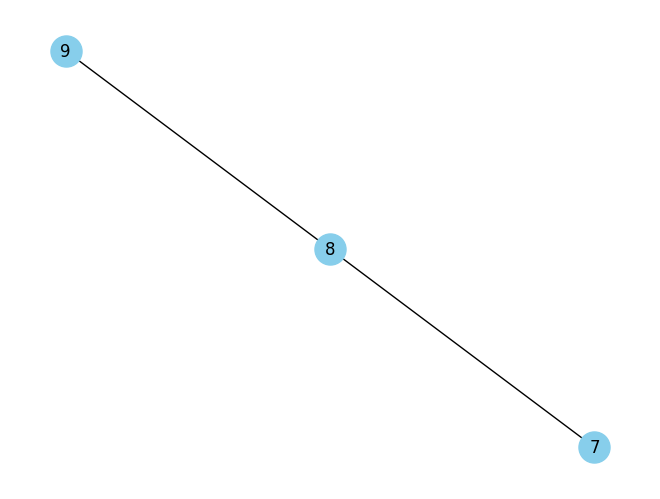

step 3: start a new part dag {}
step 8: Section 2 constructed!
[(7, 9), (8, 7), (7, 9), (7, 6)]


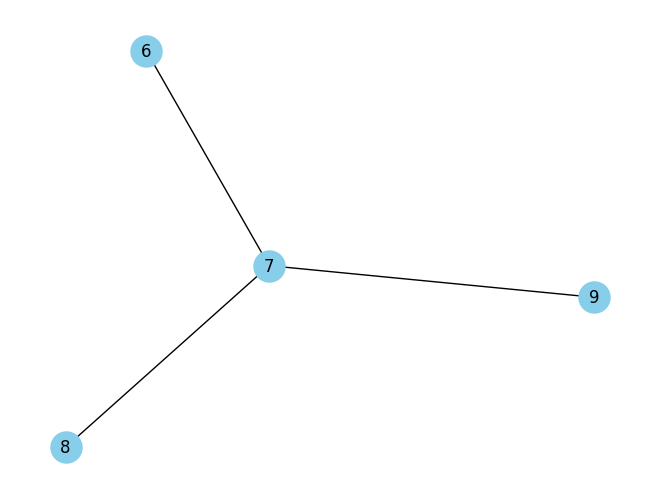

step 8: start a new part dag {}
step 16: Section 3 constructed!
[(6, 9), (8, 6), (6, 9), (7, 6), (6, 9), (8, 6), (6, 9)]


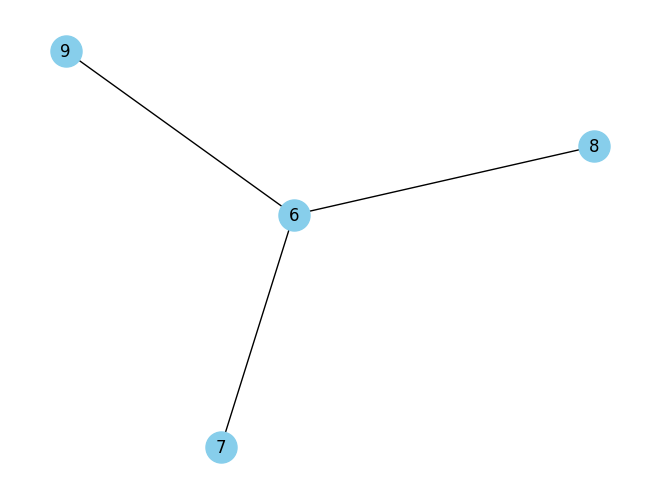

step 16: start a new part dag {}
step 21: Section 4 constructed!
[(6, 5), (5, 9), (8, 5), (5, 9)]


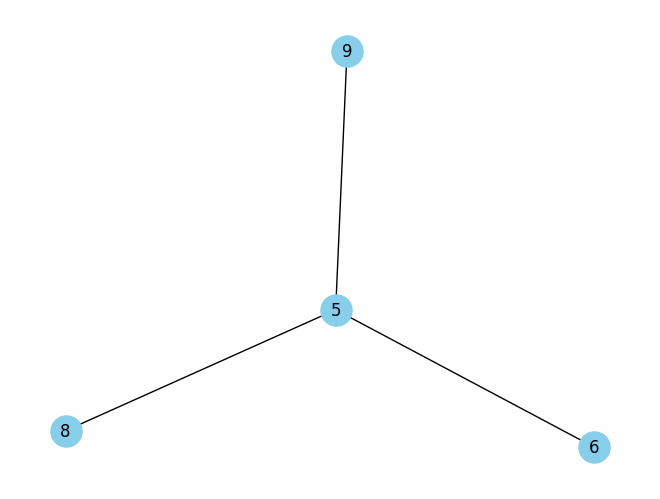

step 21: start a new part dag {}
step 26: Section 5 constructed!
[(7, 5), (5, 9), (8, 5), (5, 9)]


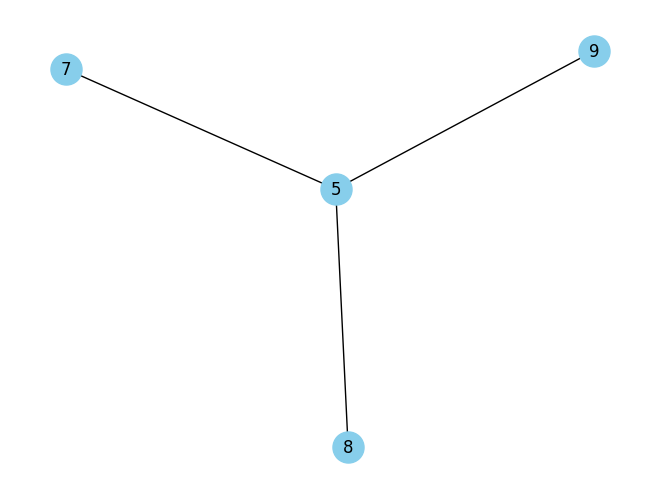

step 26: start a new part dag {}
step 31: Section 6 constructed!
[(6, 5), (5, 9), (8, 5), (5, 9)]


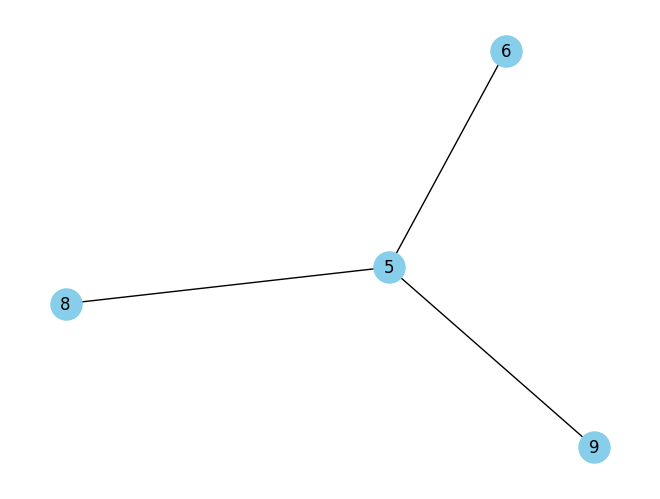

step 31: start a new part dag {}
step 36: Section 7 constructed!
[(7, 5), (5, 9), (8, 5), (5, 9)]


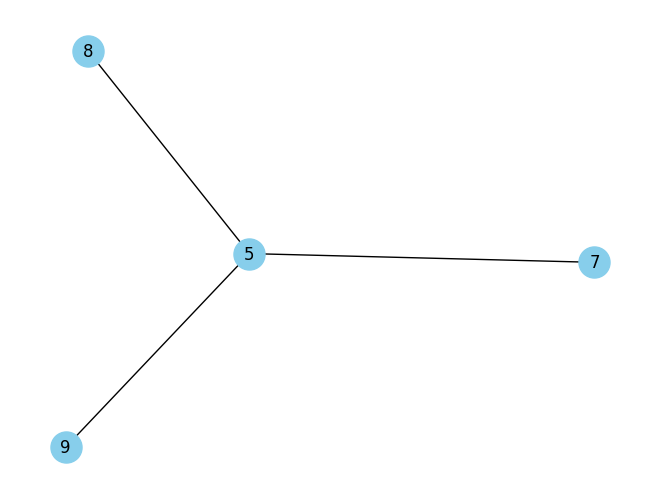

step 36: start a new part dag {}
step 41: Section 8 constructed!
[(5, 4), (4, 9), (8, 4), (4, 9)]


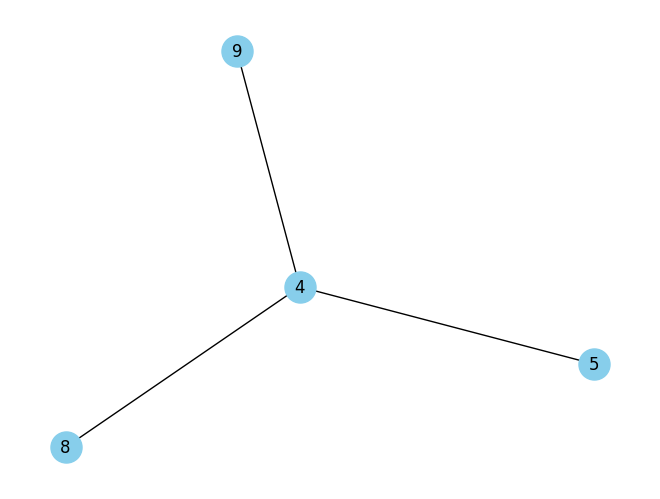

step 41: start a new part dag {}
step 46: Section 9 constructed!
[(7, 4), (4, 9), (8, 4), (4, 9)]


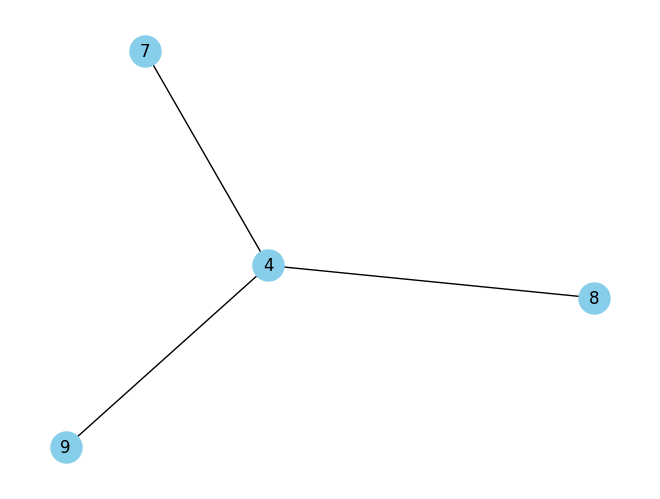

step 46: start a new part dag {}
step 51: Section 10 constructed!
[(6, 4), (4, 9), (8, 4), (4, 9)]


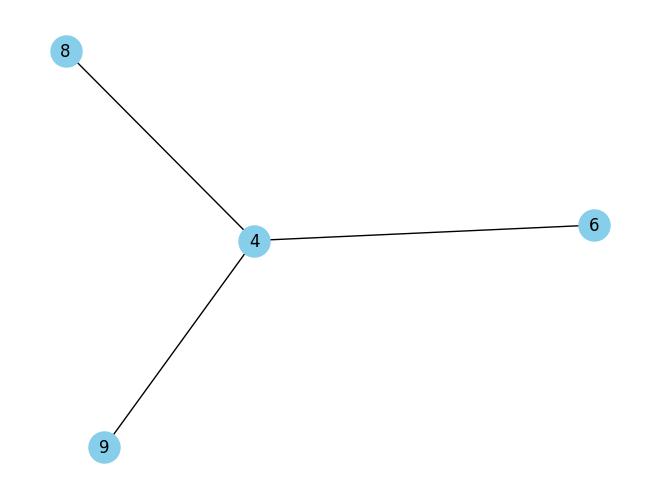

step 51: start a new part dag {}
step 56: Section 11 constructed!
[(7, 4), (4, 9), (8, 4), (4, 9)]


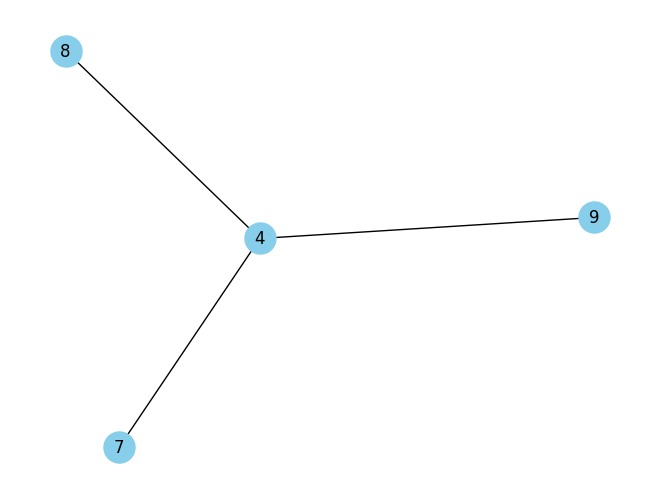

step 56: start a new part dag {}
step 61: Section 12 constructed!
[(5, 4), (4, 9), (8, 4), (4, 9)]


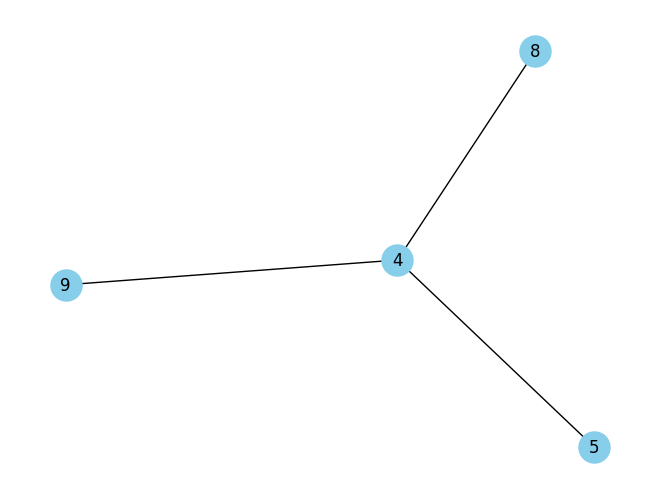

step 61: start a new part dag {}
step 66: Section 13 constructed!
[(7, 4), (4, 9), (8, 4), (4, 9)]


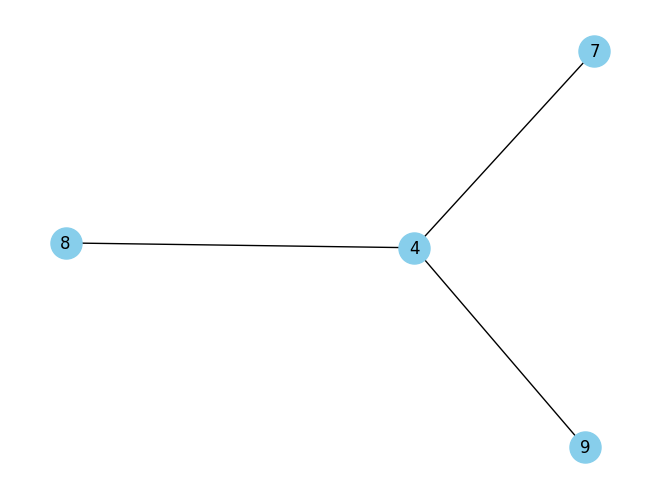

step 66: start a new part dag {}
step 71: Section 14 constructed!
[(6, 4), (4, 9), (8, 4), (4, 9)]


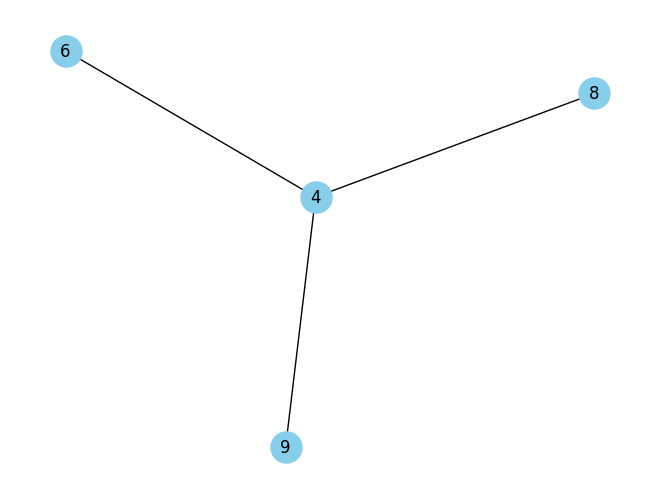

step 71: start a new part dag {}
step 76: Section 15 constructed!
[(7, 4), (4, 9), (8, 4), (4, 9)]


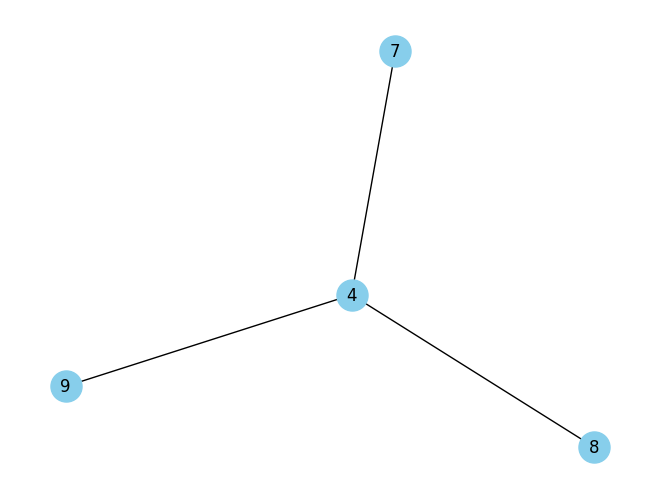

step 76: start a new part dag {}
step 81: Section 16 constructed!
[(4, 3), (3, 9), (8, 3), (3, 9)]


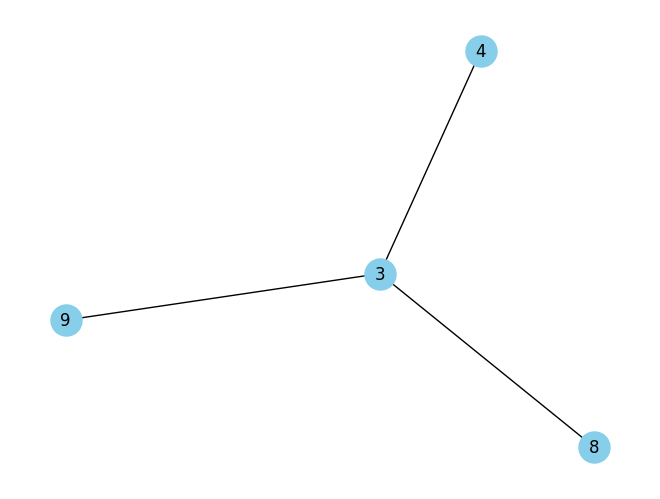

step 81: start a new part dag {}
step 86: Section 17 constructed!
[(7, 3), (3, 9), (8, 3), (3, 9)]


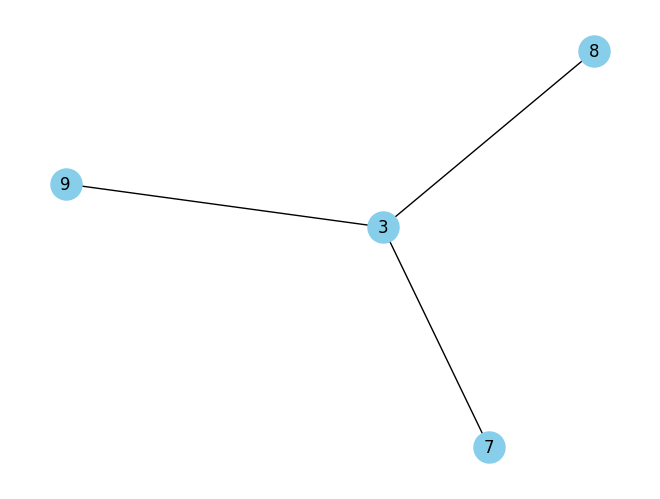

step 86: start a new part dag {}
step 91: Section 18 constructed!
[(6, 3), (3, 9), (8, 3), (3, 9)]


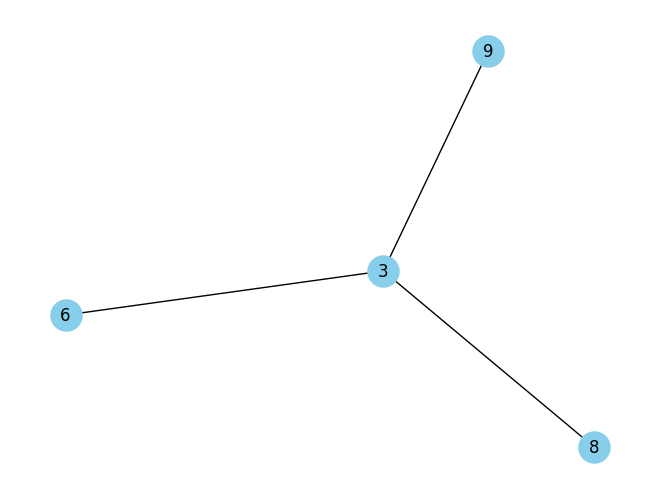

step 91: start a new part dag {}
step 96: Section 19 constructed!
[(7, 3), (3, 9), (8, 3), (3, 9)]


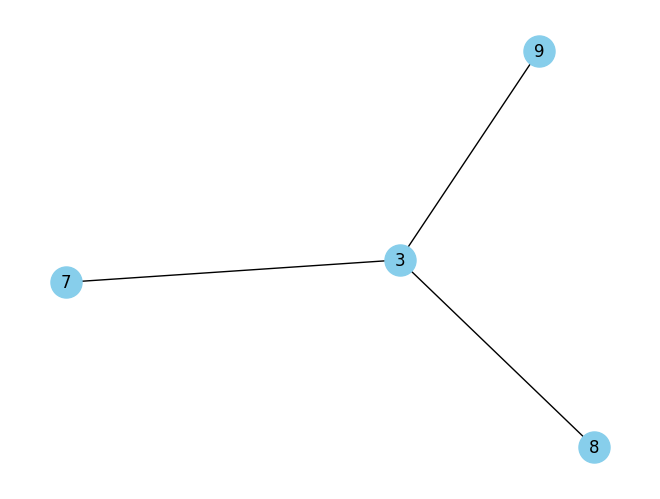

step 96: start a new part dag {}
step 101: Section 20 constructed!
[(5, 3), (3, 9), (8, 3), (3, 9)]


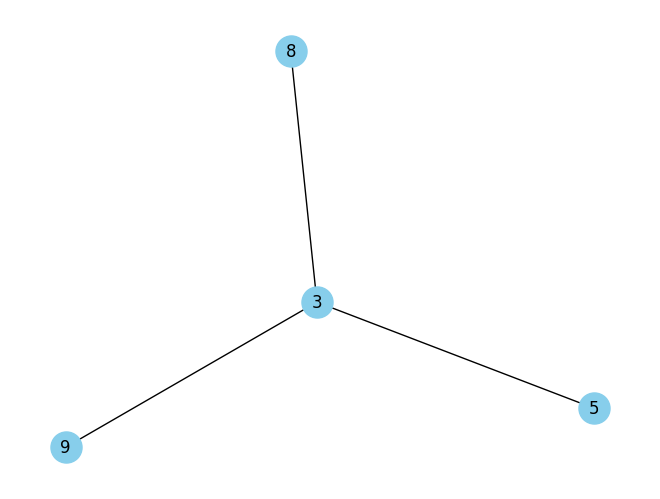

step 101: start a new part dag {}
step 106: Section 21 constructed!
[(7, 3), (3, 9), (8, 3), (3, 9)]


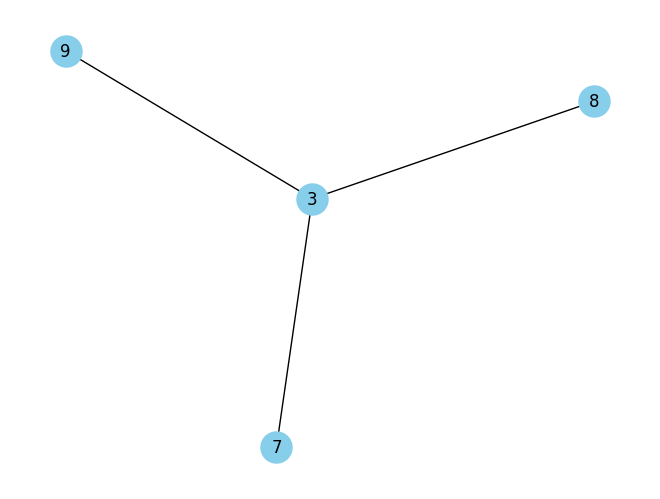

step 106: start a new part dag {}
step 111: Section 22 constructed!
[(6, 3), (3, 9), (8, 3), (3, 9)]


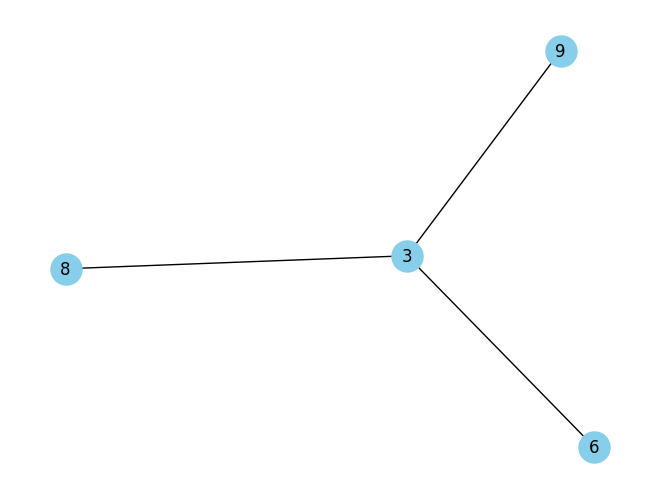

step 111: start a new part dag {}
step 116: Section 23 constructed!
[(7, 3), (3, 9), (8, 3), (3, 9)]


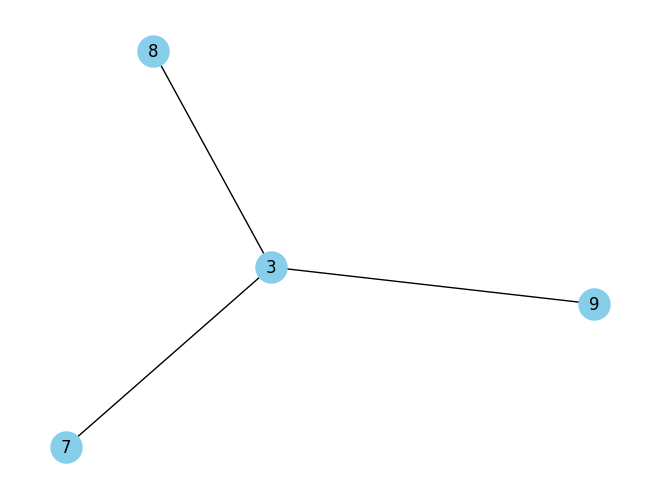

step 116: start a new part dag {}
step 121: Section 24 constructed!
[(4, 3), (3, 9), (8, 3), (3, 9)]


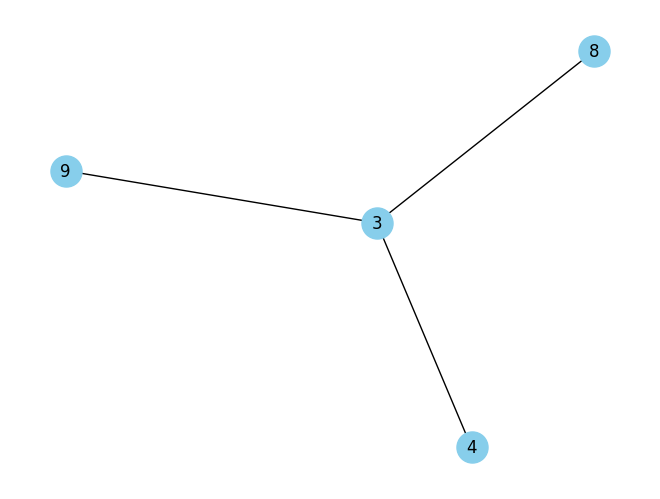

step 121: start a new part dag {}
step 126: Section 25 constructed!
[(7, 3), (3, 9), (8, 3), (3, 9)]


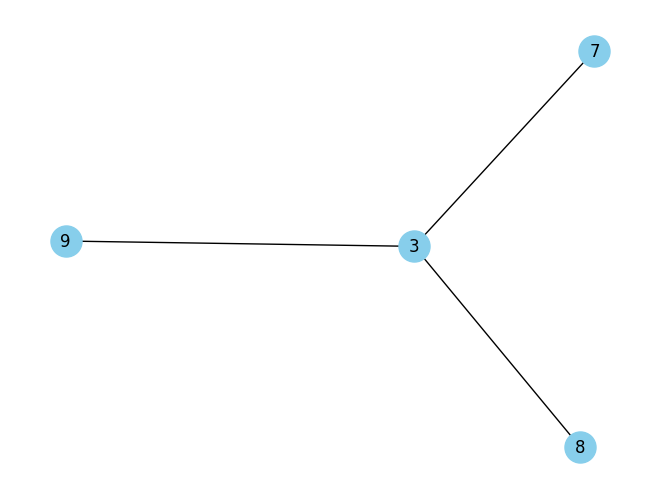

step 126: start a new part dag {}
step 131: Section 26 constructed!
[(6, 3), (3, 9), (8, 3), (3, 9)]


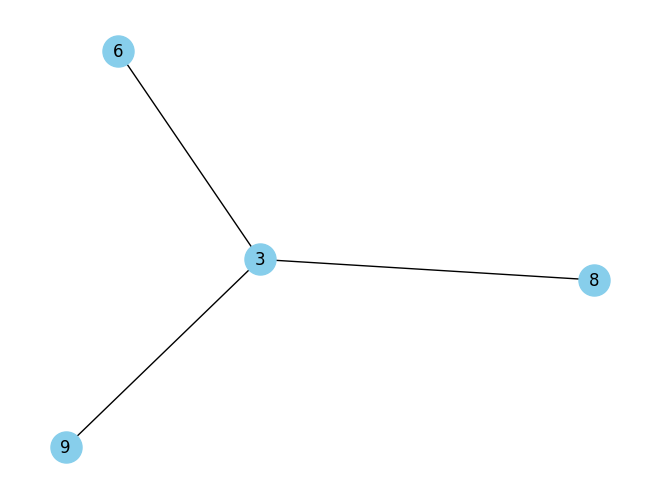

step 131: start a new part dag {}
step 136: Section 27 constructed!
[(7, 3), (3, 9), (8, 3), (3, 9)]


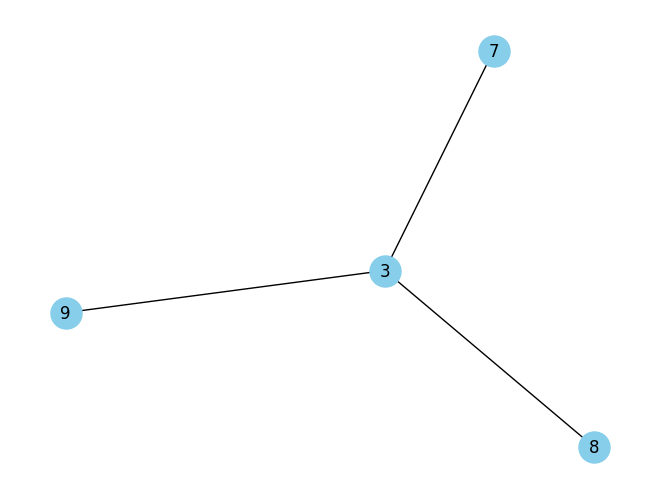

step 136: start a new part dag {}
step 141: Section 28 constructed!
[(5, 3), (3, 9), (8, 3), (3, 9)]


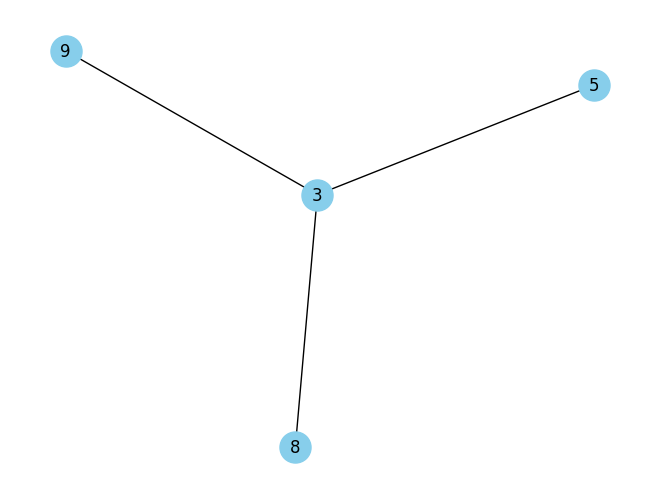

step 141: start a new part dag {}
step 146: Section 29 constructed!
[(7, 3), (3, 9), (8, 3), (3, 9)]


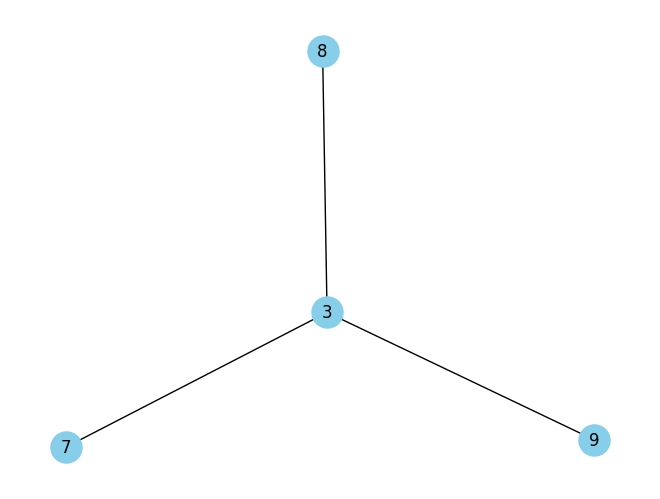

step 146: start a new part dag {}
step 151: Section 30 constructed!
[(6, 3), (3, 9), (8, 3), (3, 9)]


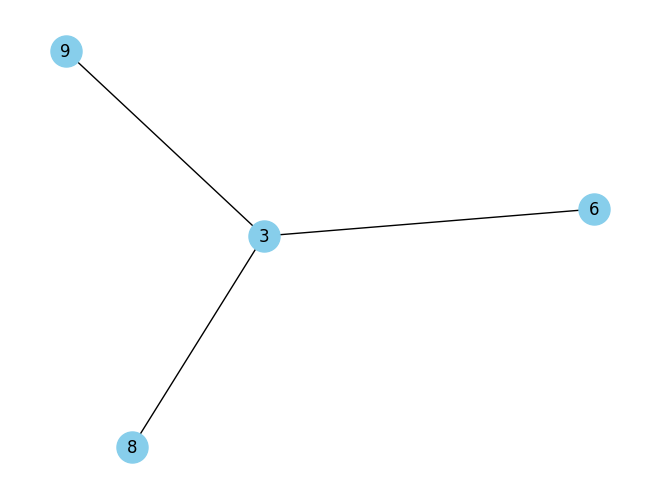

step 151: start a new part dag {}
step 156: Section 31 constructed!
[(7, 3), (3, 9), (8, 3), (3, 9)]


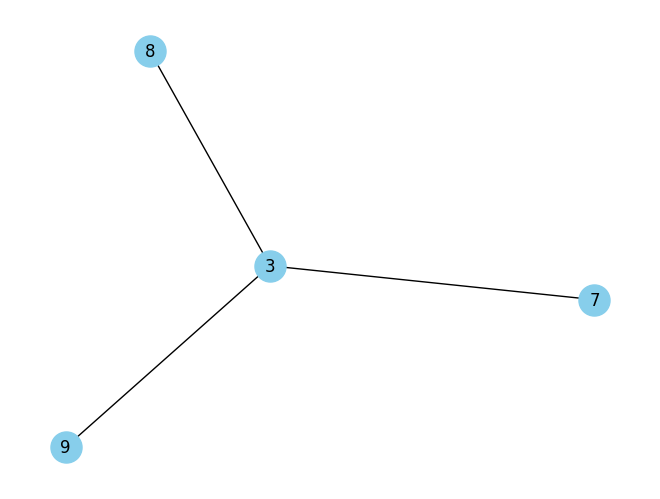

step 156: start a new part dag {}
step 161: Section 32 constructed!
[(3, 2), (2, 9), (8, 2), (2, 9)]


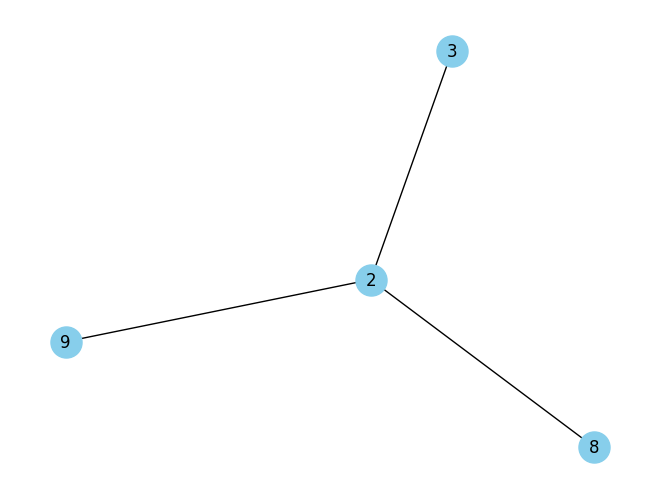

step 161: start a new part dag {}
step 166: Section 33 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


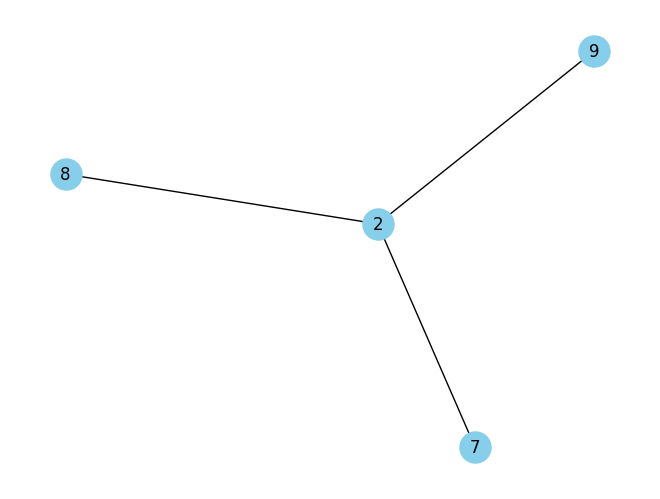

step 166: start a new part dag {}
step 171: Section 34 constructed!
[(6, 2), (2, 9), (8, 2), (2, 9)]


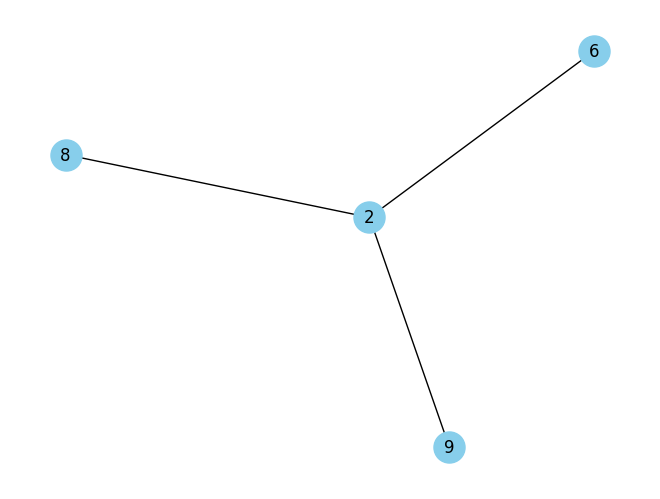

step 171: start a new part dag {}
step 176: Section 35 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


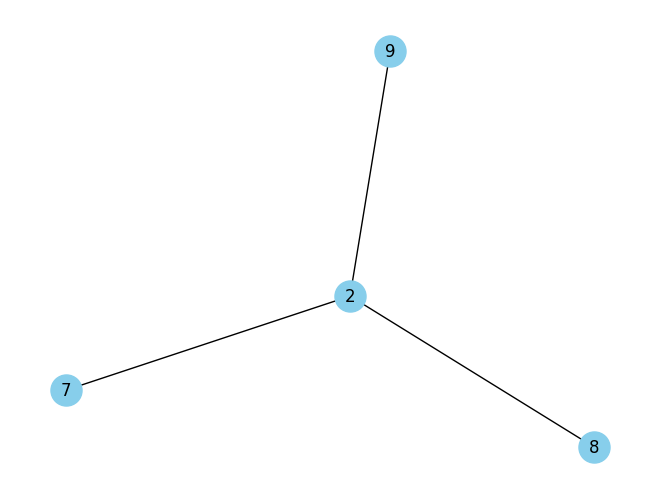

step 176: start a new part dag {}
step 181: Section 36 constructed!
[(5, 2), (2, 9), (8, 2), (2, 9)]


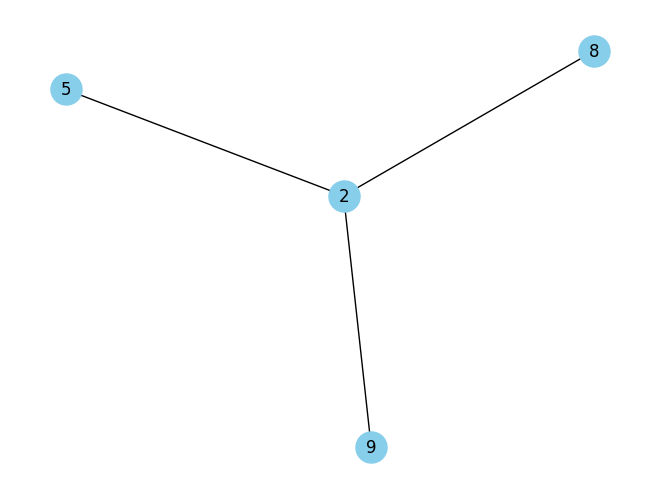

step 181: start a new part dag {}
step 186: Section 37 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


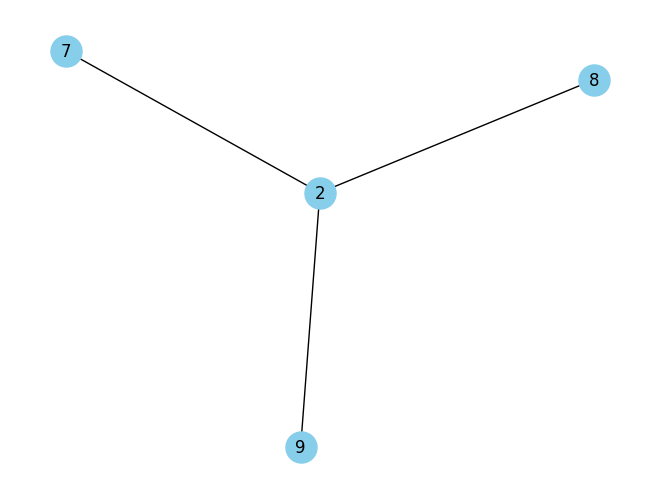

step 186: start a new part dag {}
step 191: Section 38 constructed!
[(6, 2), (2, 9), (8, 2), (2, 9)]


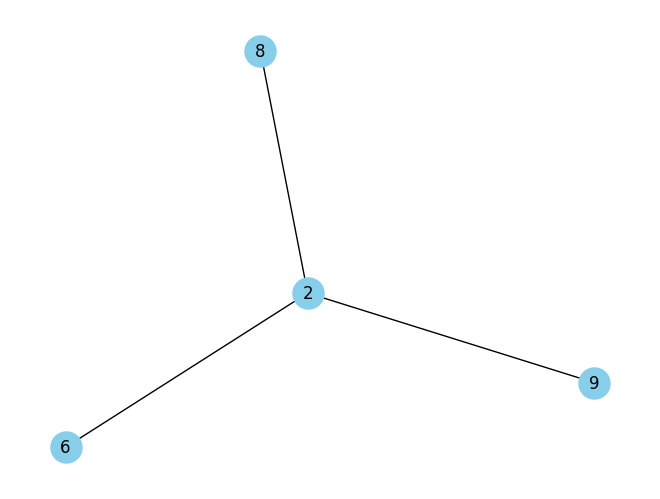

step 191: start a new part dag {}
step 196: Section 39 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


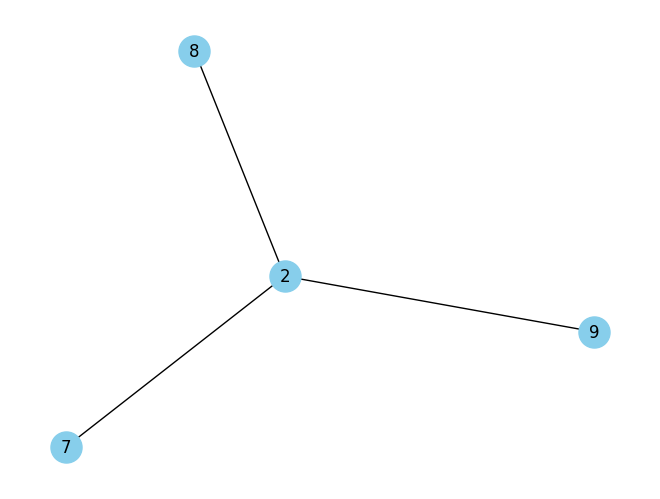

step 196: start a new part dag {}
step 201: Section 40 constructed!
[(4, 2), (2, 9), (8, 2), (2, 9)]


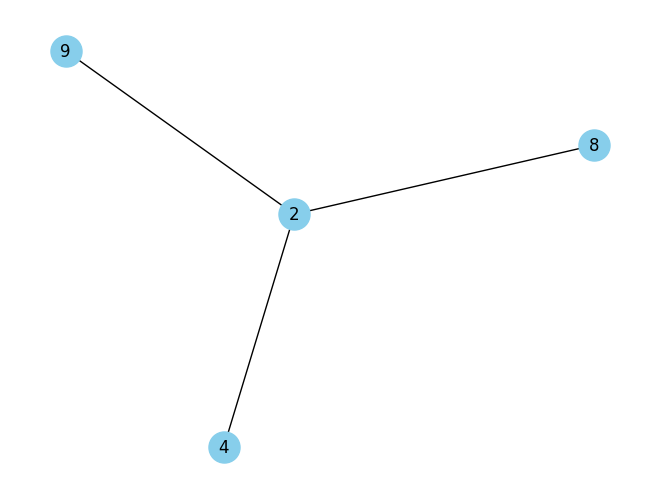

step 201: start a new part dag {}
step 206: Section 41 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


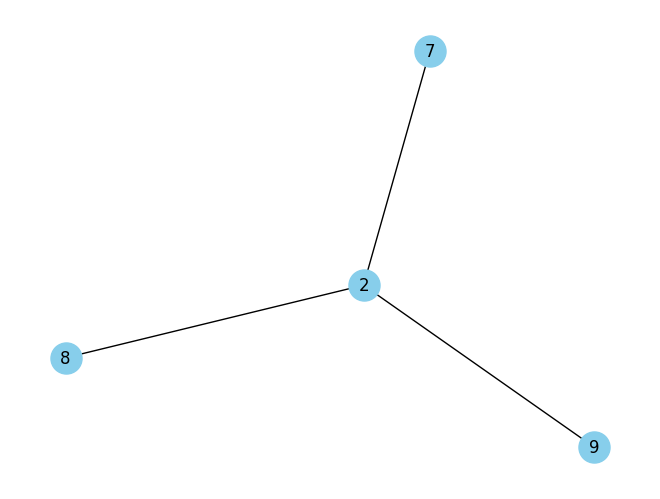

step 206: start a new part dag {}
step 211: Section 42 constructed!
[(6, 2), (2, 9), (8, 2), (2, 9)]


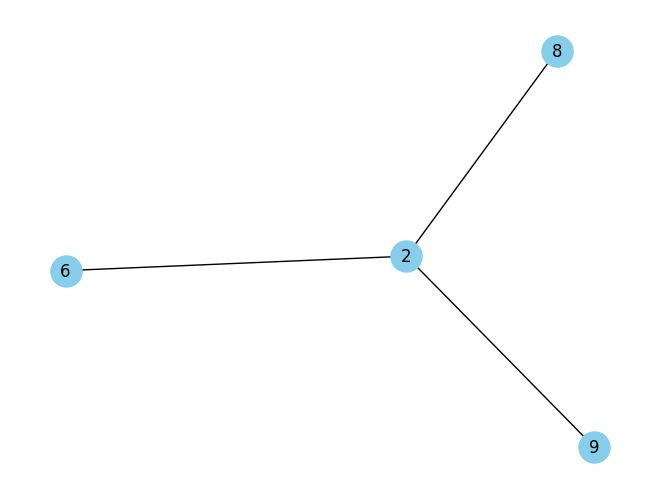

step 211: start a new part dag {}
step 216: Section 43 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


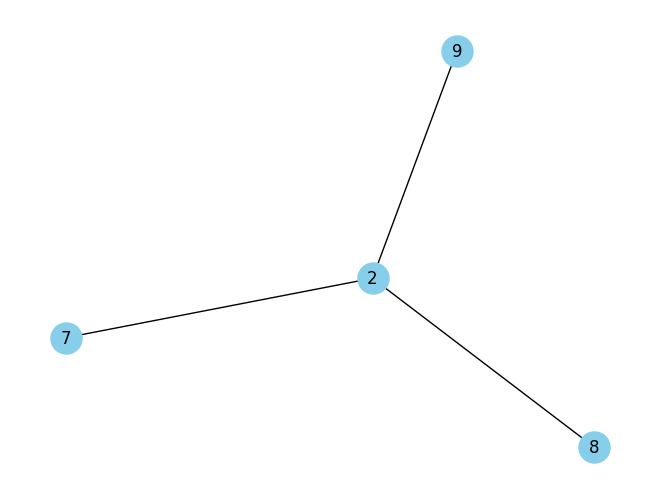

step 216: start a new part dag {}
step 221: Section 44 constructed!
[(5, 2), (2, 9), (8, 2), (2, 9)]


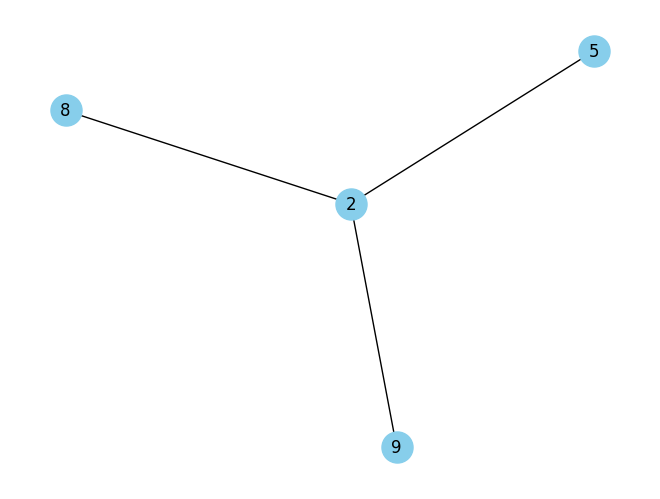

step 221: start a new part dag {}
step 226: Section 45 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


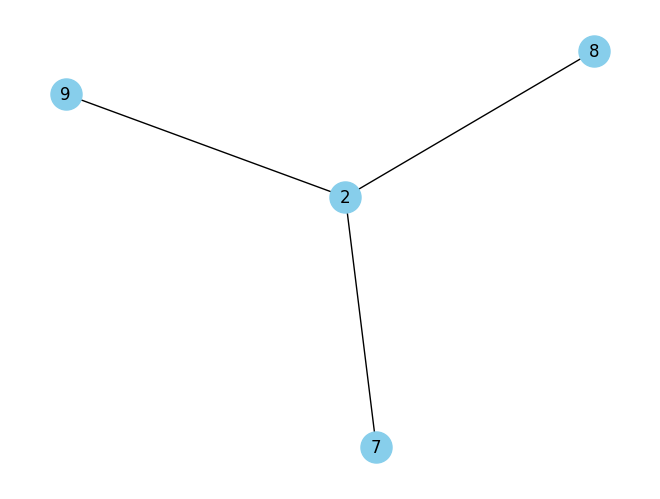

step 226: start a new part dag {}
step 231: Section 46 constructed!
[(6, 2), (2, 9), (8, 2), (2, 9)]


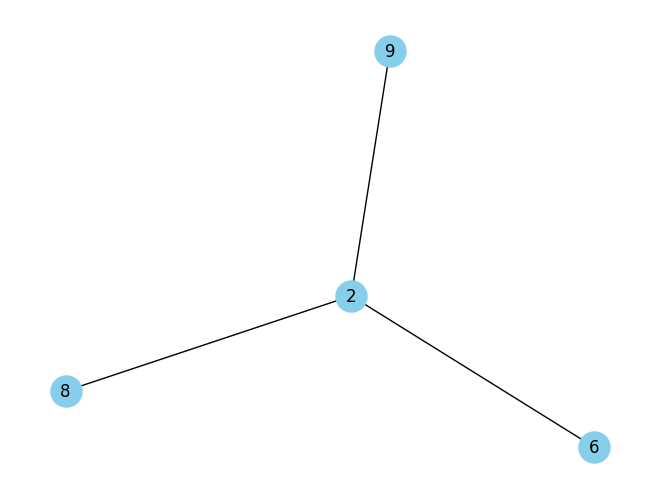

step 231: start a new part dag {}
step 236: Section 47 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


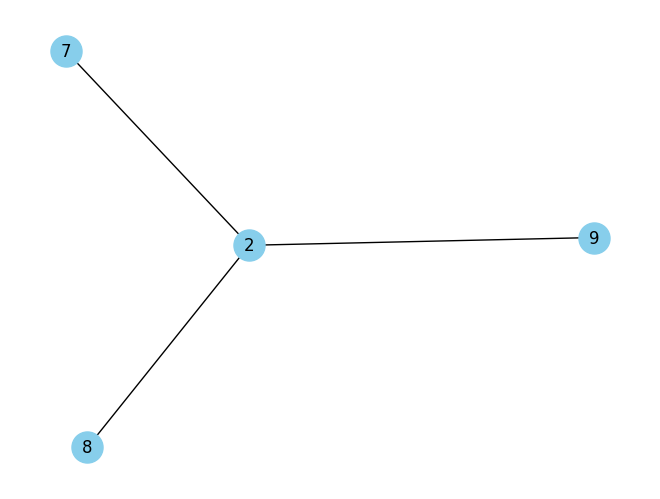

step 236: start a new part dag {}
step 241: Section 48 constructed!
[(3, 2), (2, 9), (8, 2), (2, 9)]


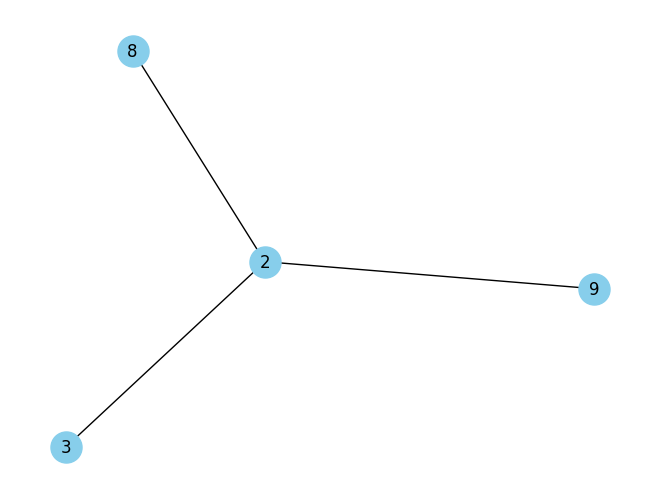

step 241: start a new part dag {}
step 246: Section 49 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


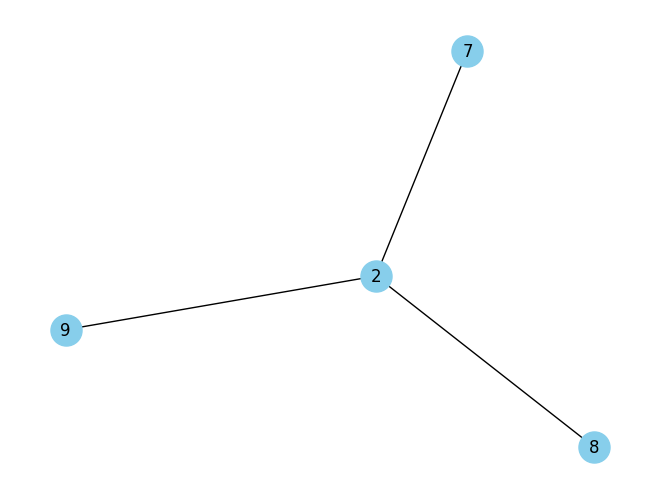

step 246: start a new part dag {}
step 251: Section 50 constructed!
[(6, 2), (2, 9), (8, 2), (2, 9)]


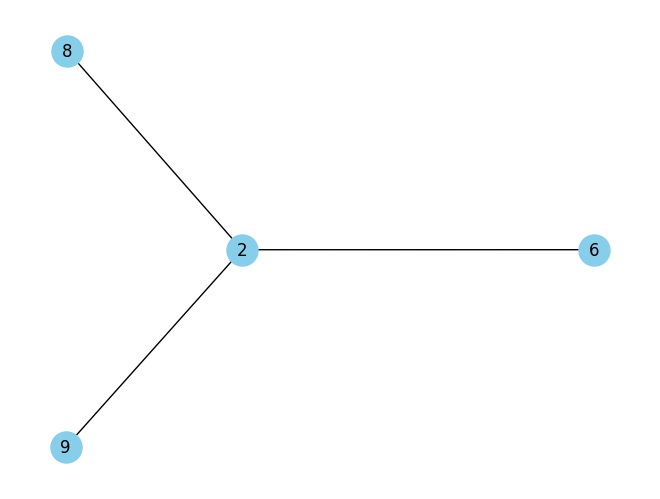

step 251: start a new part dag {}
step 256: Section 51 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


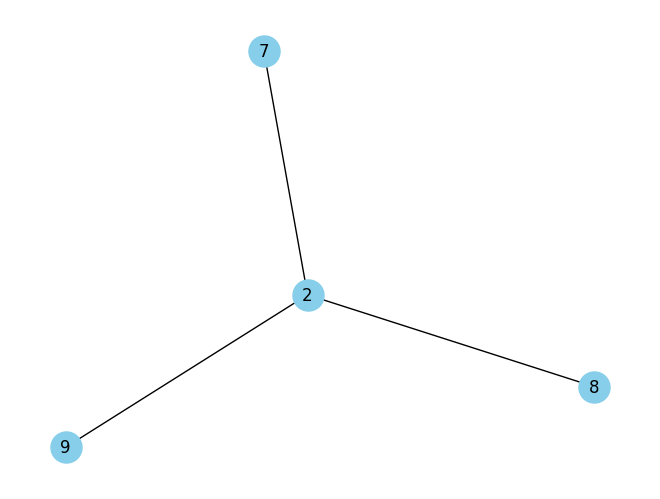

step 256: start a new part dag {}
step 261: Section 52 constructed!
[(5, 2), (2, 9), (8, 2), (2, 9)]


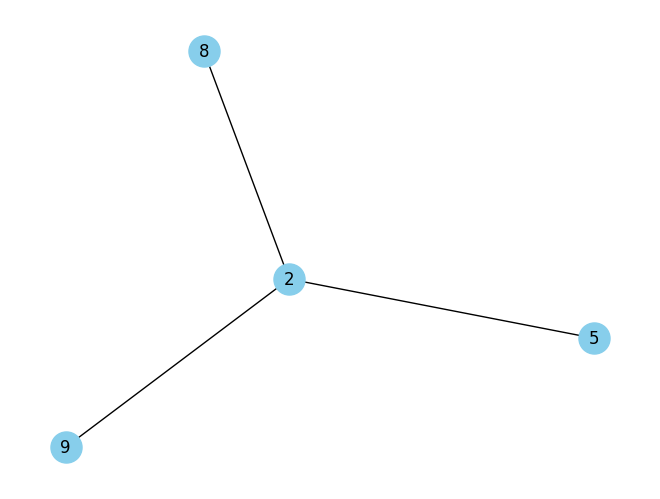

step 261: start a new part dag {}
step 266: Section 53 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


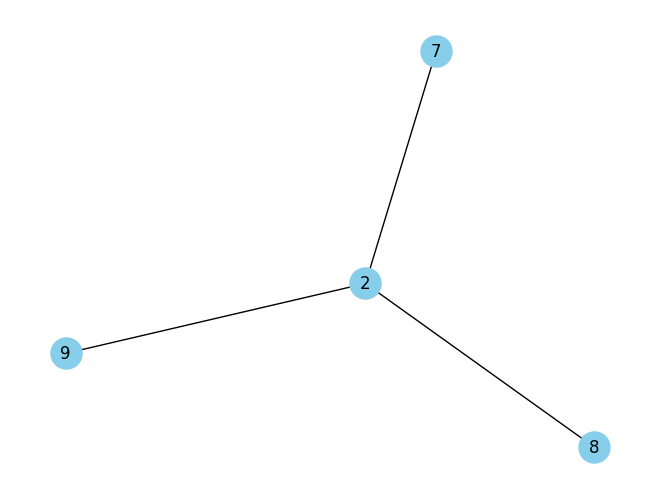

step 266: start a new part dag {}
step 271: Section 54 constructed!
[(6, 2), (2, 9), (8, 2), (2, 9)]


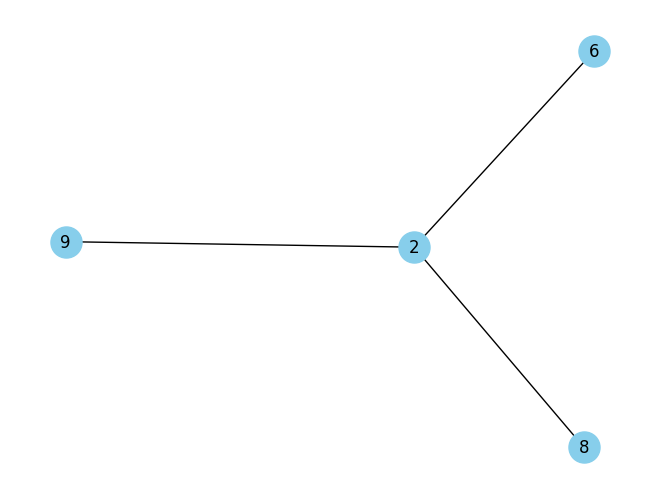

step 271: start a new part dag {}
step 276: Section 55 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


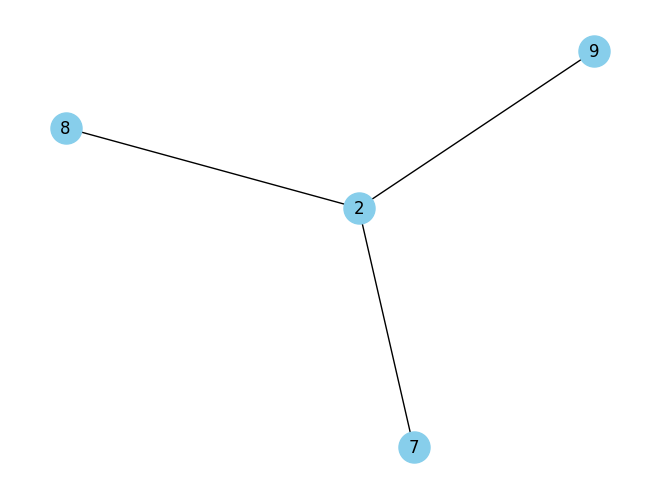

step 276: start a new part dag {}
step 281: Section 56 constructed!
[(4, 2), (2, 9), (8, 2), (2, 9)]


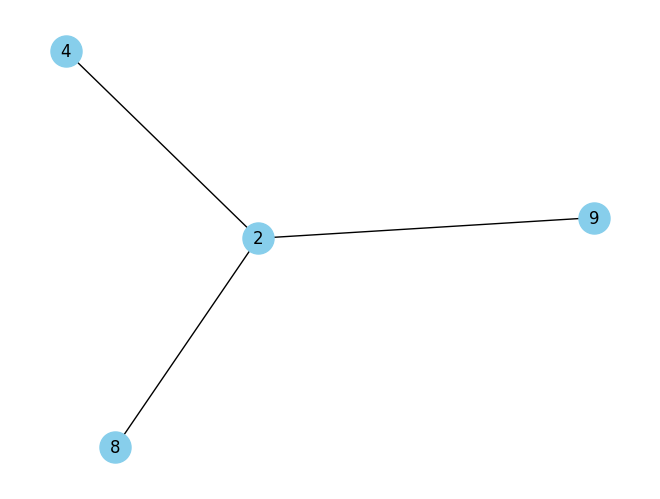

step 281: start a new part dag {}
step 286: Section 57 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


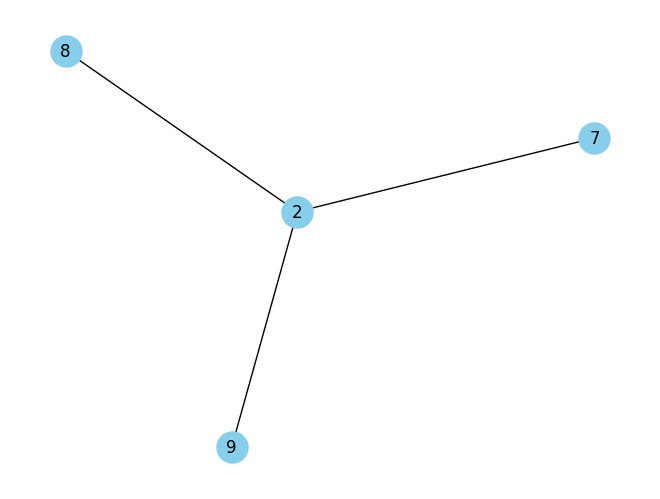

step 286: start a new part dag {}
step 291: Section 58 constructed!
[(6, 2), (2, 9), (8, 2), (2, 9)]


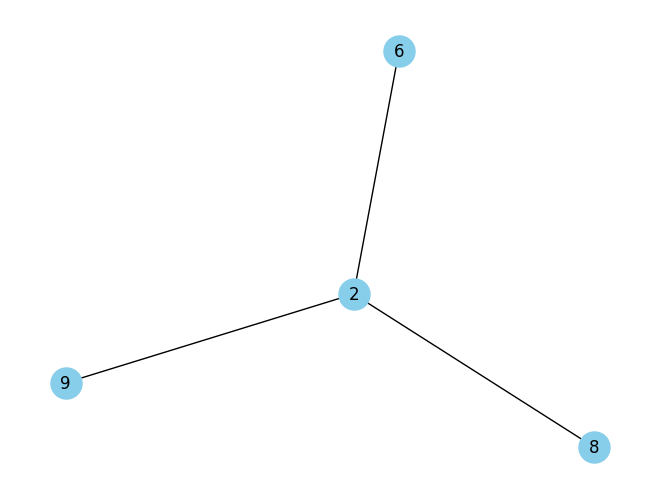

step 291: start a new part dag {}
step 296: Section 59 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


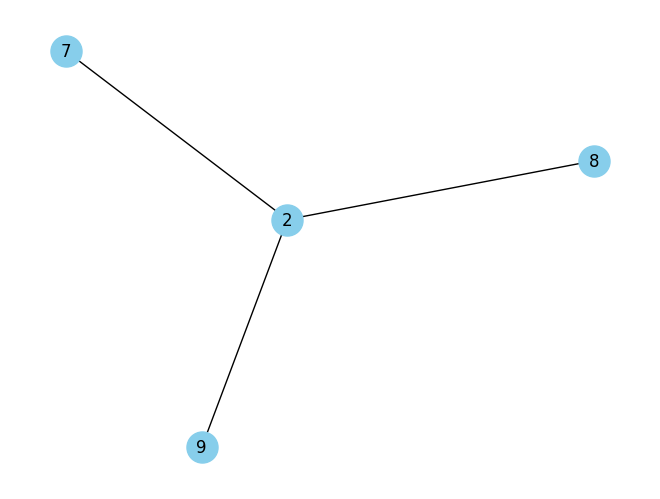

step 296: start a new part dag {}
step 301: Section 60 constructed!
[(5, 2), (2, 9), (8, 2), (2, 9)]


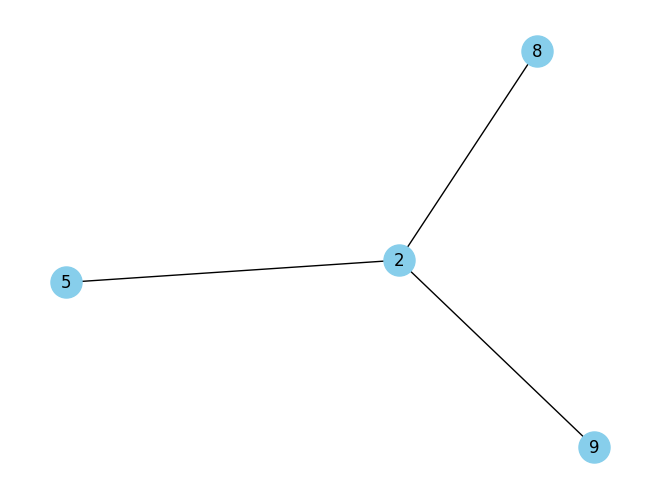

step 301: start a new part dag {}
step 306: Section 61 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


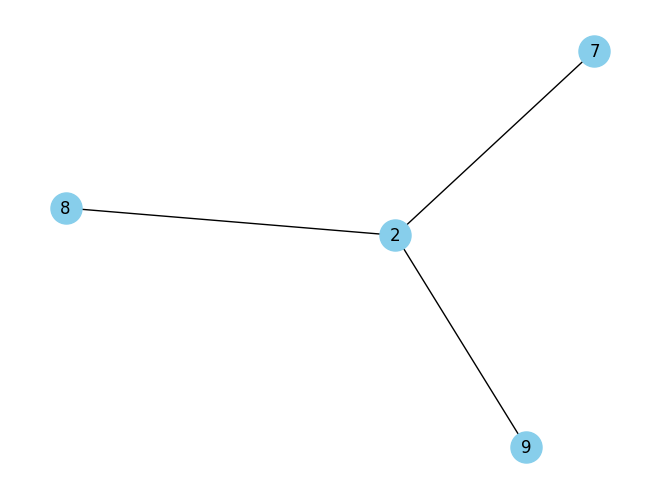

step 306: start a new part dag {}
step 311: Section 62 constructed!
[(6, 2), (2, 9), (8, 2), (2, 9)]


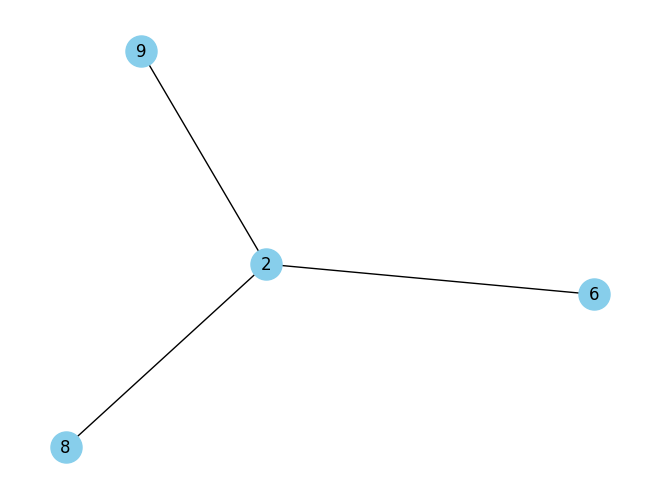

step 311: start a new part dag {}
step 316: Section 63 constructed!
[(7, 2), (2, 9), (8, 2), (2, 9)]


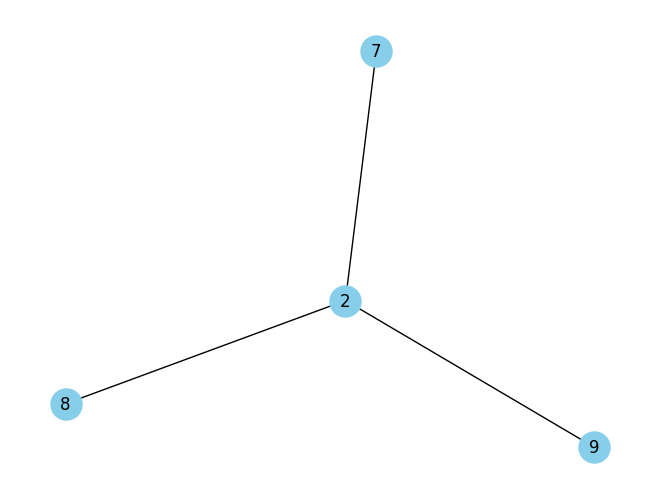

step 316: start a new part dag {}
step 321: Section 64 constructed!
[(2, 1), (1, 9), (8, 1), (1, 9)]


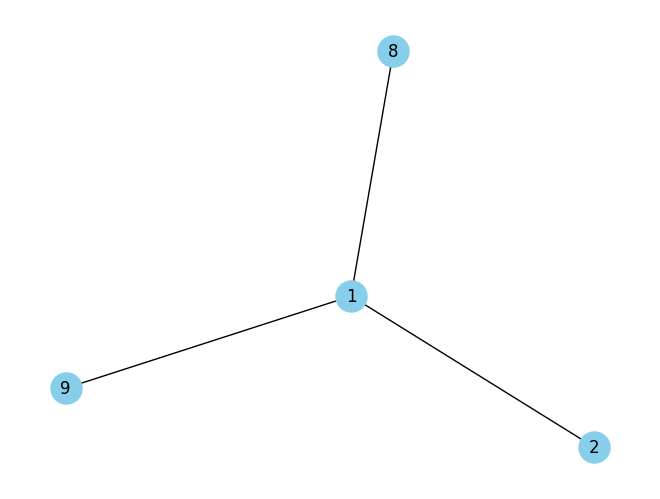

step 321: start a new part dag {}
step 326: Section 65 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


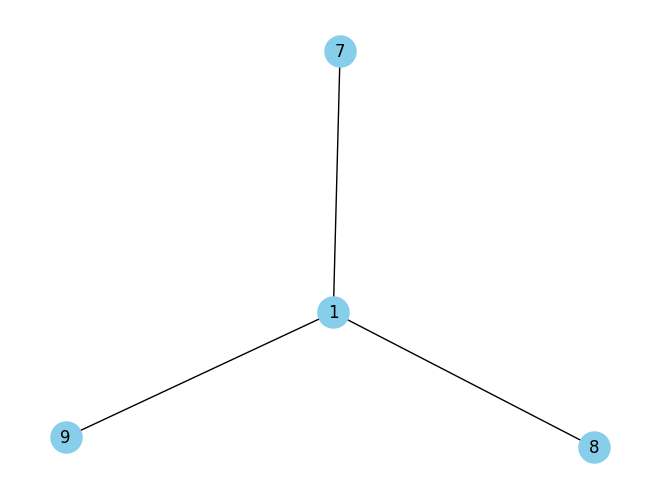

step 326: start a new part dag {}
step 331: Section 66 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


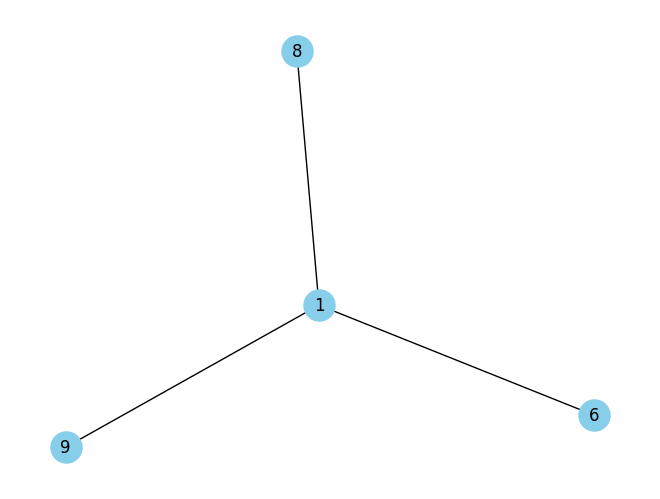

step 331: start a new part dag {}
step 336: Section 67 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


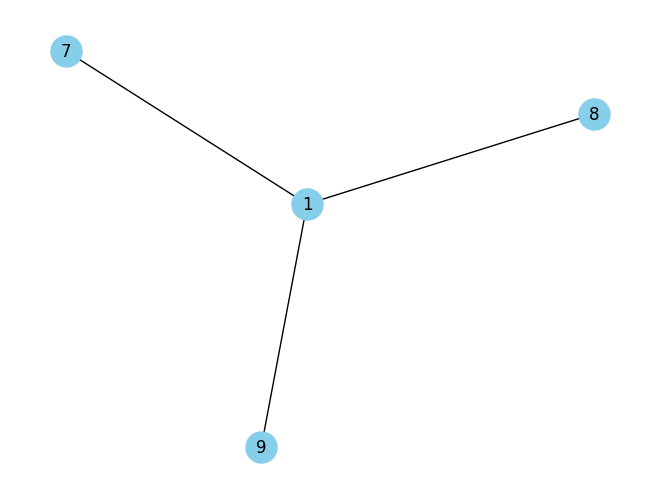

step 336: start a new part dag {}
step 341: Section 68 constructed!
[(5, 1), (1, 9), (8, 1), (1, 9)]


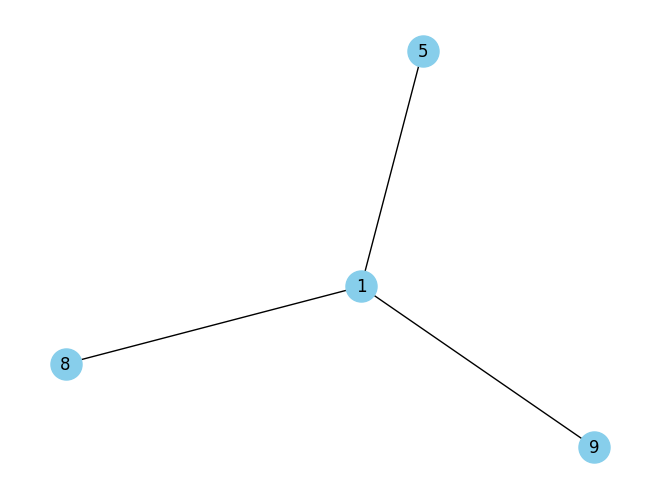

step 341: start a new part dag {}
step 346: Section 69 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


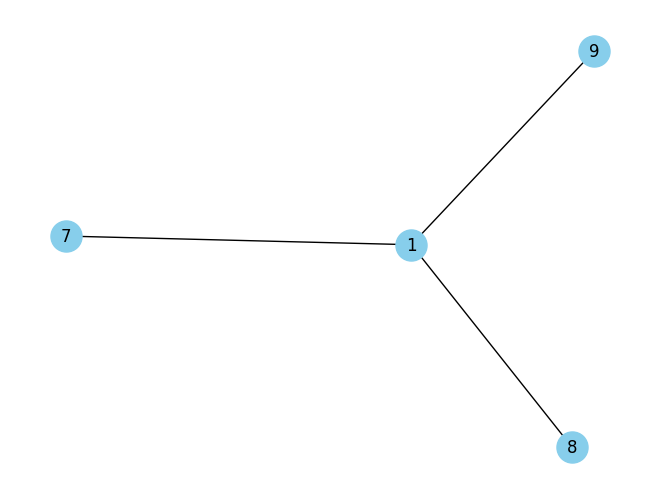

step 346: start a new part dag {}
step 351: Section 70 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


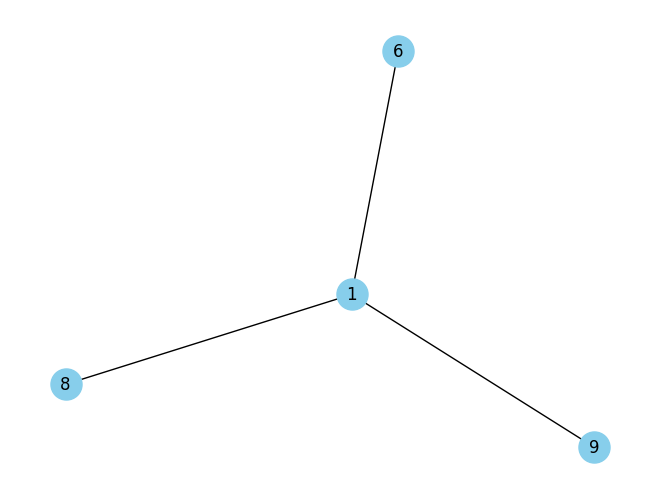

step 351: start a new part dag {}
step 356: Section 71 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


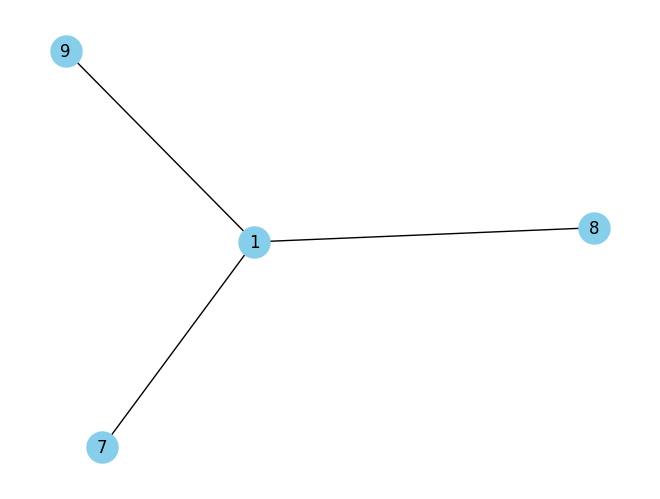

step 356: start a new part dag {}
step 361: Section 72 constructed!
[(4, 1), (1, 9), (8, 1), (1, 9)]


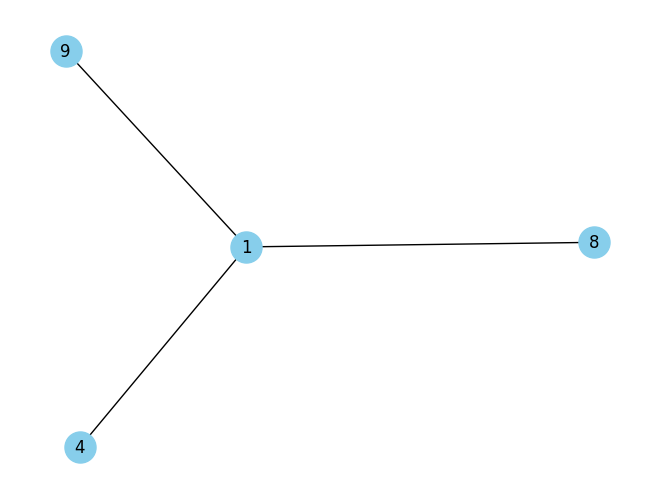

step 361: start a new part dag {}
step 366: Section 73 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


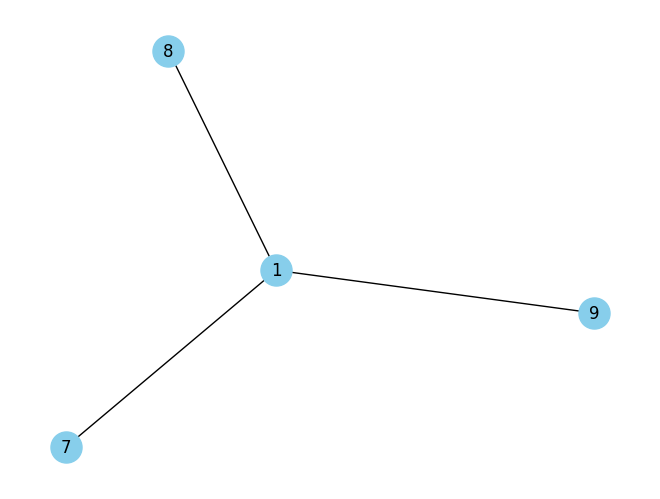

step 366: start a new part dag {}
step 371: Section 74 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


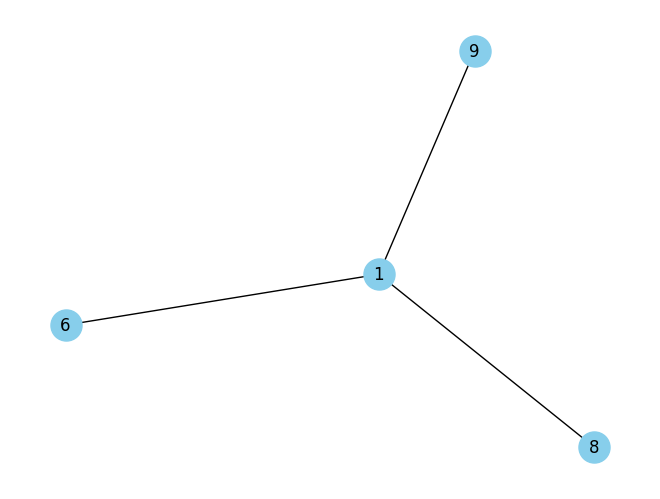

step 371: start a new part dag {}
step 376: Section 75 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


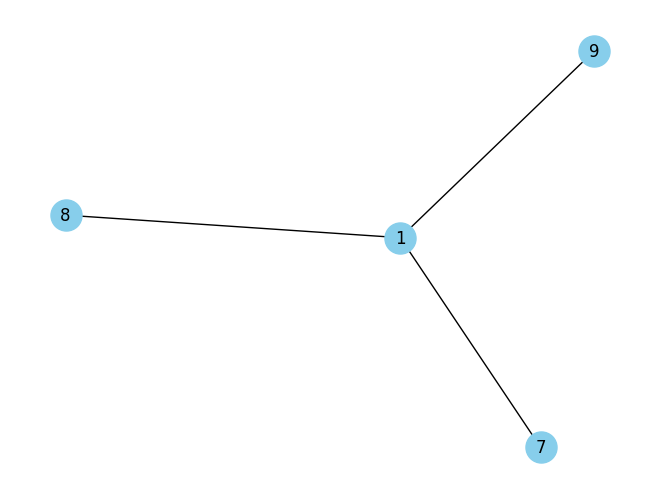

step 376: start a new part dag {}
step 381: Section 76 constructed!
[(5, 1), (1, 9), (8, 1), (1, 9)]


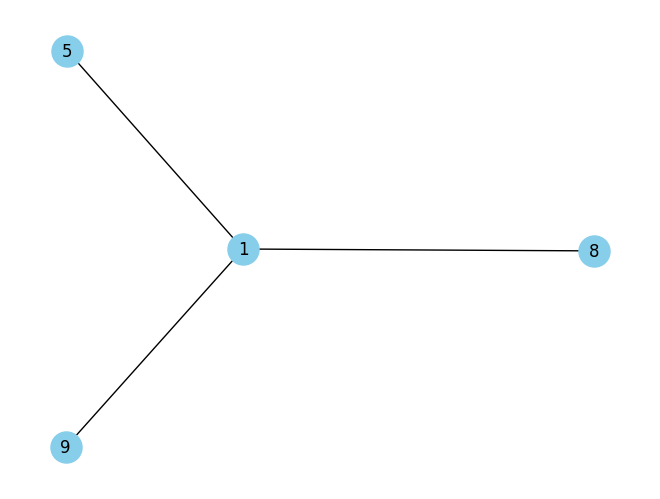

step 381: start a new part dag {}
step 386: Section 77 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


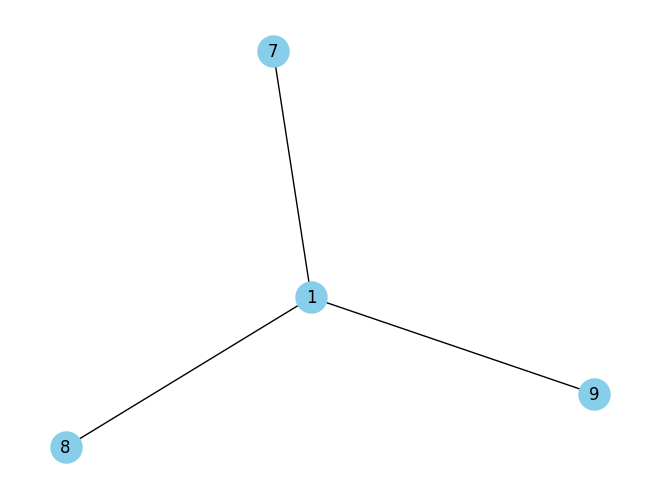

step 386: start a new part dag {}
step 391: Section 78 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


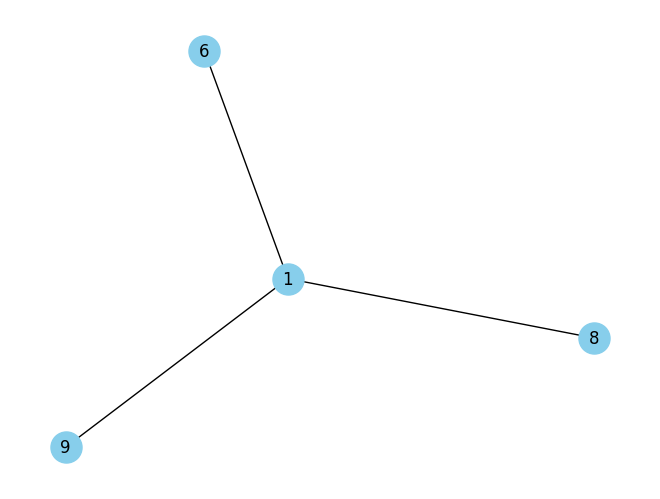

step 391: start a new part dag {}
step 396: Section 79 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


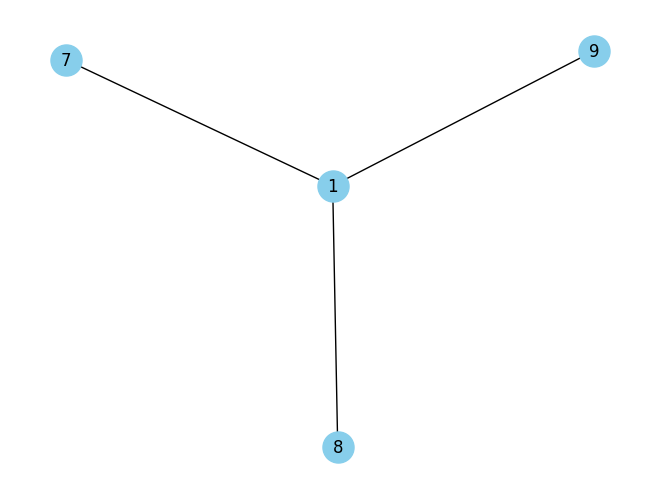

step 396: start a new part dag {}
step 401: Section 80 constructed!
[(3, 1), (1, 9), (8, 1), (1, 9)]


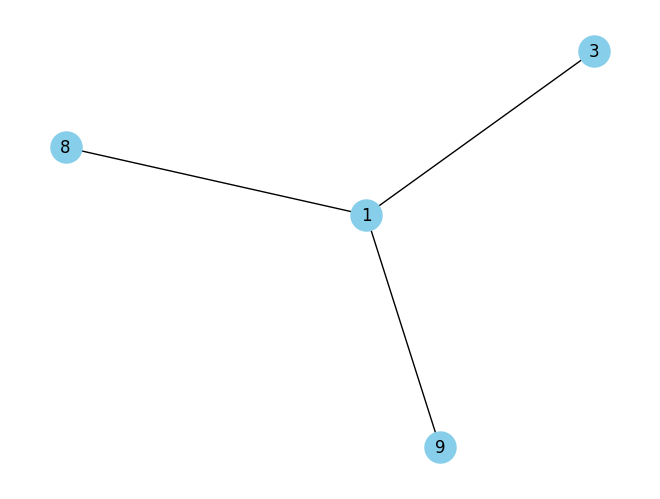

step 401: start a new part dag {}
step 406: Section 81 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


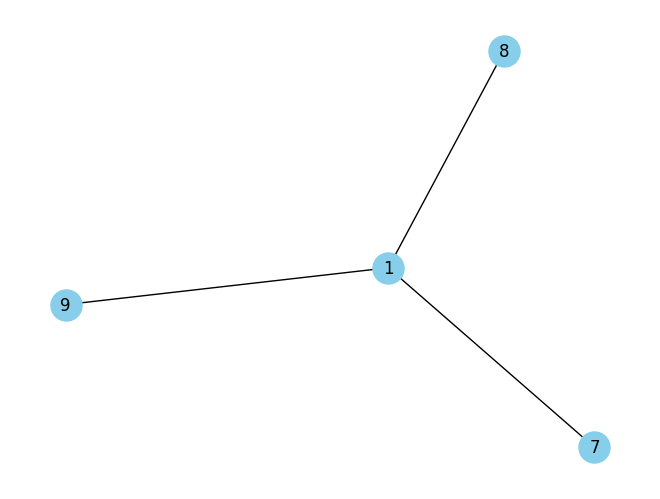

step 406: start a new part dag {}
step 411: Section 82 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


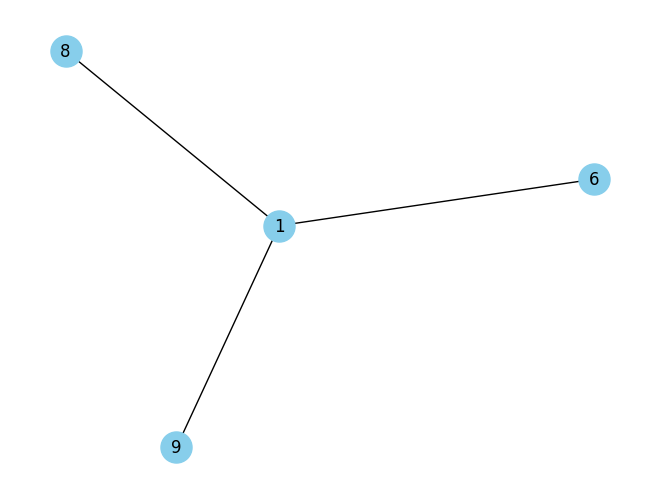

step 411: start a new part dag {}
step 416: Section 83 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


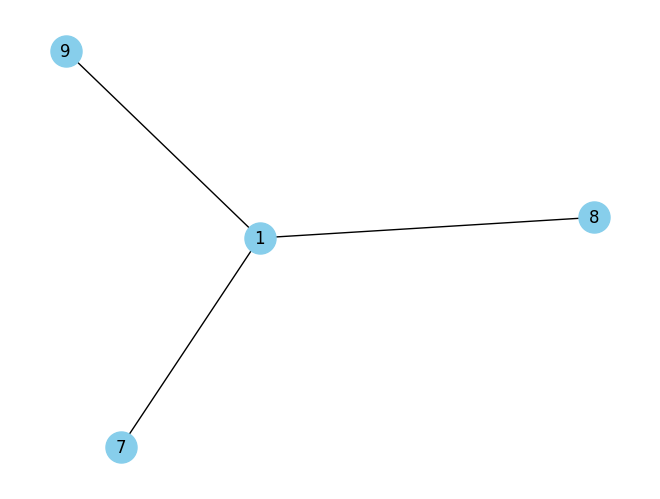

step 416: start a new part dag {}
step 421: Section 84 constructed!
[(5, 1), (1, 9), (8, 1), (1, 9)]


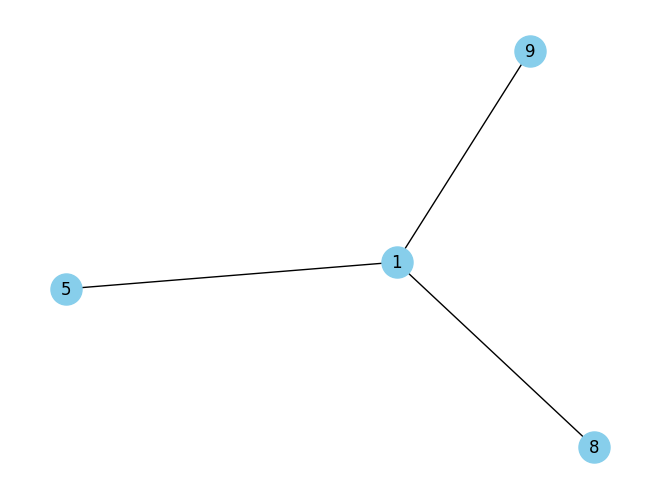

step 421: start a new part dag {}
step 426: Section 85 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


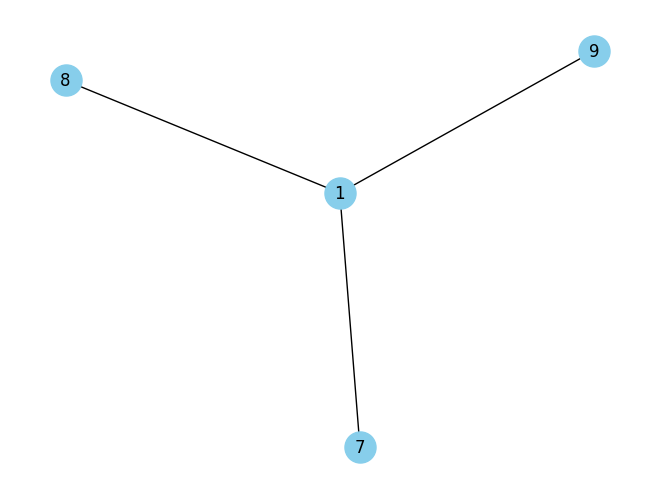

step 426: start a new part dag {}
step 431: Section 86 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


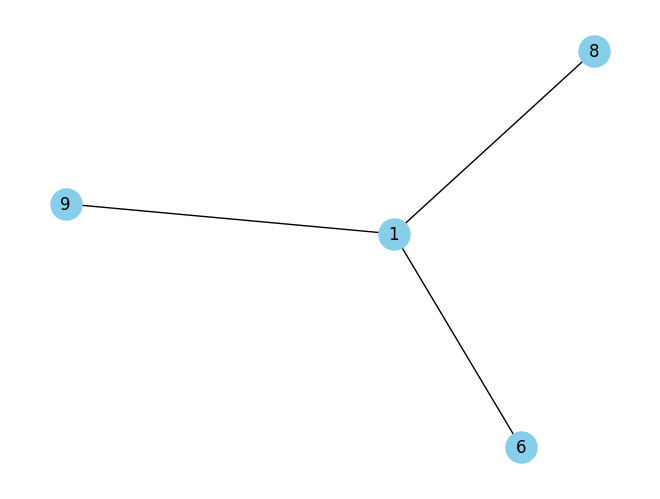

step 431: start a new part dag {}
step 436: Section 87 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


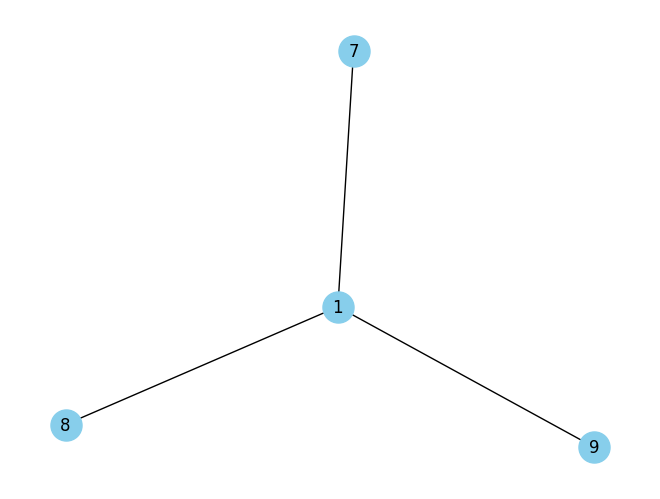

step 436: start a new part dag {}
step 441: Section 88 constructed!
[(4, 1), (1, 9), (8, 1), (1, 9)]


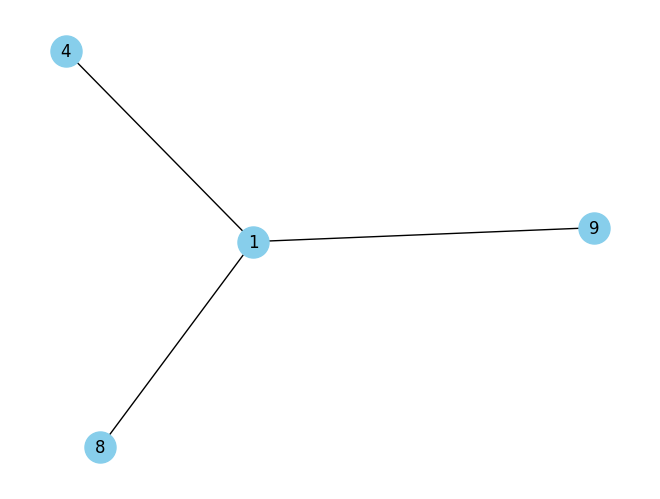

step 441: start a new part dag {}
step 446: Section 89 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


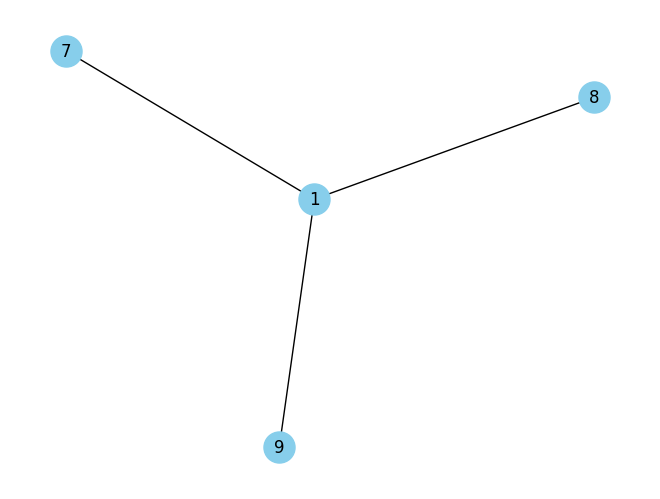

step 446: start a new part dag {}
step 451: Section 90 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


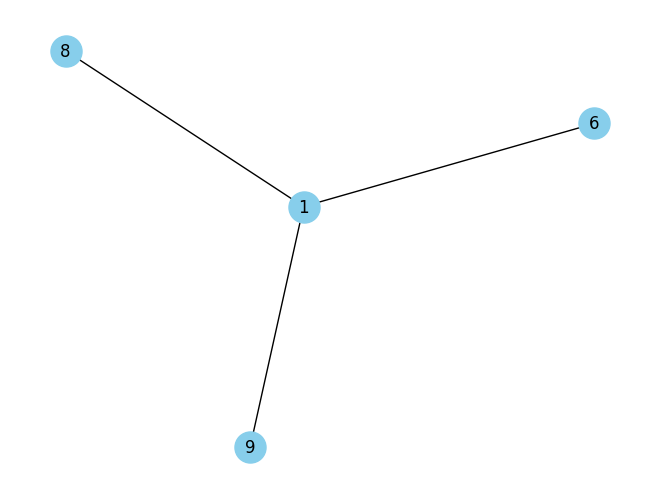

step 451: start a new part dag {}
step 456: Section 91 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


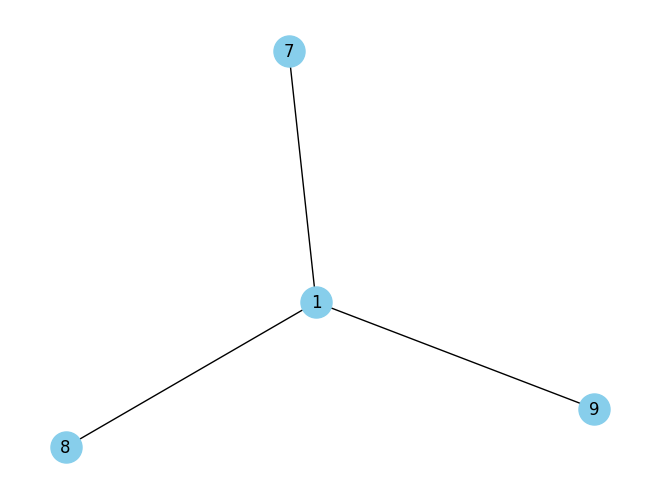

step 456: start a new part dag {}
step 461: Section 92 constructed!
[(5, 1), (1, 9), (8, 1), (1, 9)]


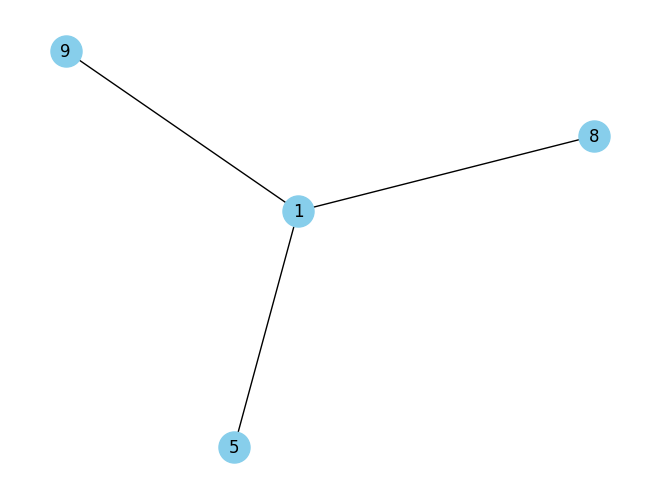

step 461: start a new part dag {}
step 466: Section 93 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


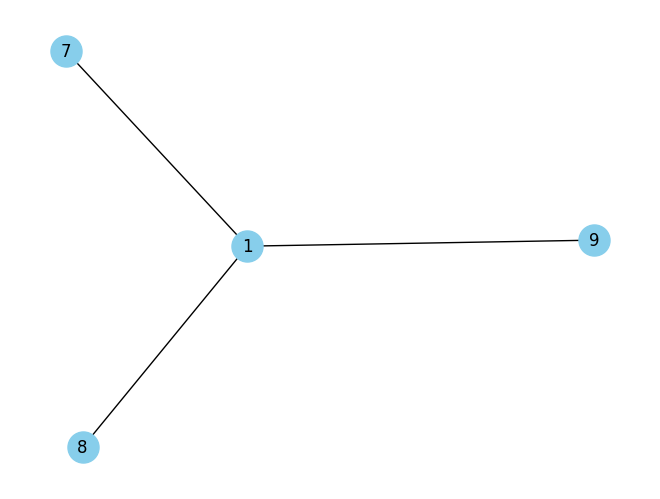

step 466: start a new part dag {}
step 471: Section 94 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


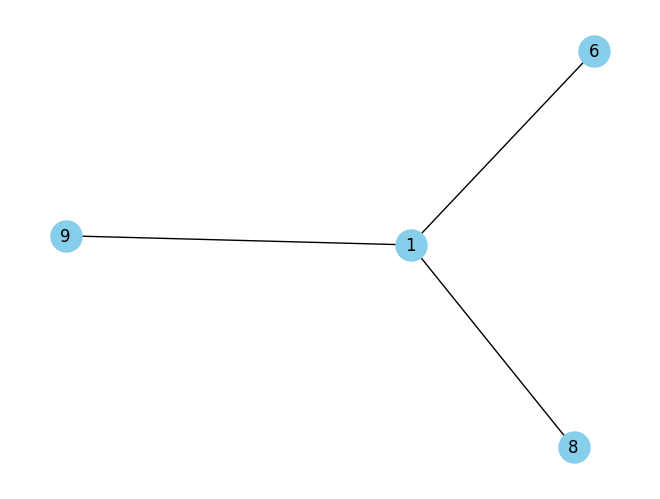

step 471: start a new part dag {}
step 476: Section 95 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


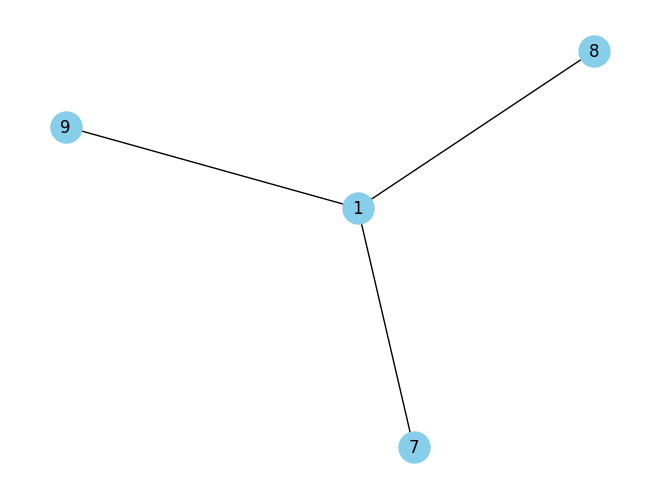

step 476: start a new part dag {}
step 481: Section 96 constructed!
[(2, 1), (1, 9), (8, 1), (1, 9)]


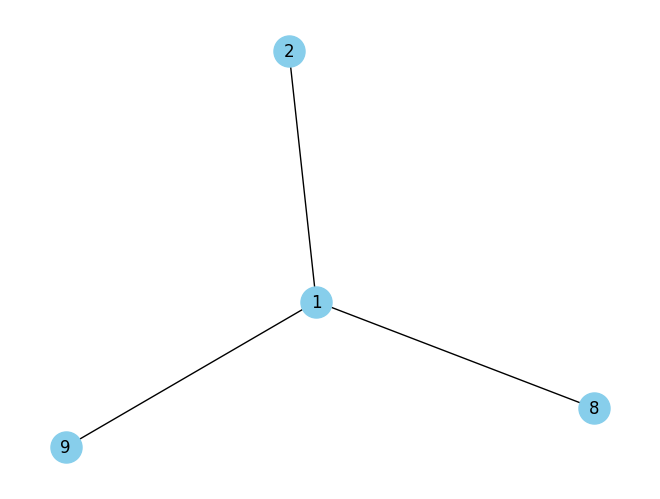

step 481: start a new part dag {}
step 486: Section 97 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


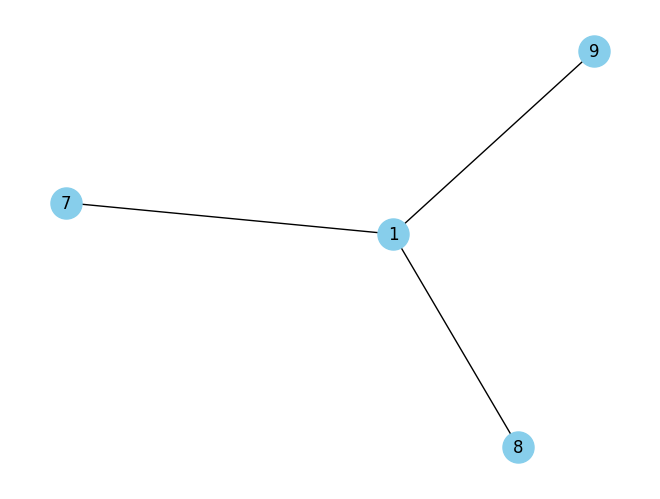

step 486: start a new part dag {}
step 491: Section 98 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


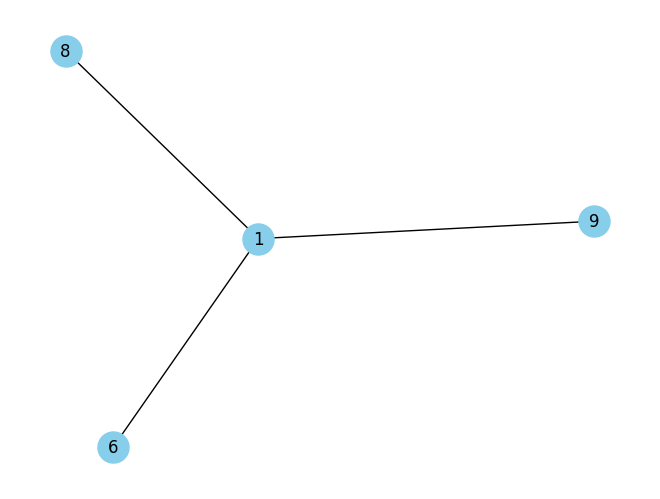

step 491: start a new part dag {}
step 496: Section 99 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


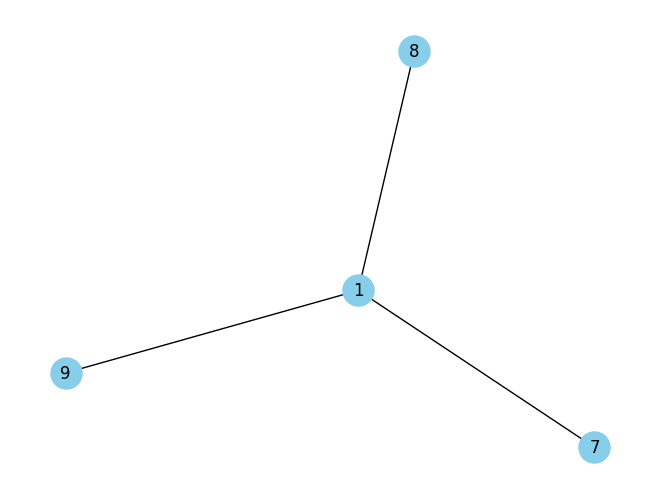

step 496: start a new part dag {}
step 501: Section 100 constructed!
[(5, 1), (1, 9), (8, 1), (1, 9)]


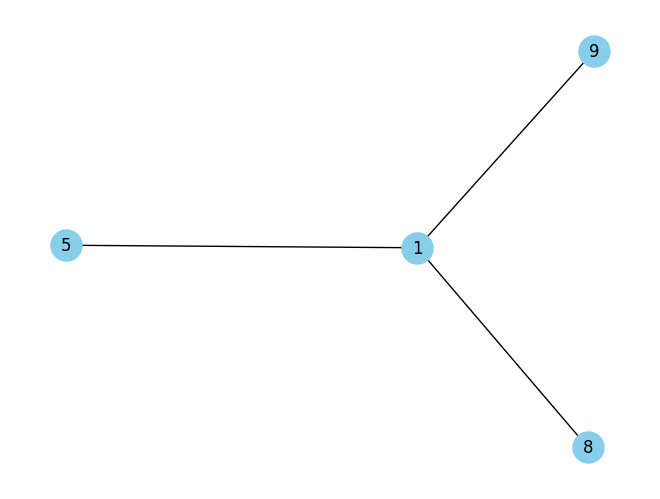

step 501: start a new part dag {}
step 506: Section 101 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


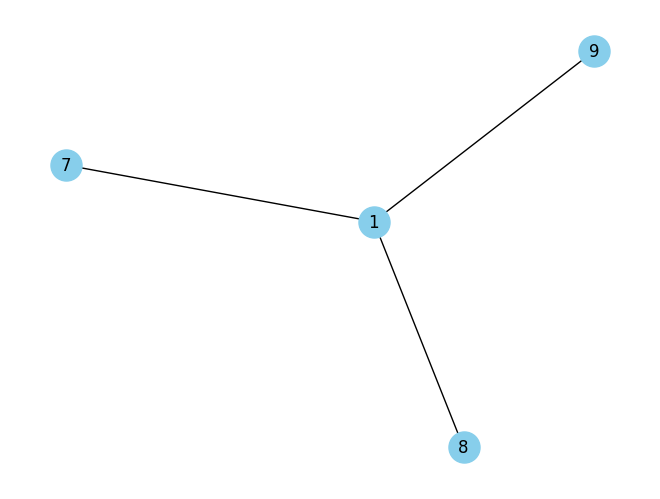

step 506: start a new part dag {}
step 511: Section 102 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


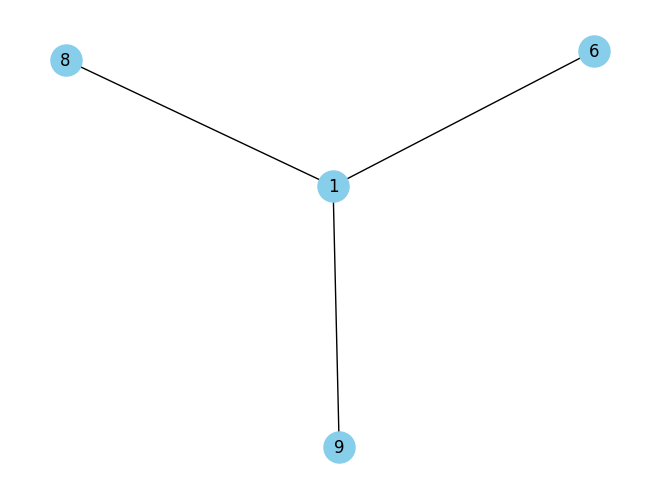

step 511: start a new part dag {}
step 516: Section 103 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


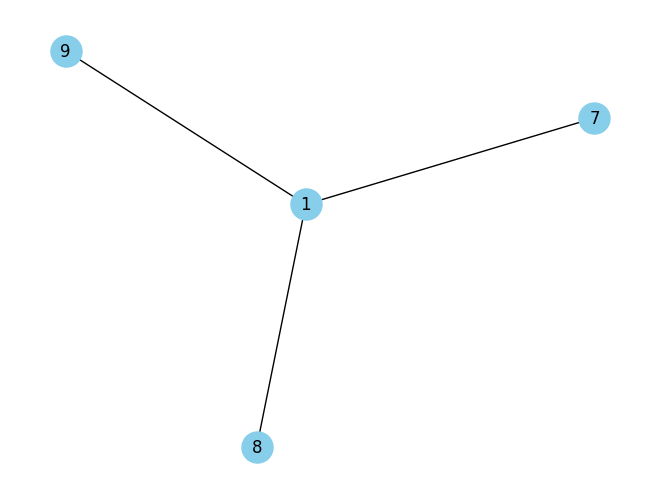

step 516: start a new part dag {}
step 521: Section 104 constructed!
[(4, 1), (1, 9), (8, 1), (1, 9)]


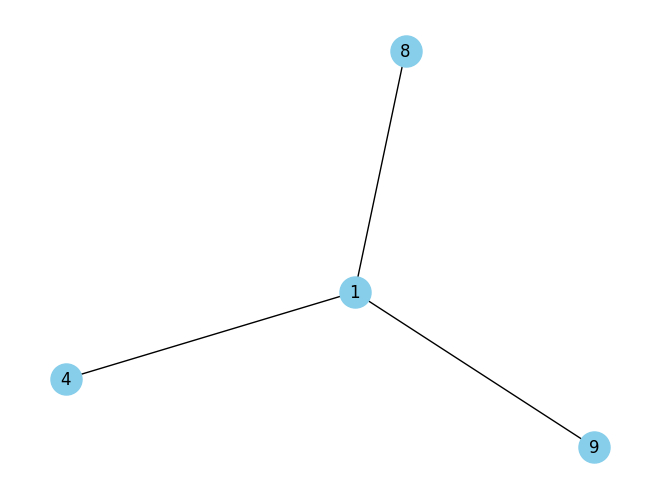

step 521: start a new part dag {}
step 526: Section 105 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


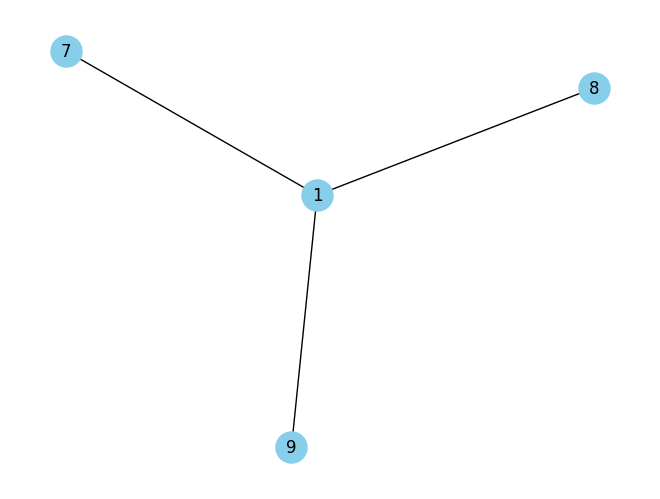

step 526: start a new part dag {}
step 531: Section 106 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


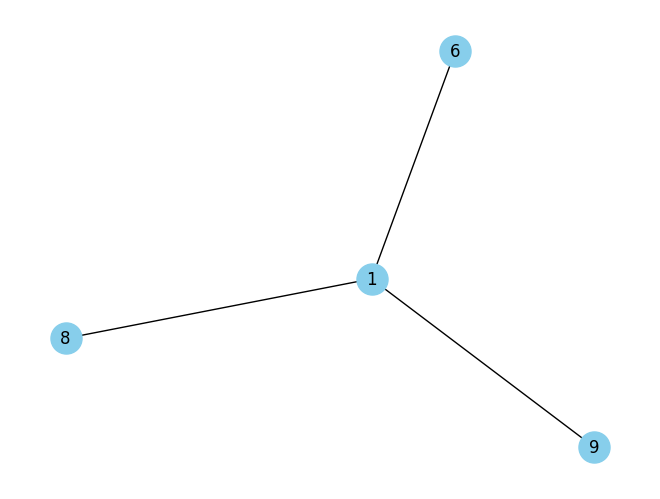

step 531: start a new part dag {}
step 536: Section 107 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


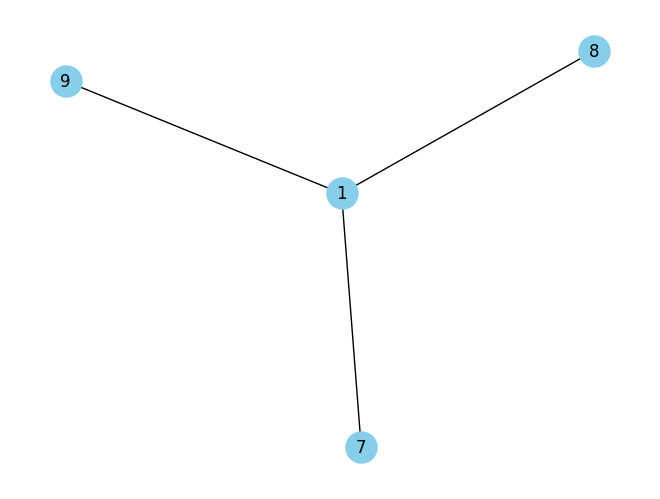

step 536: start a new part dag {}
step 541: Section 108 constructed!
[(5, 1), (1, 9), (8, 1), (1, 9)]


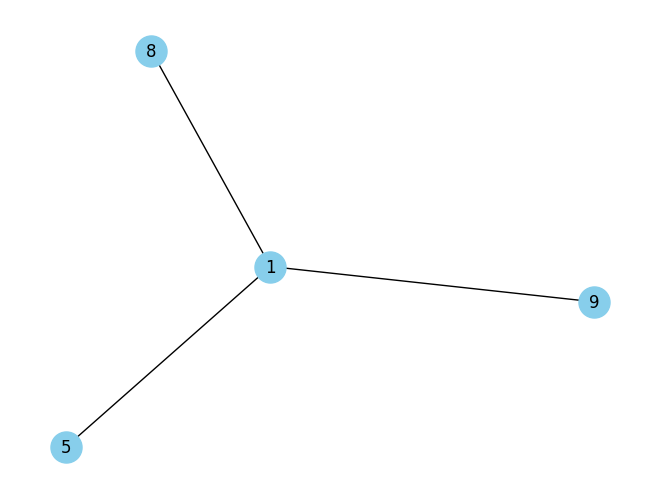

step 541: start a new part dag {}
step 546: Section 109 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


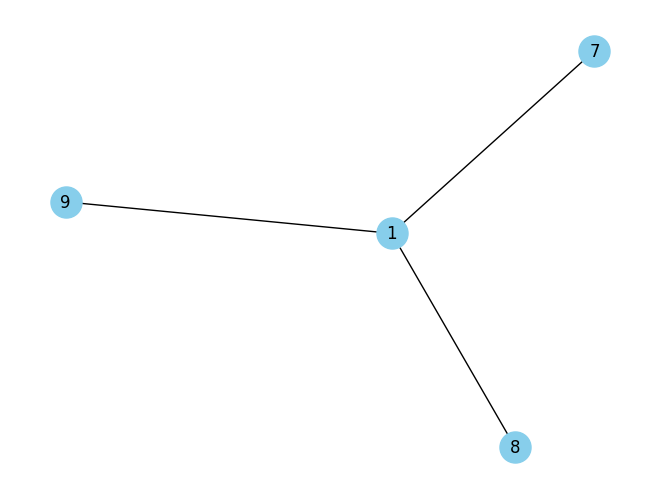

step 546: start a new part dag {}
step 551: Section 110 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


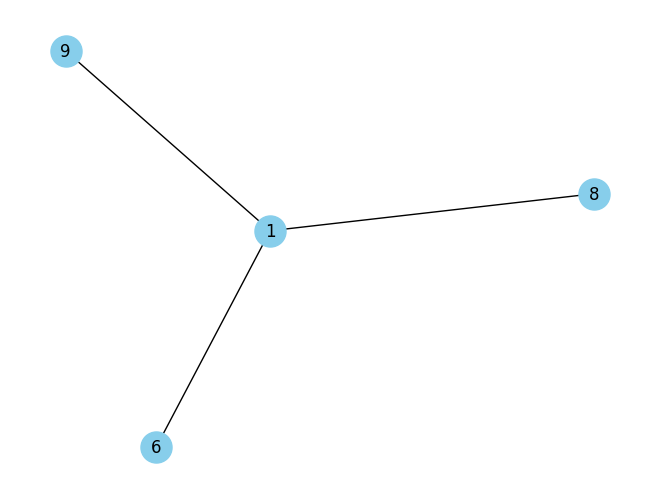

step 551: start a new part dag {}
step 556: Section 111 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


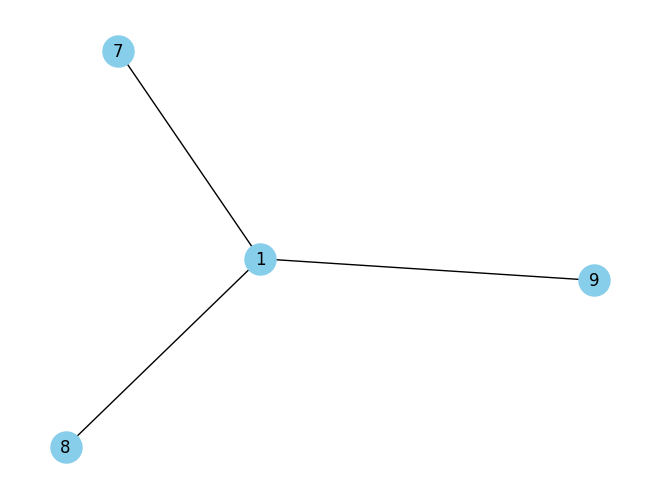

step 556: start a new part dag {}
step 561: Section 112 constructed!
[(3, 1), (1, 9), (8, 1), (1, 9)]


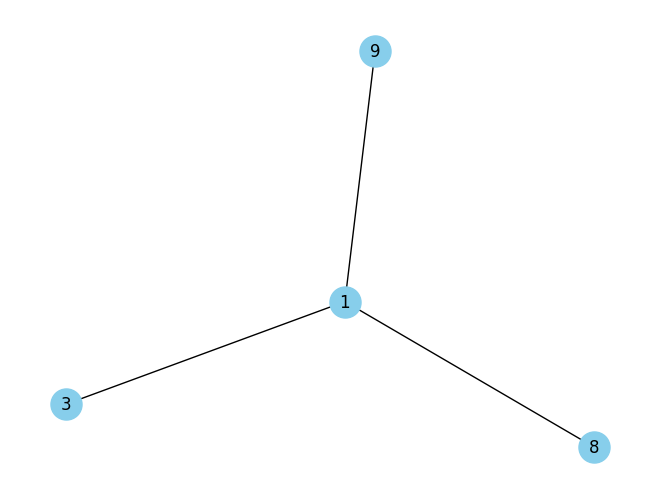

step 561: start a new part dag {}
step 566: Section 113 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


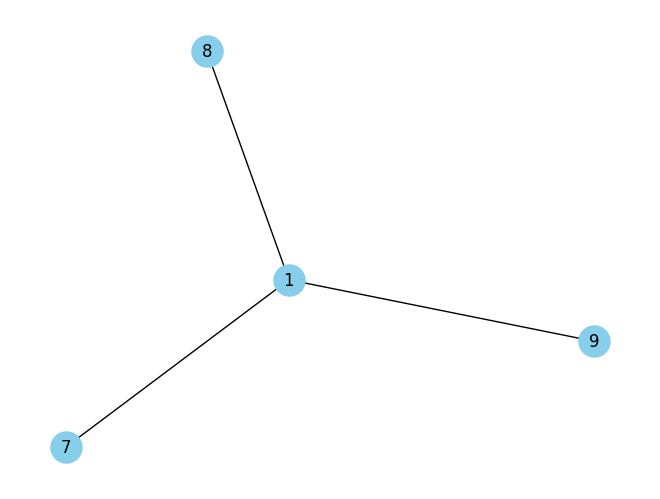

step 566: start a new part dag {}
step 571: Section 114 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


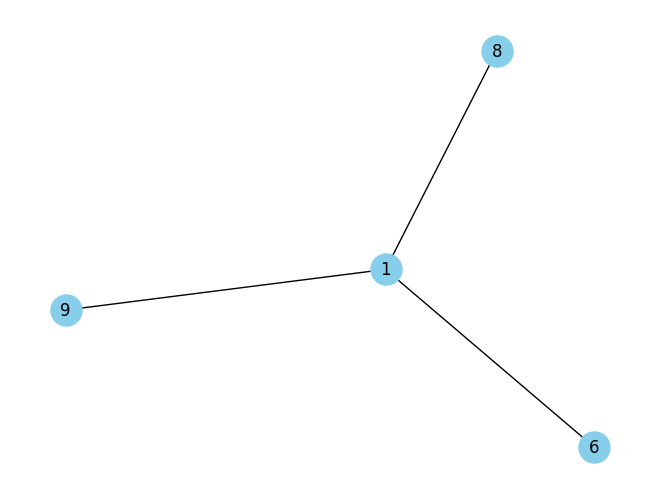

step 571: start a new part dag {}
step 576: Section 115 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


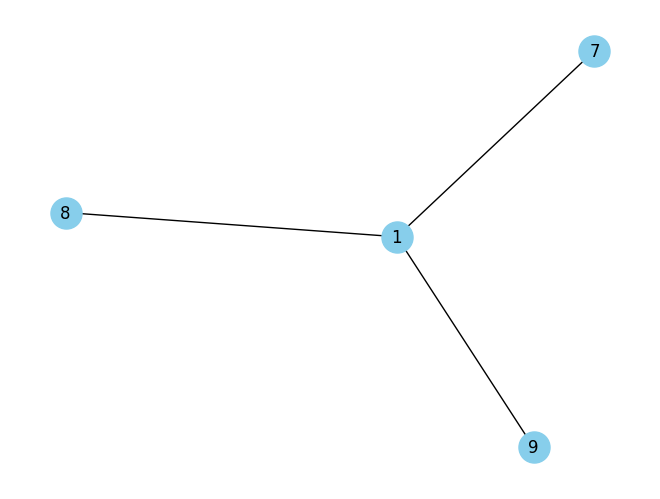

step 576: start a new part dag {}
step 581: Section 116 constructed!
[(5, 1), (1, 9), (8, 1), (1, 9)]


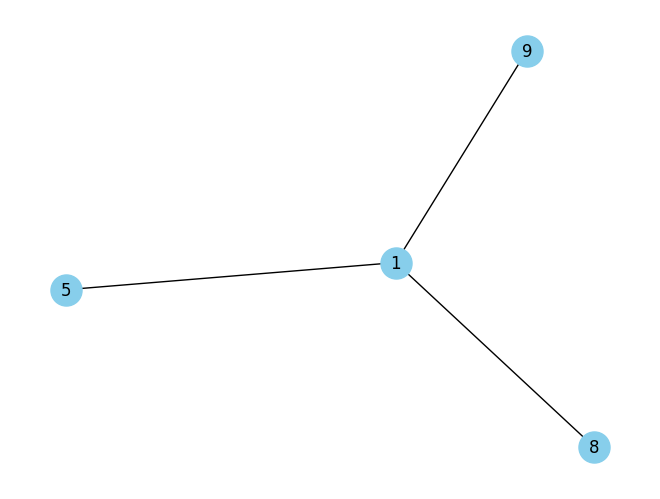

step 581: start a new part dag {}
step 586: Section 117 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


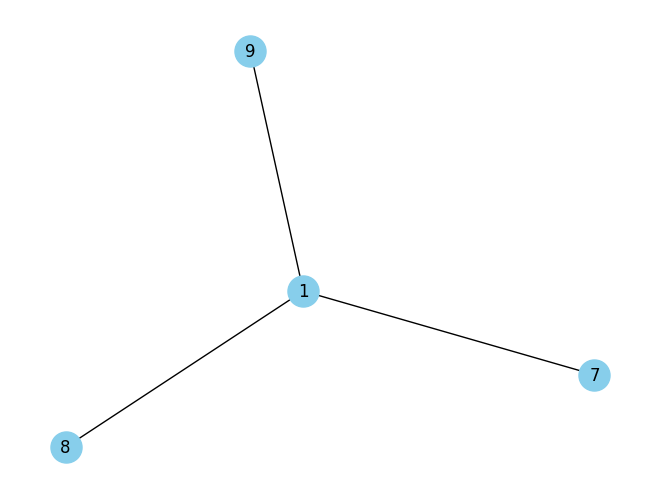

step 586: start a new part dag {}
step 591: Section 118 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


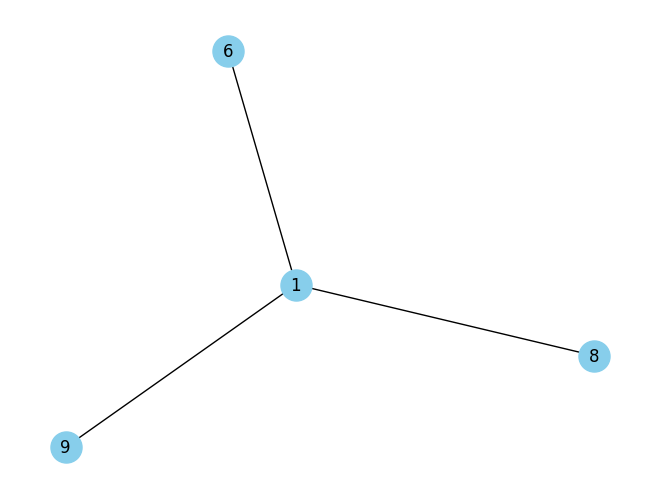

step 591: start a new part dag {}
step 596: Section 119 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


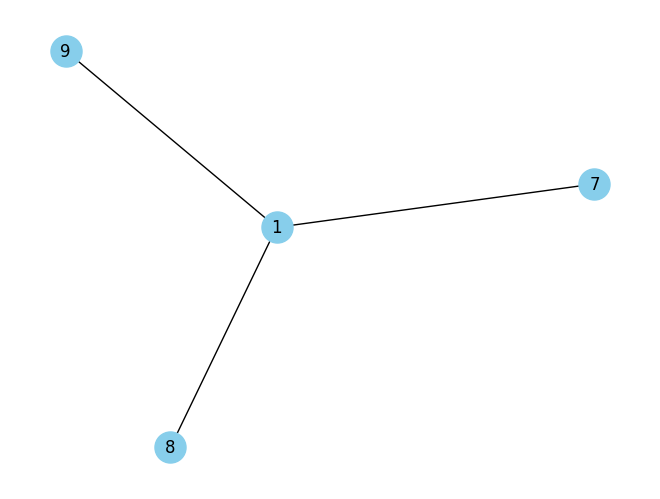

step 596: start a new part dag {}
step 601: Section 120 constructed!
[(4, 1), (1, 9), (8, 1), (1, 9)]


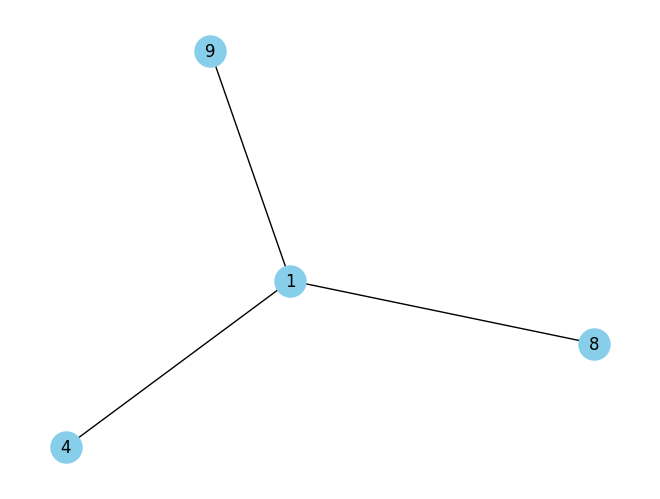

step 601: start a new part dag {}
step 606: Section 121 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


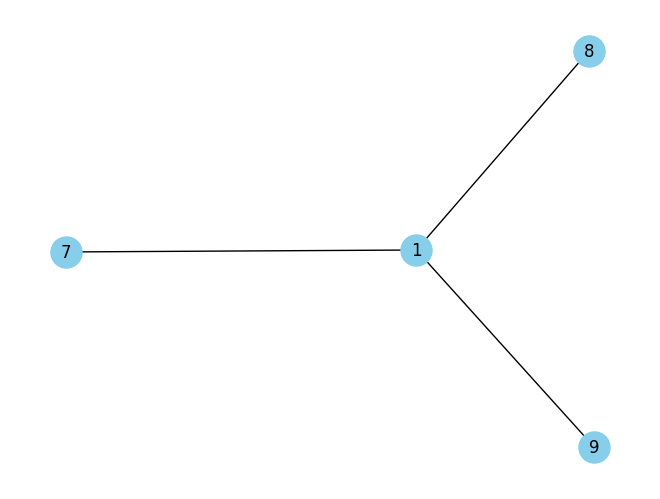

step 606: start a new part dag {}
step 611: Section 122 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


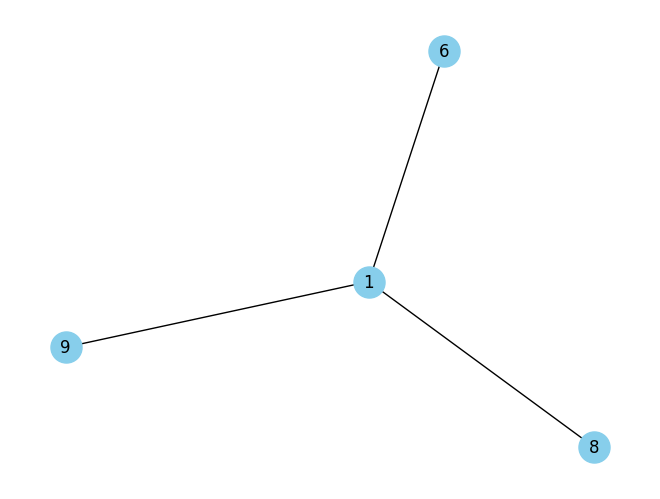

step 611: start a new part dag {}
step 616: Section 123 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


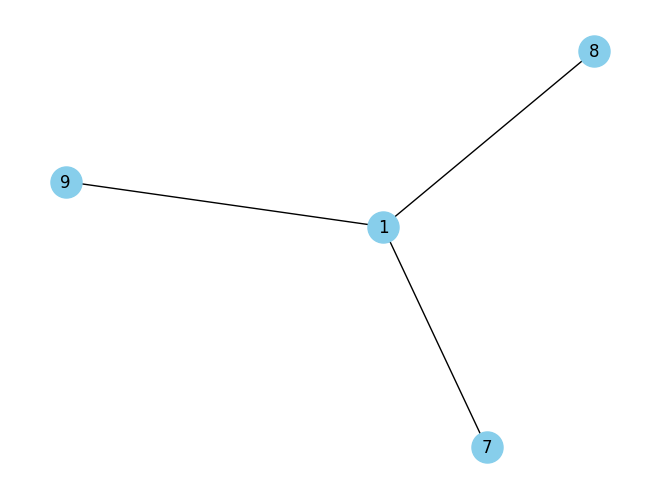

step 616: start a new part dag {}
step 621: Section 124 constructed!
[(5, 1), (1, 9), (8, 1), (1, 9)]


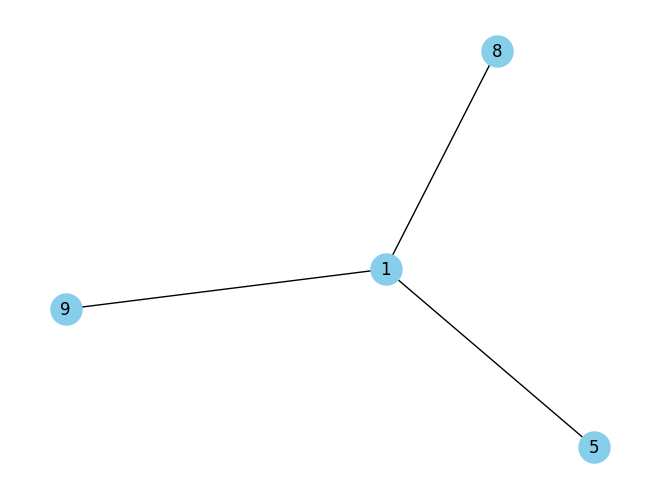

step 621: start a new part dag {}
step 626: Section 125 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


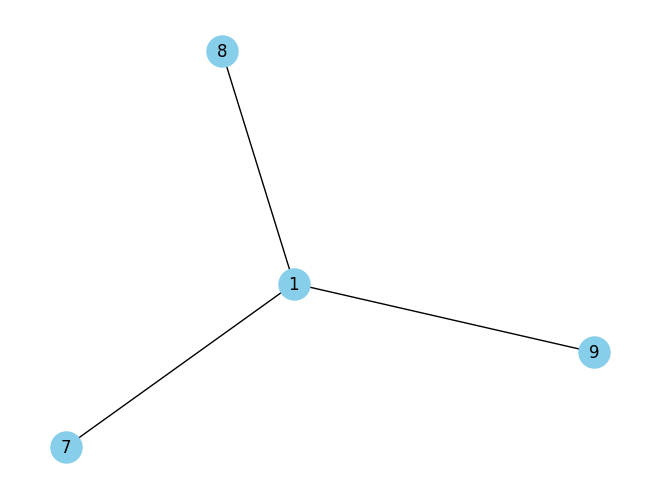

step 626: start a new part dag {}
step 631: Section 126 constructed!
[(6, 1), (1, 9), (8, 1), (1, 9)]


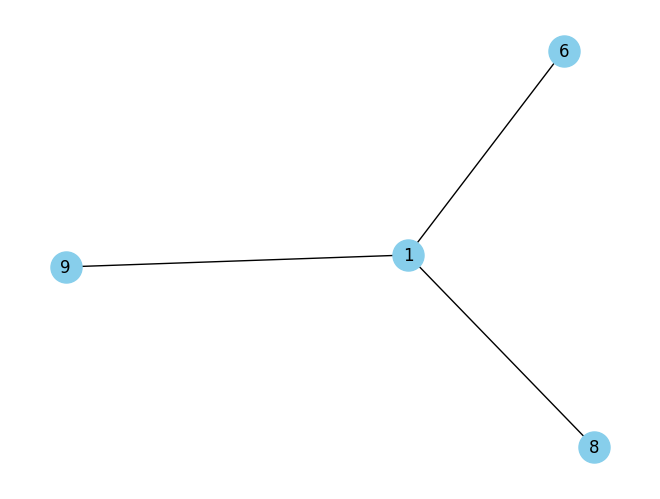

step 631: start a new part dag {}
step 636: Section 127 constructed!
[(7, 1), (1, 9), (8, 1), (1, 9)]


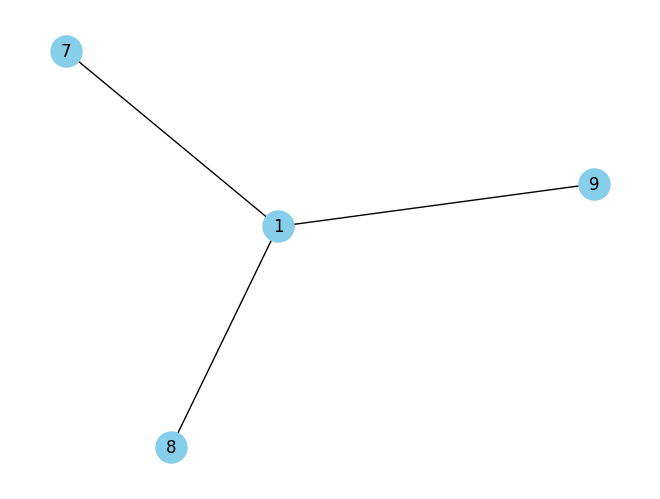

step 636: start a new part dag {}
step 641: Section 128 constructed!
[(1, 0), (0, 9), (8, 0), (0, 9)]


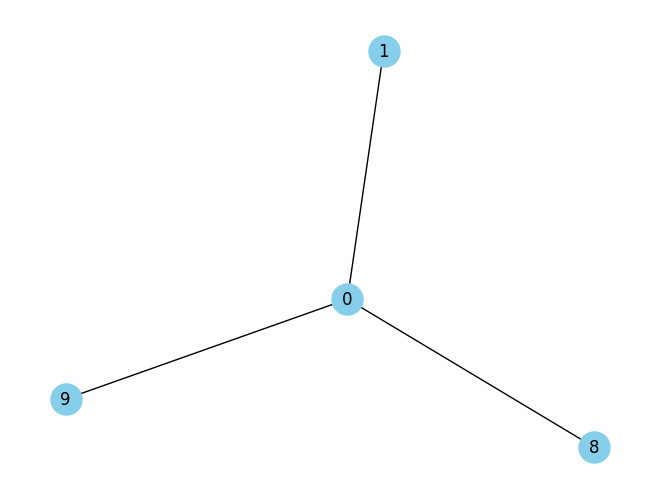

step 641: start a new part dag {}
step 646: Section 129 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


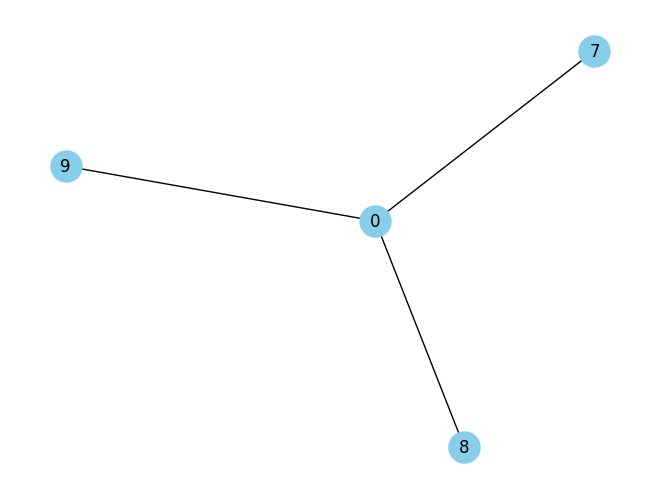

step 646: start a new part dag {}
step 651: Section 130 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


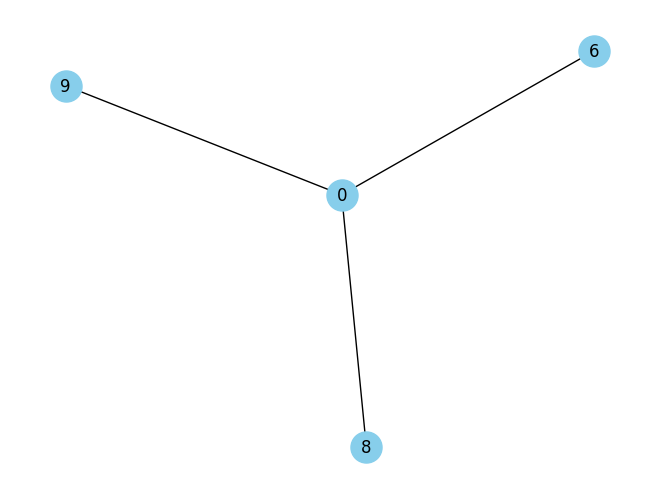

step 651: start a new part dag {}
step 656: Section 131 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


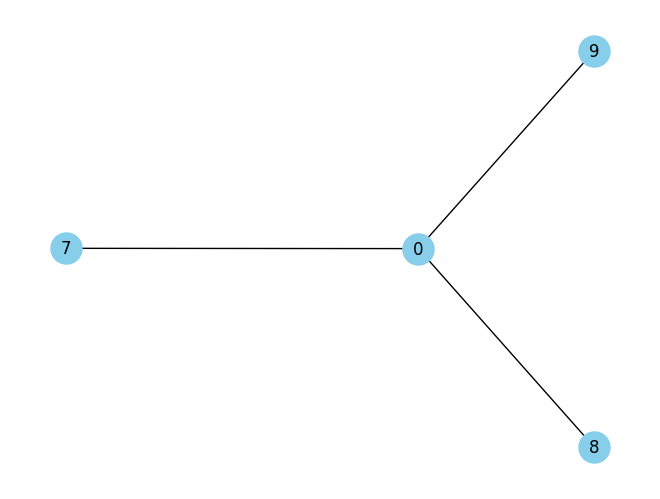

step 656: start a new part dag {}
step 661: Section 132 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


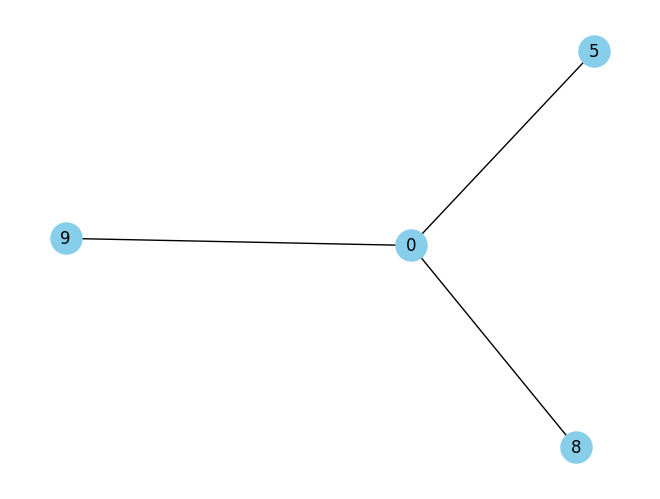

step 661: start a new part dag {}
step 666: Section 133 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


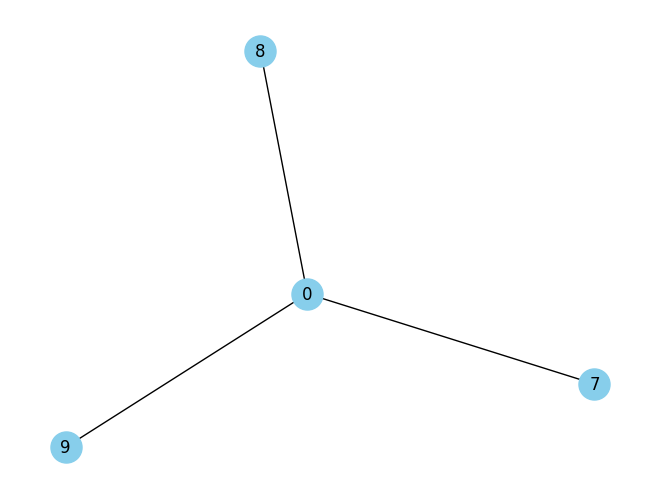

step 666: start a new part dag {}
step 671: Section 134 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


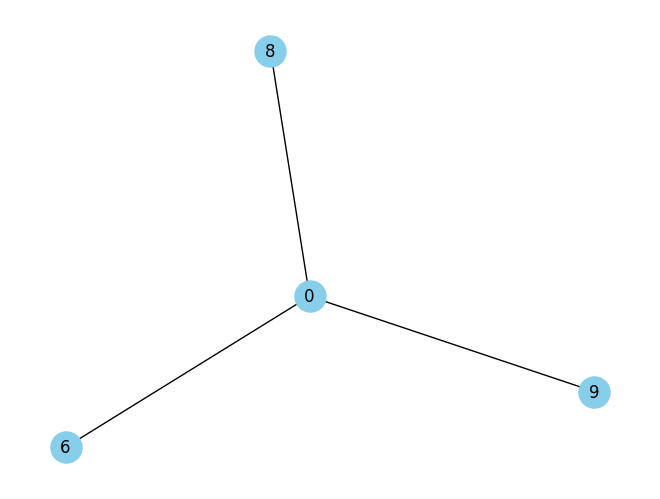

step 671: start a new part dag {}
step 676: Section 135 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


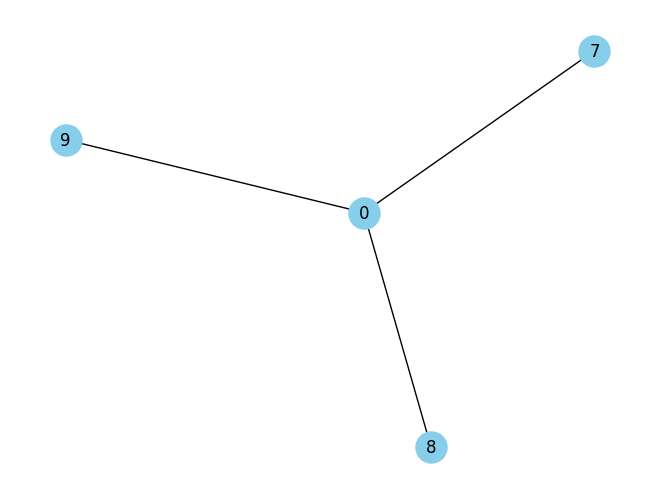

step 676: start a new part dag {}
step 681: Section 136 constructed!
[(4, 0), (0, 9), (8, 0), (0, 9)]


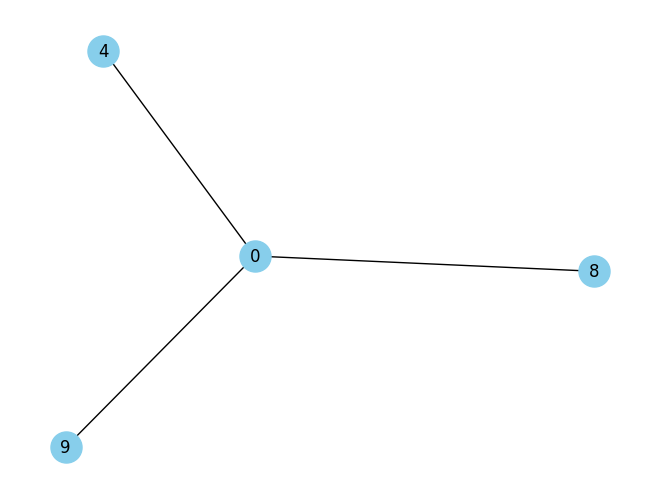

step 681: start a new part dag {}
step 686: Section 137 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


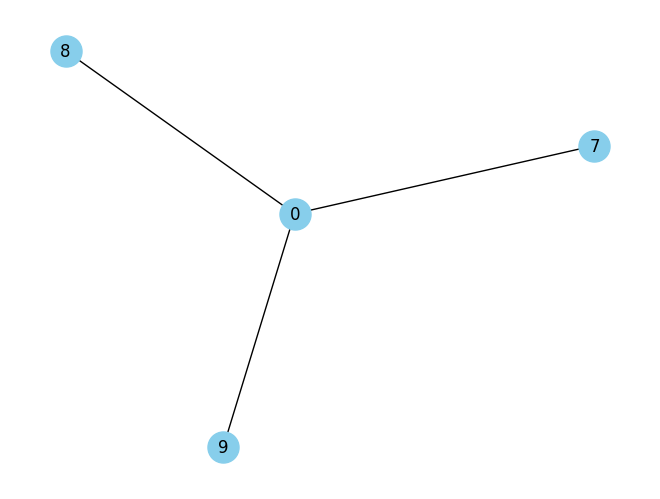

step 686: start a new part dag {}
step 691: Section 138 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


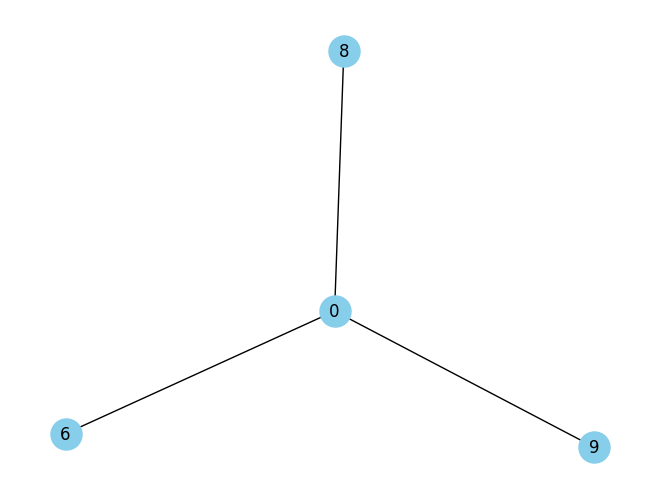

step 691: start a new part dag {}
step 696: Section 139 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


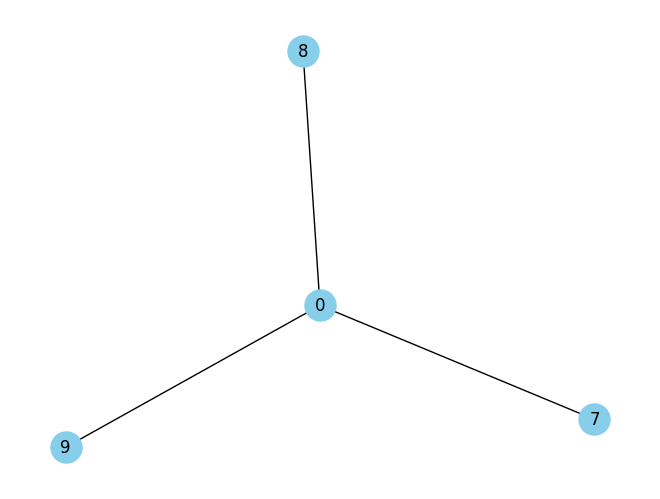

step 696: start a new part dag {}
step 701: Section 140 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


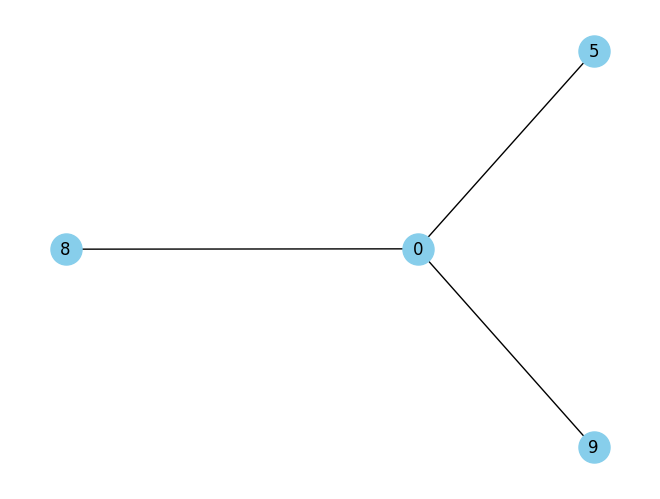

step 701: start a new part dag {}
step 706: Section 141 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


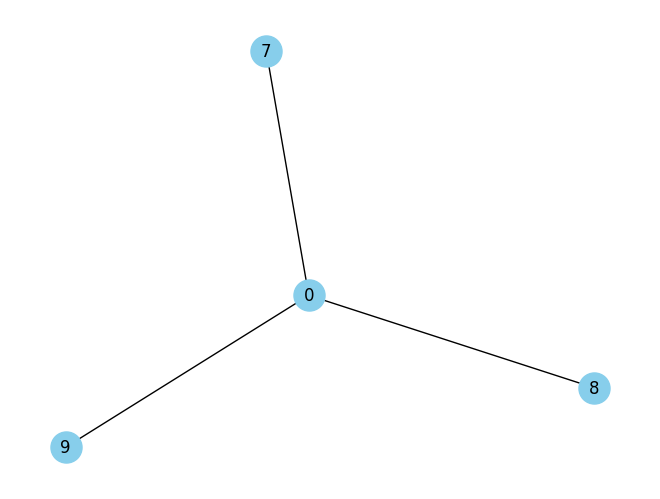

step 706: start a new part dag {}
step 711: Section 142 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


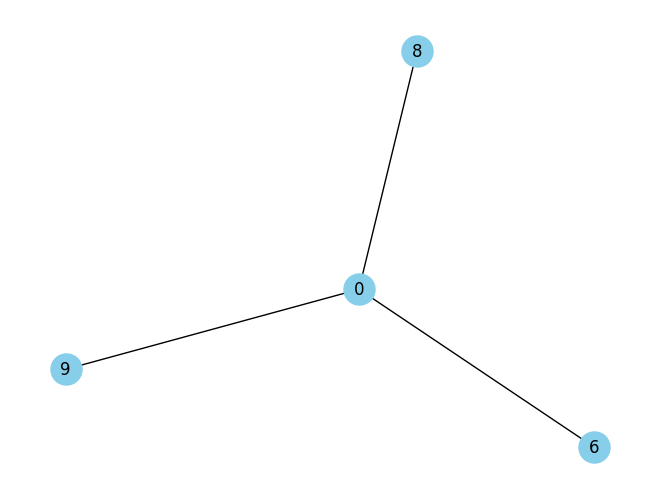

step 711: start a new part dag {}
step 716: Section 143 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


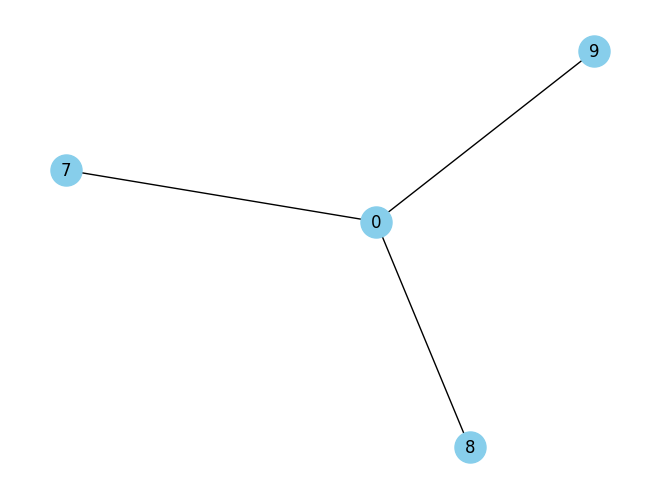

step 716: start a new part dag {}
step 721: Section 144 constructed!
[(3, 0), (0, 9), (8, 0), (0, 9)]


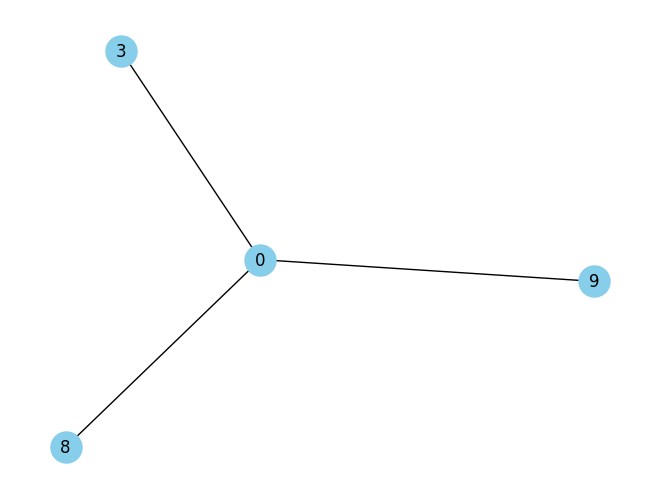

step 721: start a new part dag {}
step 726: Section 145 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


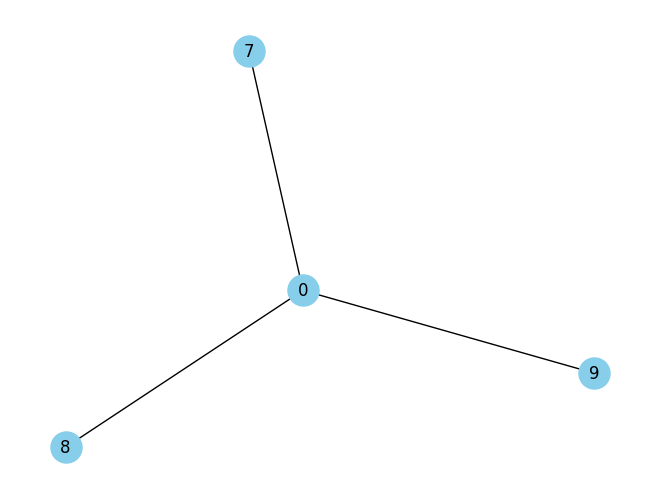

step 726: start a new part dag {}
step 731: Section 146 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


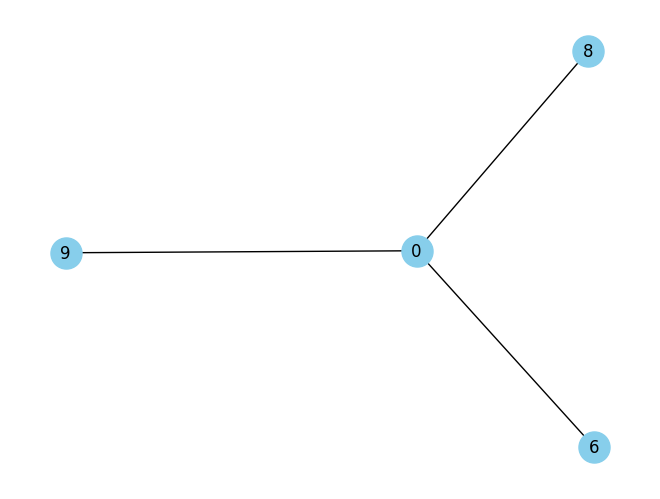

step 731: start a new part dag {}
step 736: Section 147 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


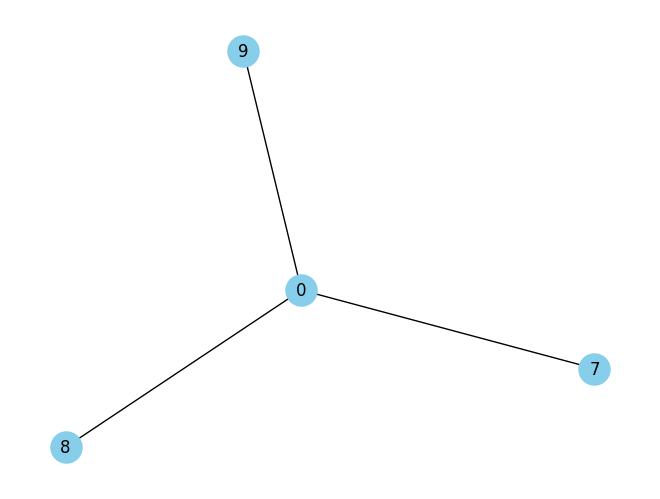

step 736: start a new part dag {}
step 741: Section 148 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


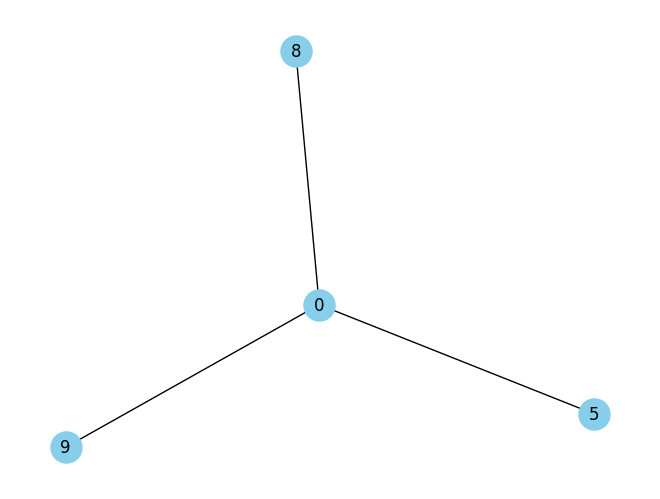

step 741: start a new part dag {}
step 746: Section 149 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


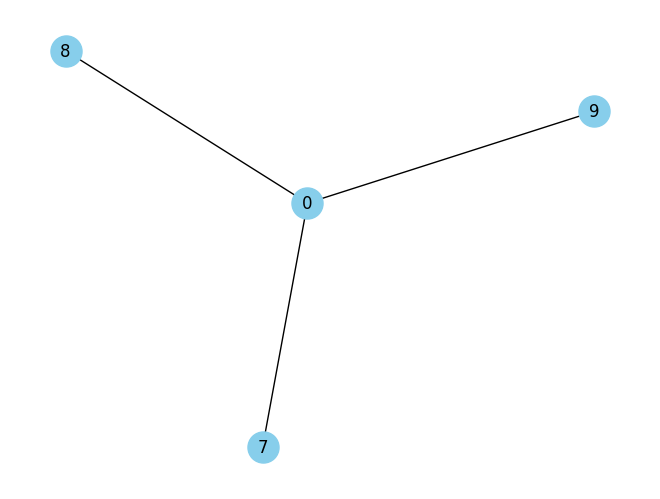

step 746: start a new part dag {}
step 751: Section 150 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


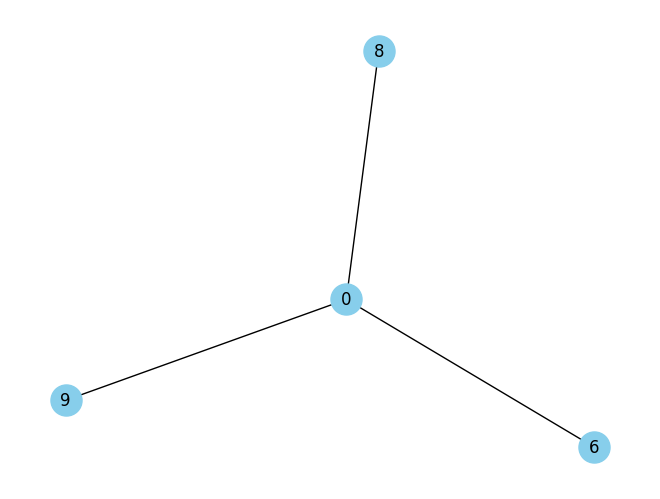

step 751: start a new part dag {}
step 756: Section 151 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


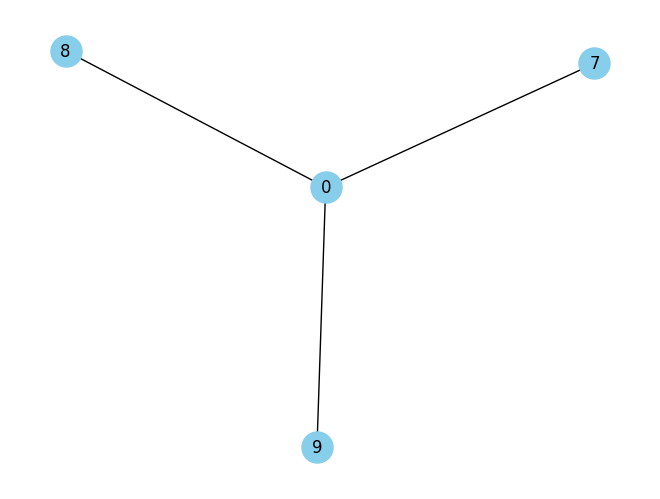

step 756: start a new part dag {}
step 761: Section 152 constructed!
[(4, 0), (0, 9), (8, 0), (0, 9)]


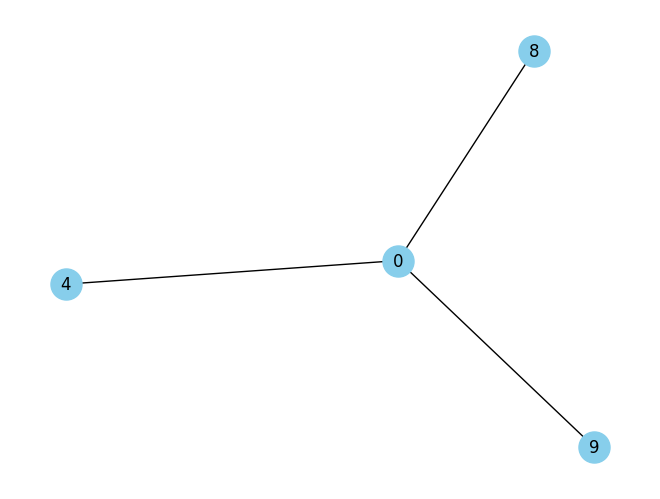

step 761: start a new part dag {}
step 766: Section 153 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


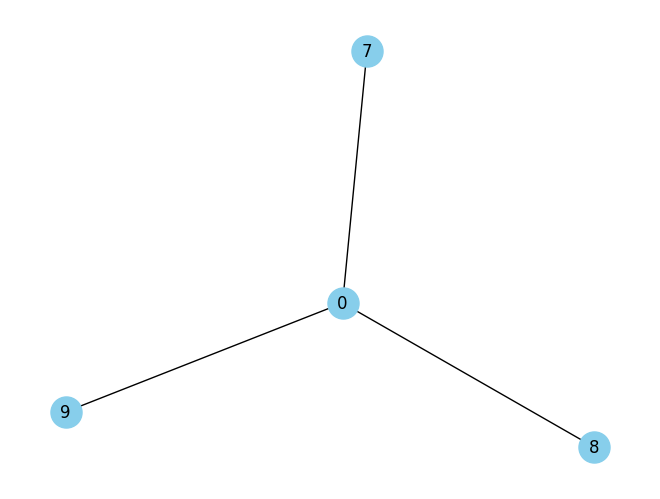

step 766: start a new part dag {}
step 771: Section 154 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


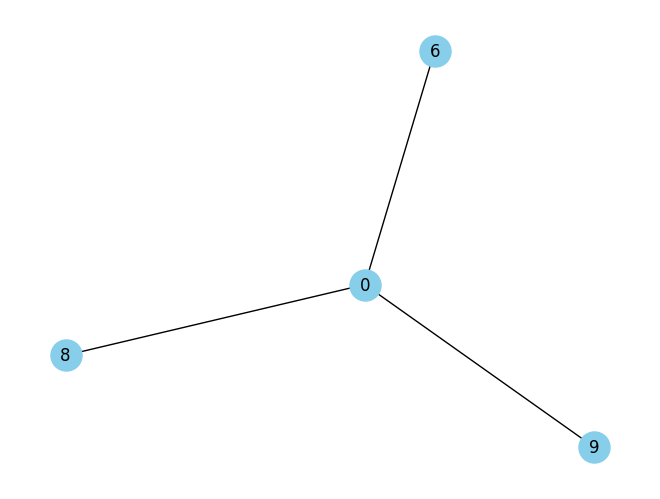

step 771: start a new part dag {}
step 776: Section 155 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


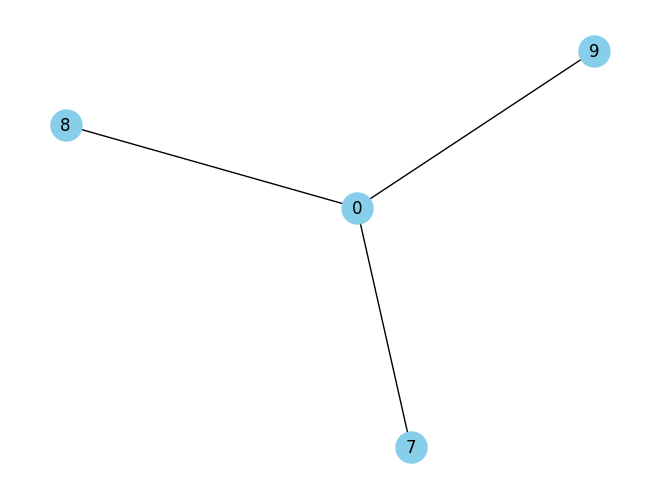

step 776: start a new part dag {}
step 781: Section 156 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


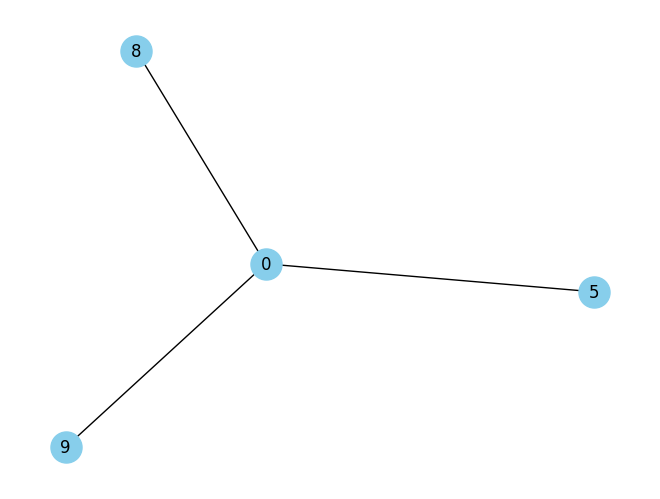

step 781: start a new part dag {}
step 786: Section 157 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


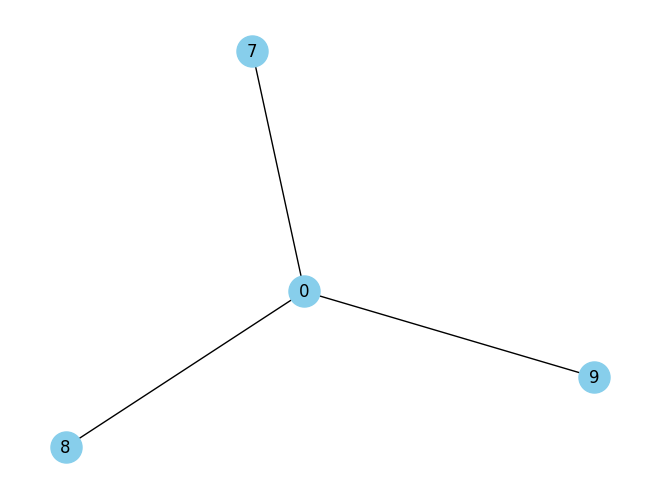

step 786: start a new part dag {}
step 791: Section 158 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


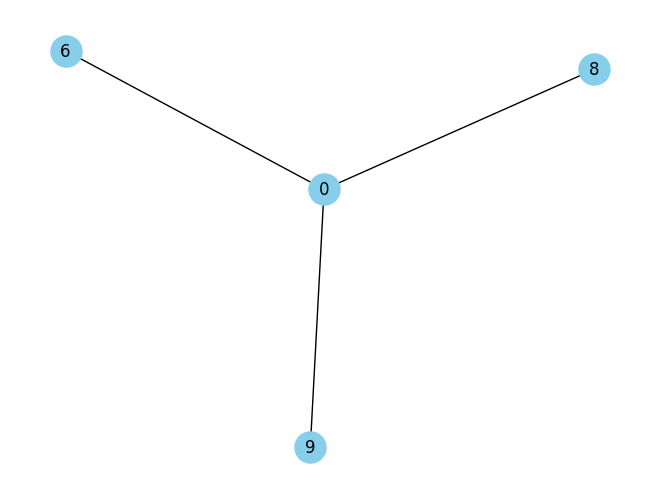

step 791: start a new part dag {}
step 796: Section 159 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


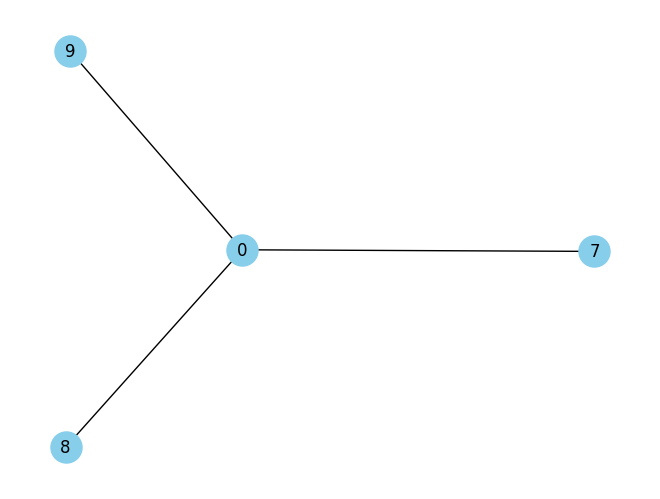

step 796: start a new part dag {}
step 801: Section 160 constructed!
[(2, 0), (0, 9), (8, 0), (0, 9)]


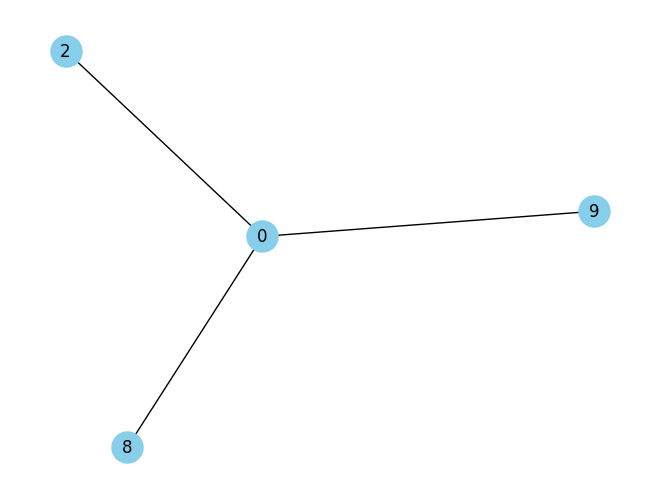

step 801: start a new part dag {}
step 806: Section 161 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


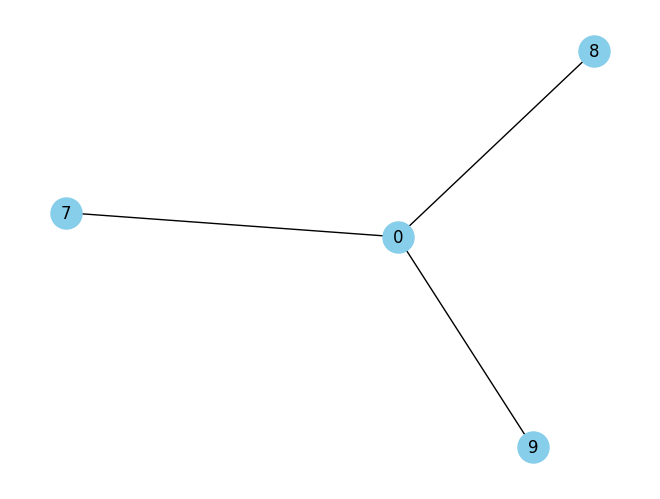

step 806: start a new part dag {}
step 811: Section 162 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


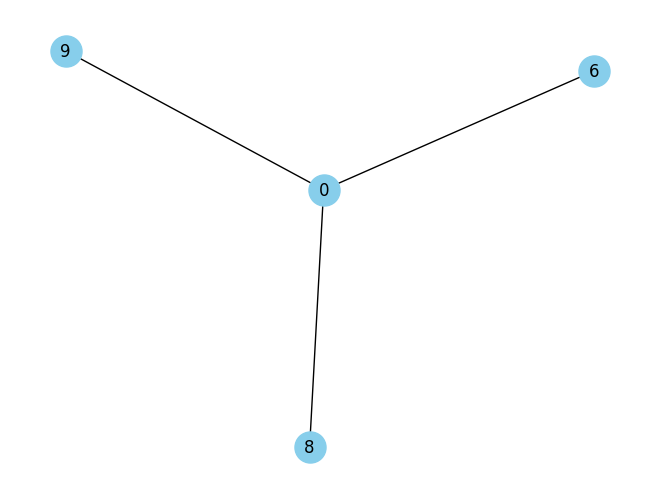

step 811: start a new part dag {}
step 816: Section 163 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


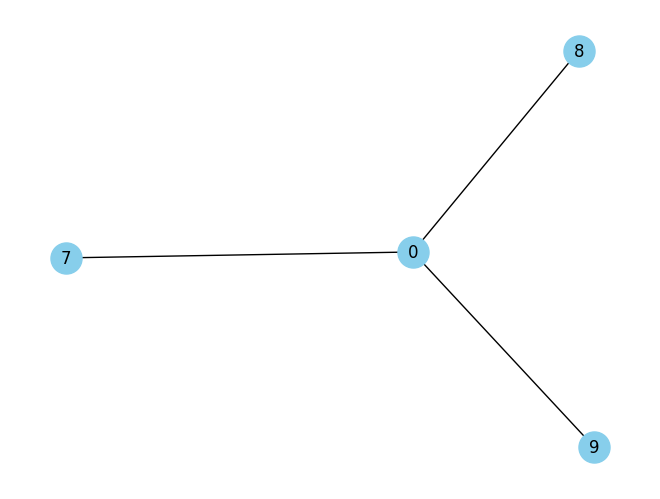

step 816: start a new part dag {}
step 821: Section 164 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


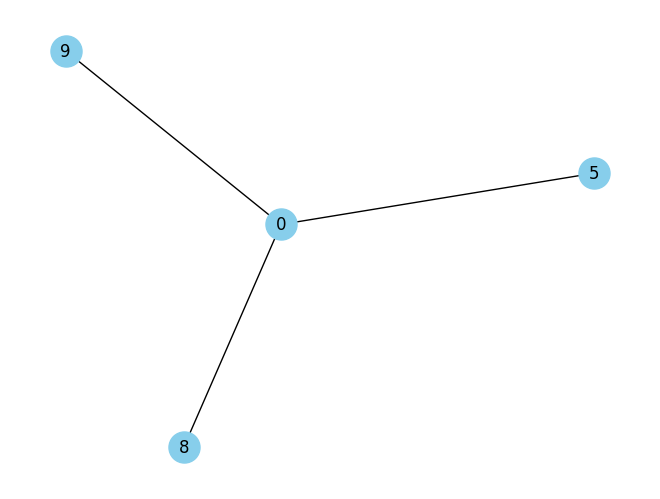

step 821: start a new part dag {}
step 826: Section 165 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


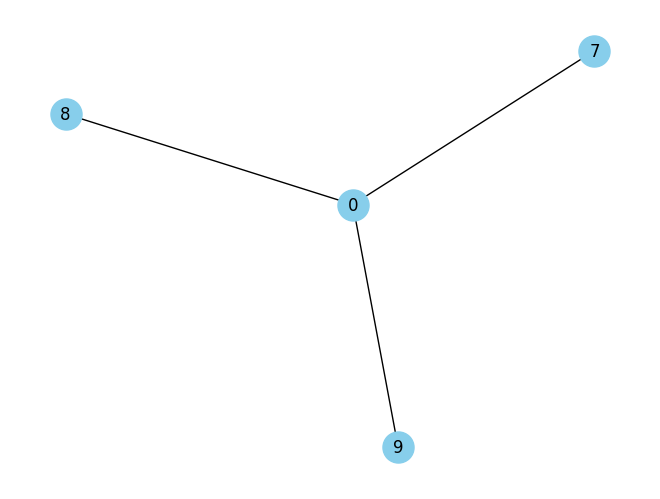

step 826: start a new part dag {}
step 831: Section 166 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


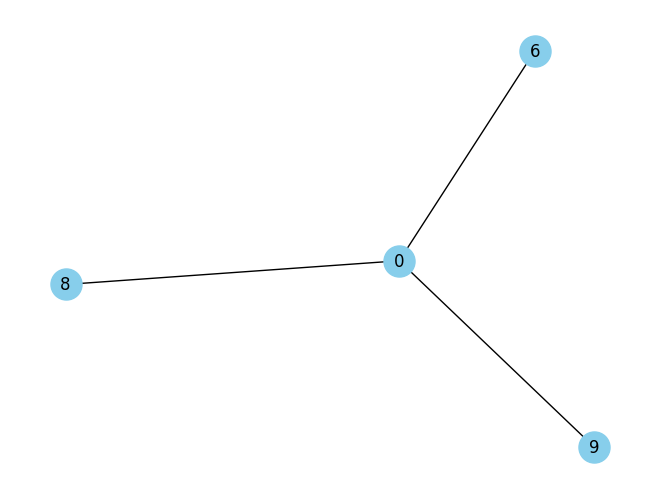

step 831: start a new part dag {}
step 836: Section 167 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


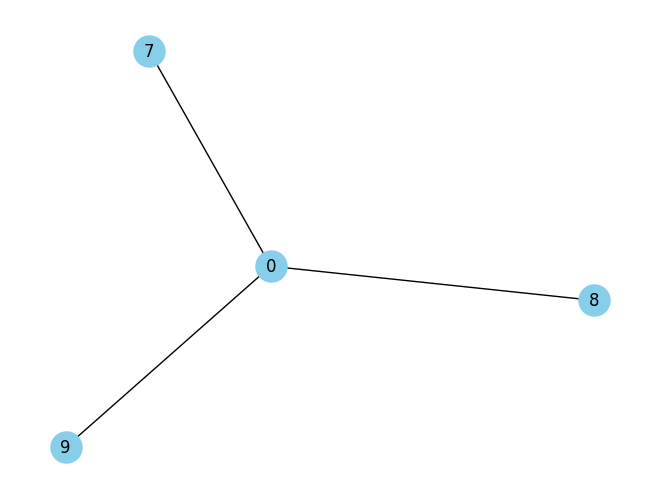

step 836: start a new part dag {}
step 841: Section 168 constructed!
[(4, 0), (0, 9), (8, 0), (0, 9)]


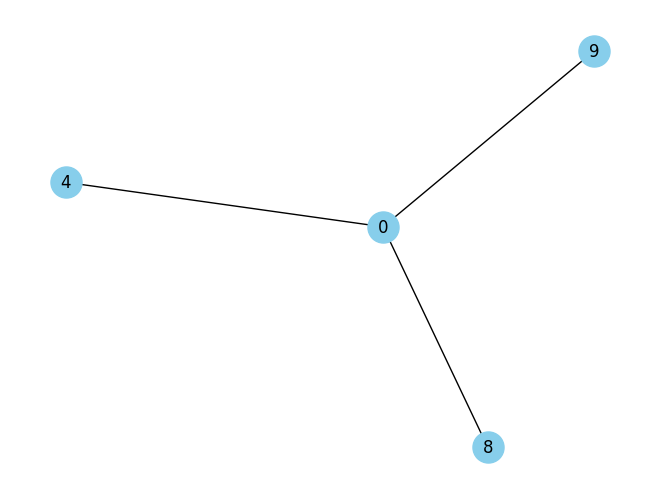

step 841: start a new part dag {}
step 846: Section 169 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


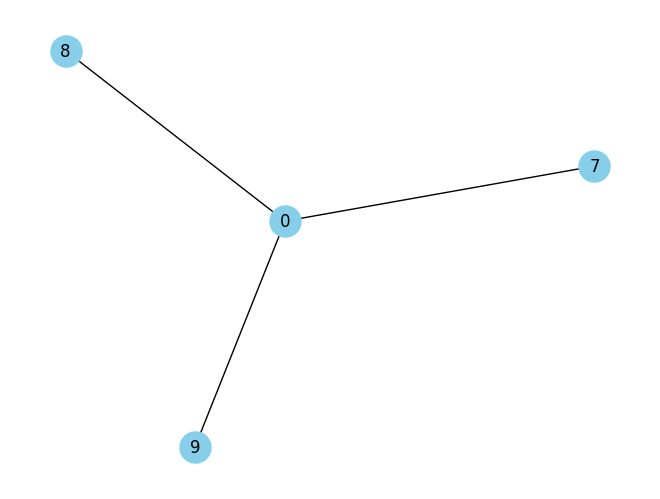

step 846: start a new part dag {}
step 851: Section 170 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


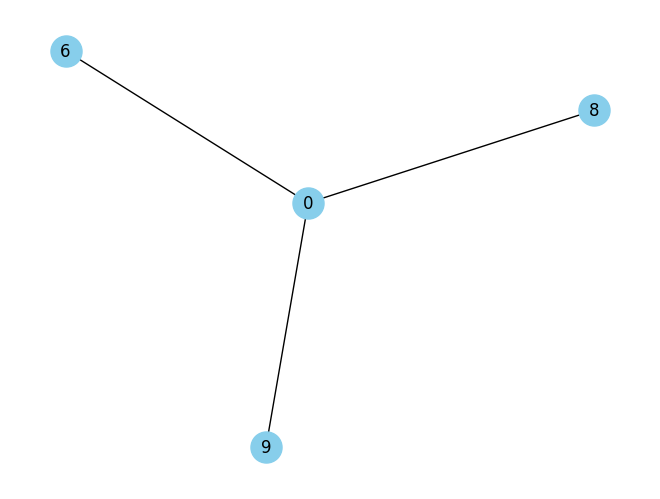

step 851: start a new part dag {}
step 856: Section 171 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


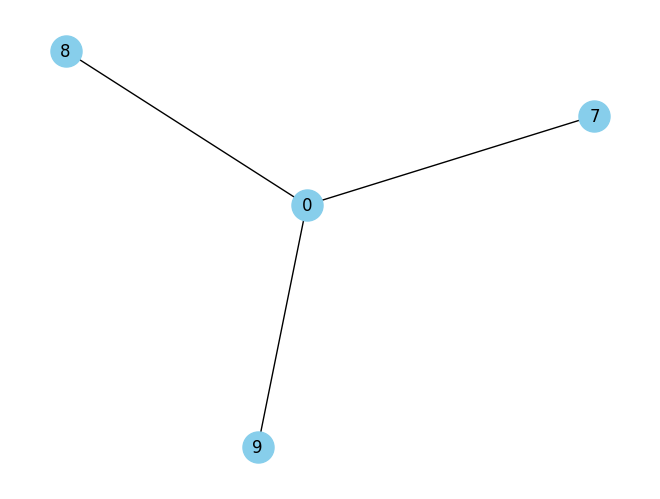

step 856: start a new part dag {}
step 861: Section 172 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


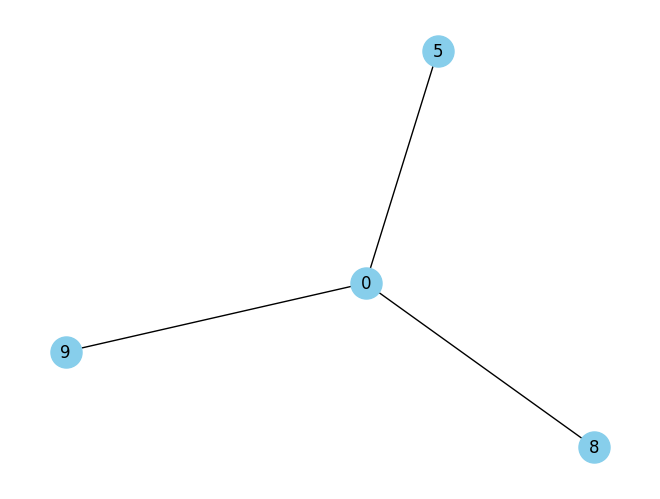

step 861: start a new part dag {}
step 866: Section 173 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


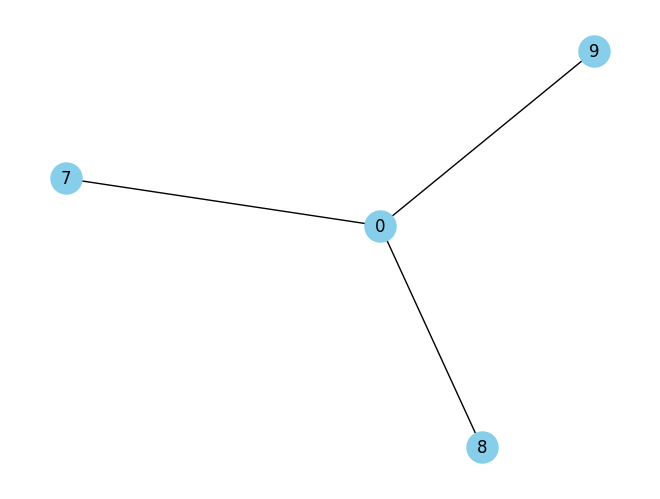

step 866: start a new part dag {}
step 871: Section 174 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


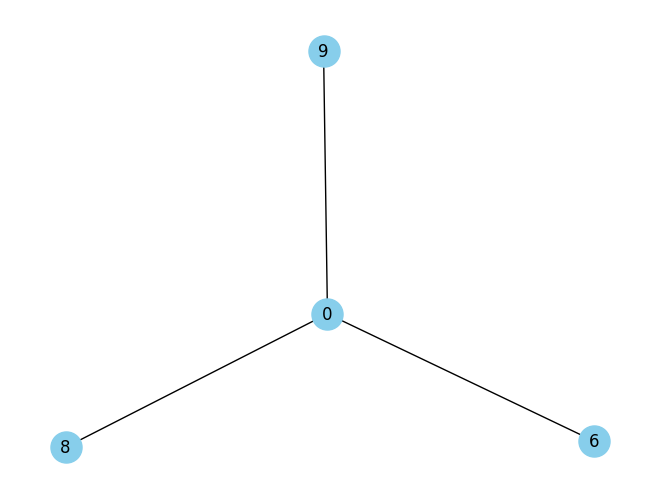

step 871: start a new part dag {}
step 876: Section 175 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


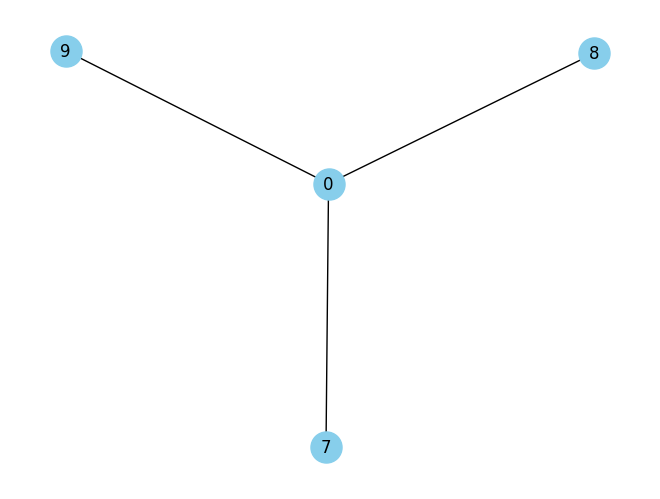

step 876: start a new part dag {}
step 881: Section 176 constructed!
[(3, 0), (0, 9), (8, 0), (0, 9)]


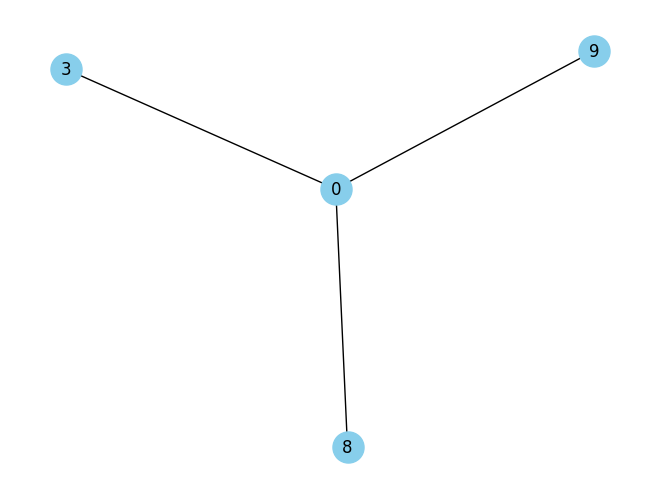

step 881: start a new part dag {}
step 886: Section 177 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


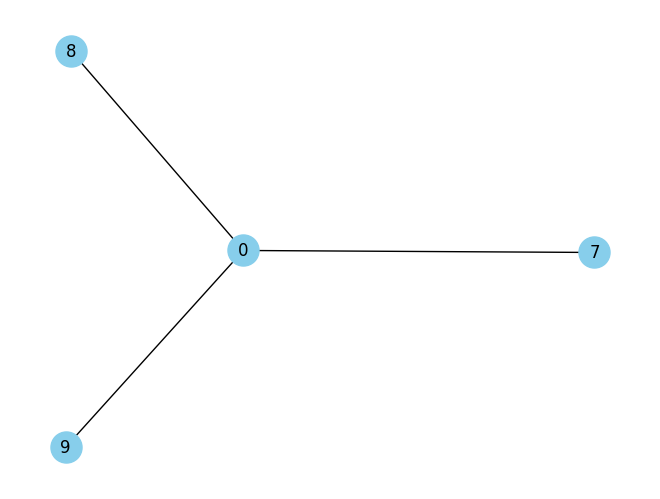

step 886: start a new part dag {}
step 891: Section 178 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


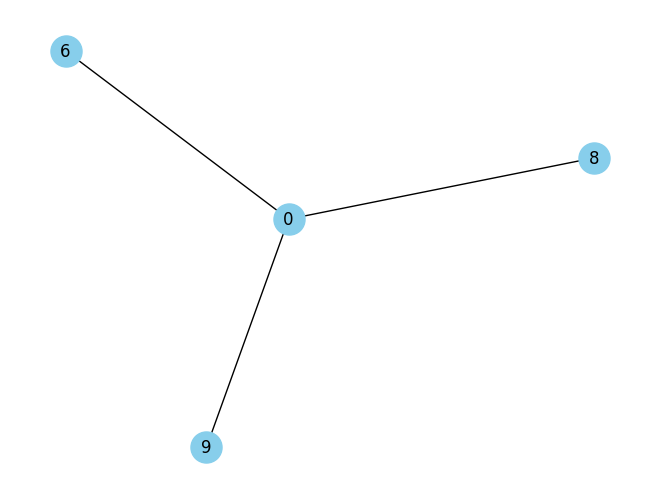

step 891: start a new part dag {}
step 896: Section 179 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


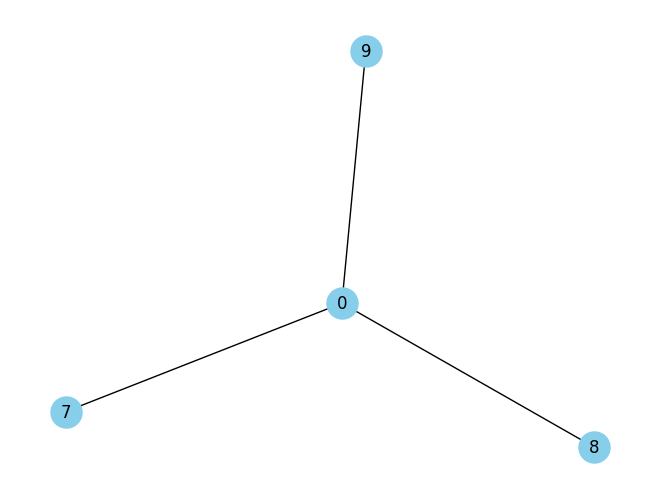

step 896: start a new part dag {}
step 901: Section 180 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


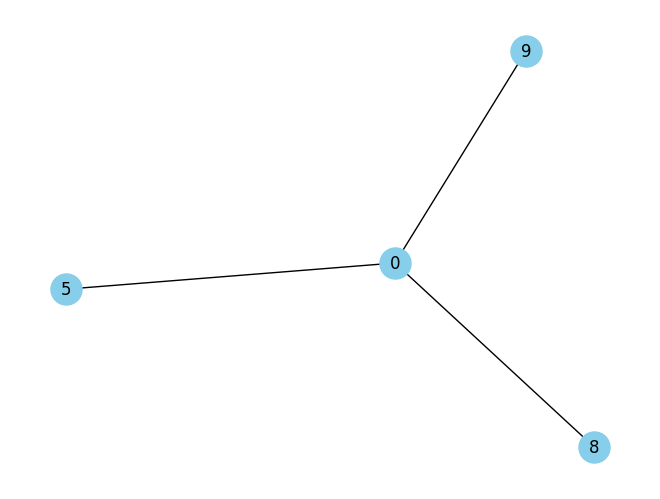

step 901: start a new part dag {}
step 906: Section 181 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


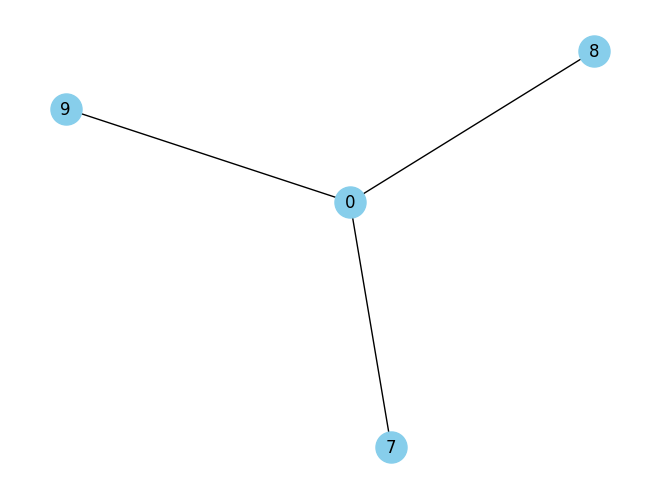

step 906: start a new part dag {}
step 911: Section 182 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


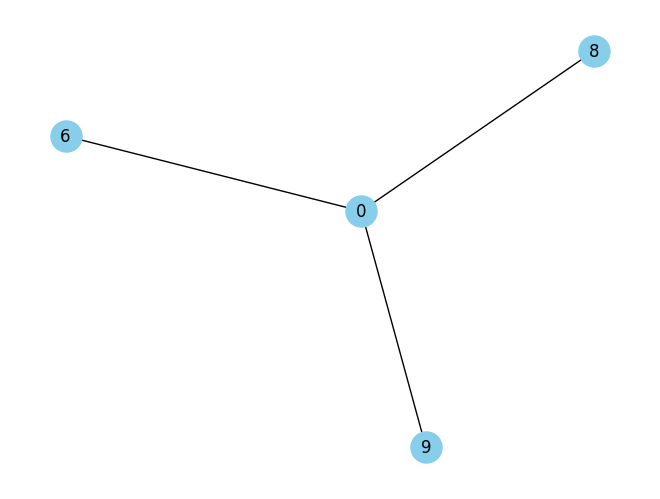

step 911: start a new part dag {}
step 916: Section 183 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


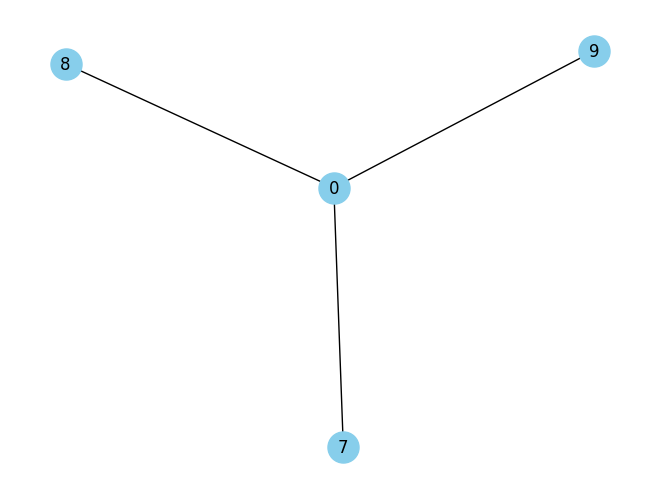

step 916: start a new part dag {}
step 921: Section 184 constructed!
[(4, 0), (0, 9), (8, 0), (0, 9)]


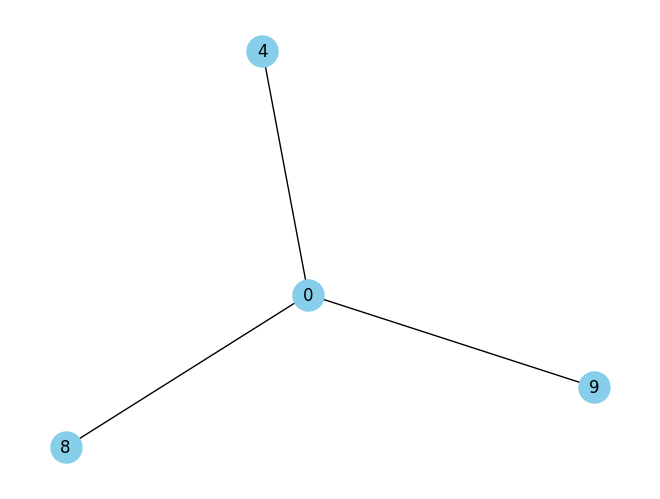

step 921: start a new part dag {}
step 926: Section 185 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


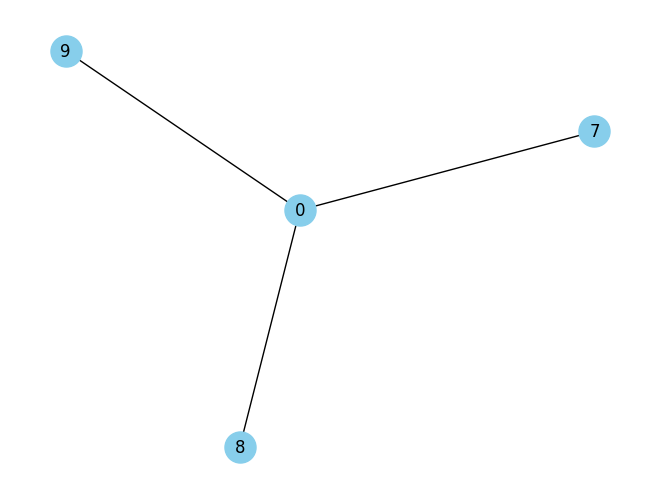

step 926: start a new part dag {}
step 931: Section 186 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


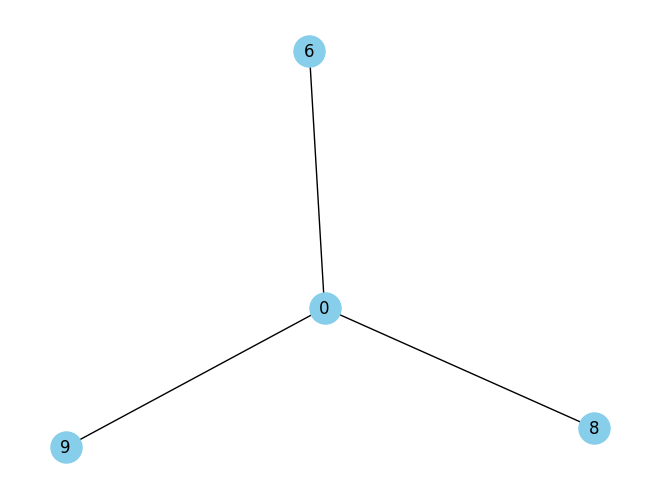

step 931: start a new part dag {}
step 936: Section 187 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


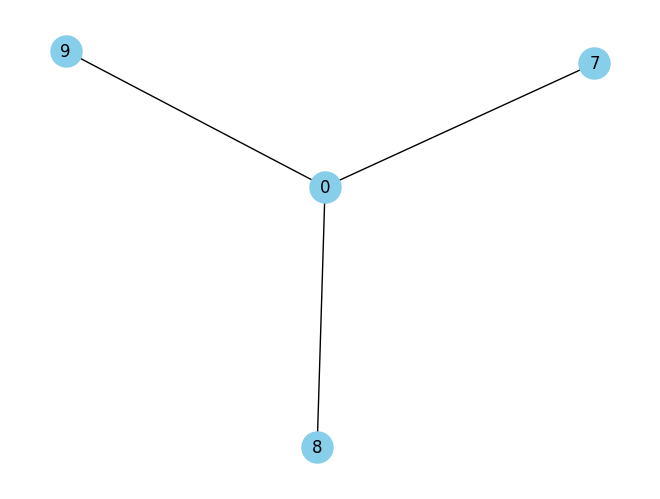

step 936: start a new part dag {}
step 941: Section 188 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


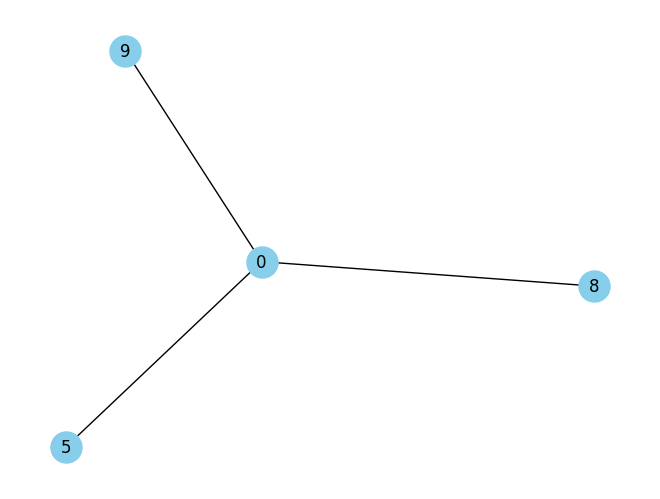

step 941: start a new part dag {}
step 946: Section 189 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


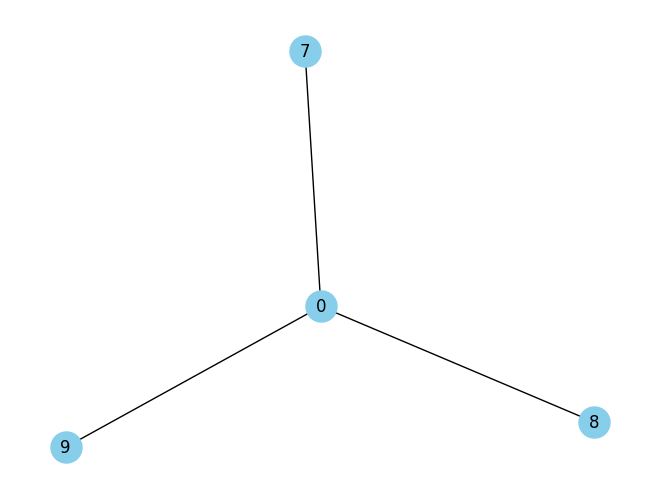

step 946: start a new part dag {}
step 951: Section 190 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


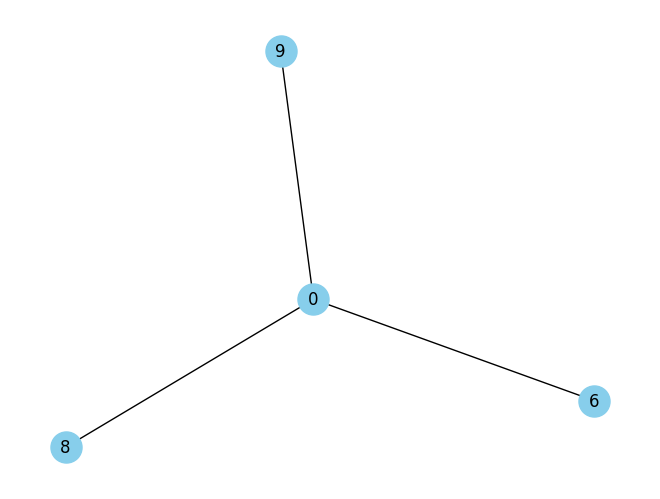

step 951: start a new part dag {}
step 956: Section 191 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


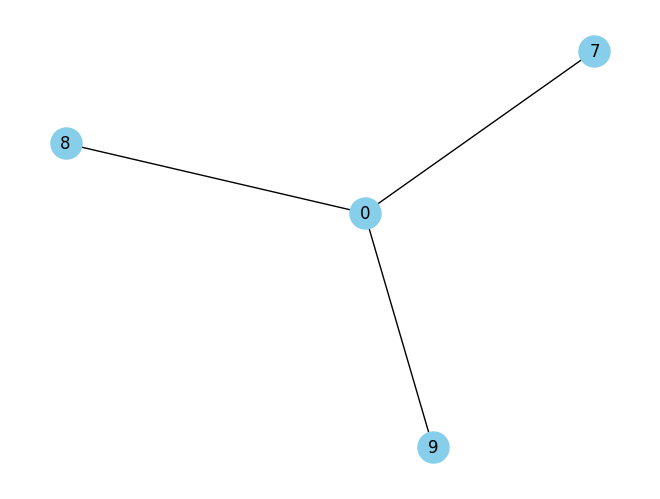

step 956: start a new part dag {}
step 961: Section 192 constructed!
[(1, 0), (0, 9), (8, 0), (0, 9)]


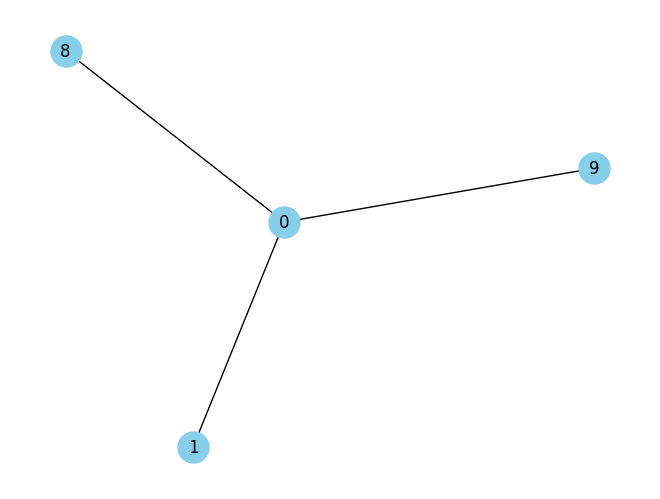

step 961: start a new part dag {}
step 966: Section 193 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


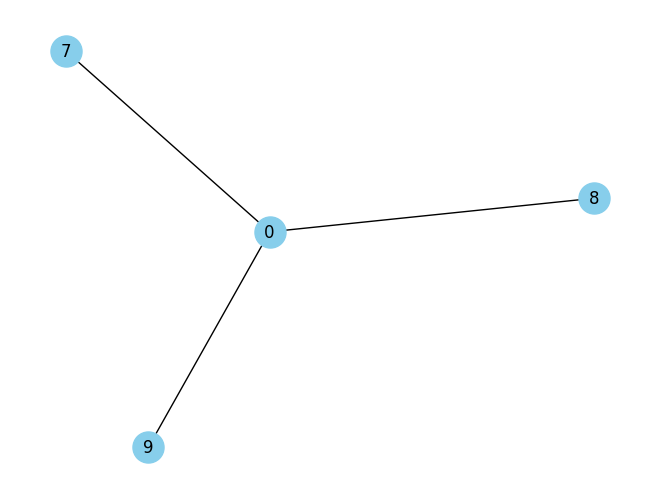

step 966: start a new part dag {}
step 971: Section 194 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


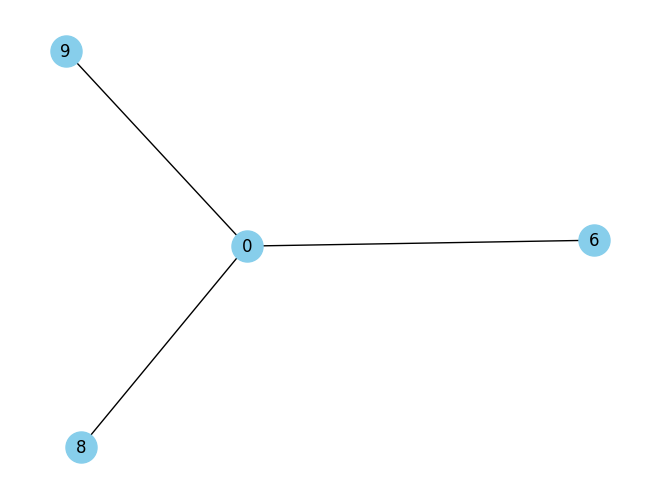

step 971: start a new part dag {}
step 976: Section 195 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


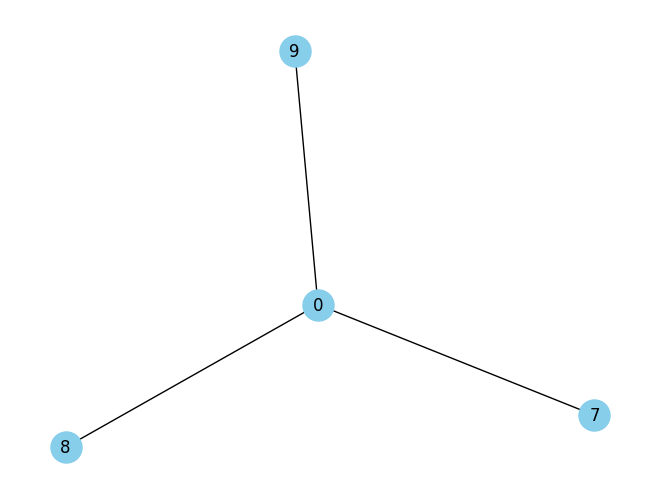

step 976: start a new part dag {}
step 981: Section 196 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


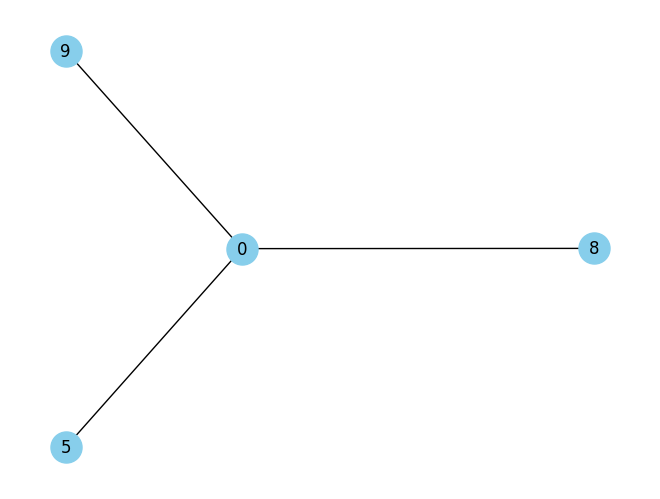

step 981: start a new part dag {}
step 986: Section 197 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


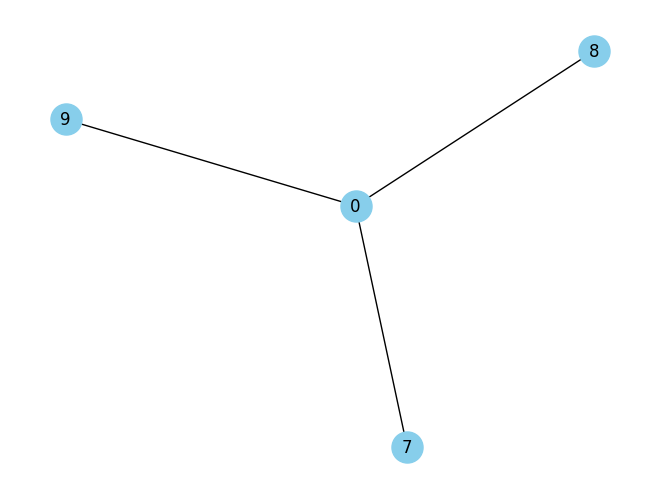

step 986: start a new part dag {}
step 991: Section 198 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


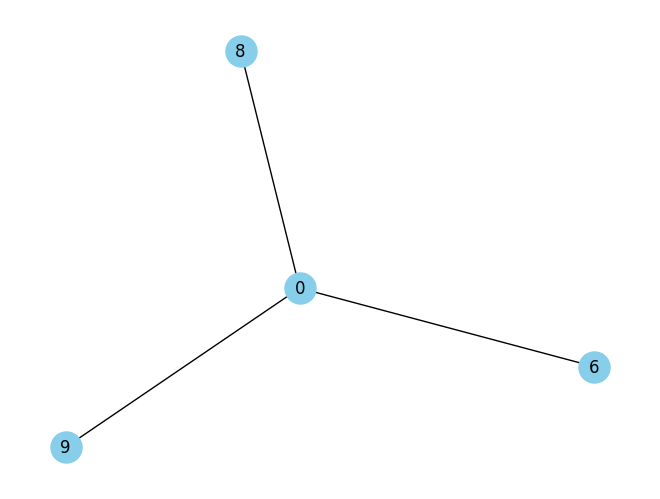

step 991: start a new part dag {}
step 996: Section 199 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


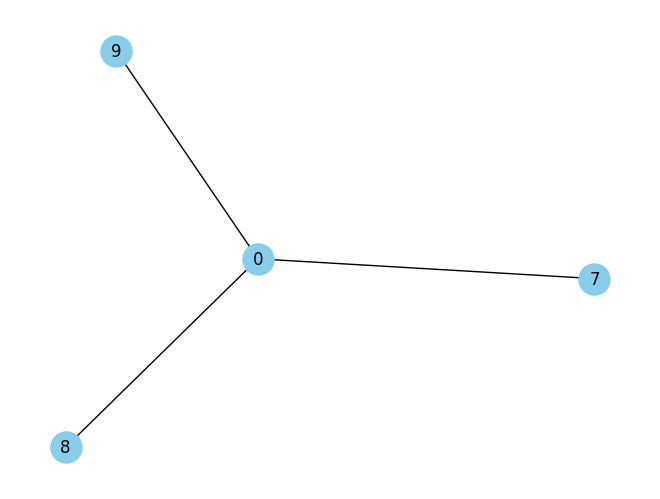

step 996: start a new part dag {}
step 1001: Section 200 constructed!
[(4, 0), (0, 9), (8, 0), (0, 9)]


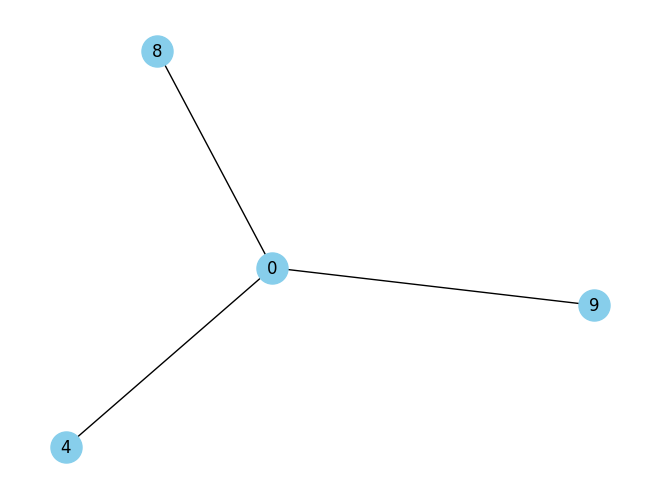

step 1001: start a new part dag {}
step 1006: Section 201 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


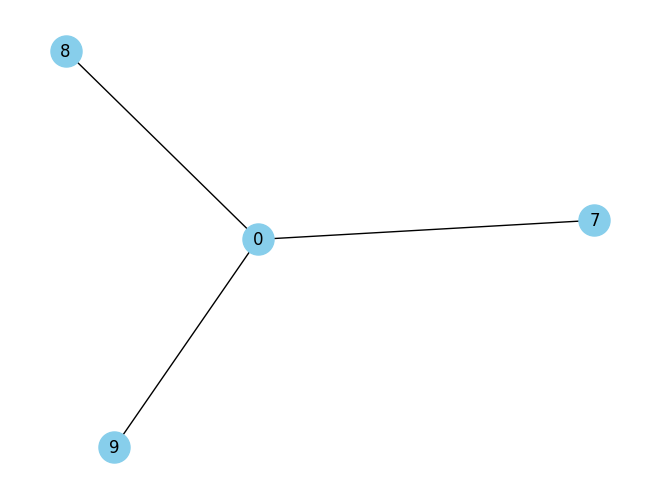

step 1006: start a new part dag {}
step 1011: Section 202 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


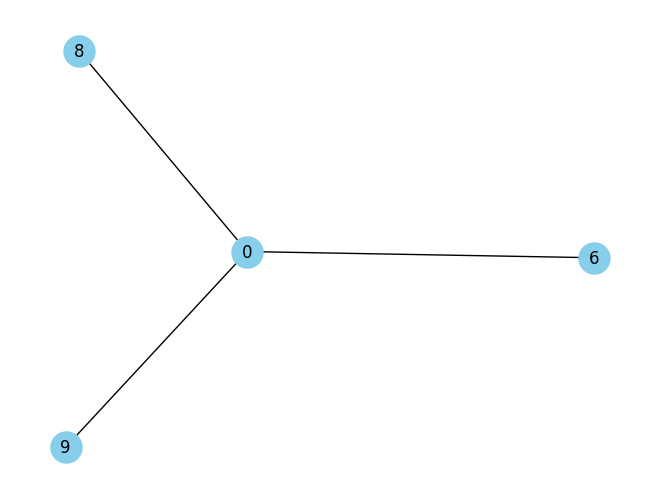

step 1011: start a new part dag {}
step 1016: Section 203 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


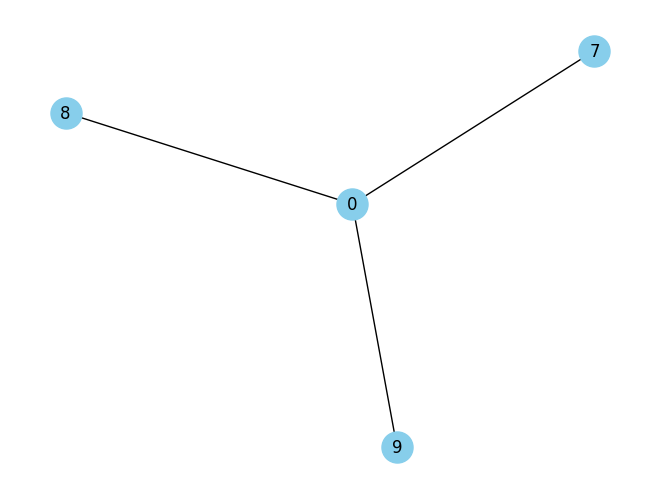

step 1016: start a new part dag {}
step 1021: Section 204 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


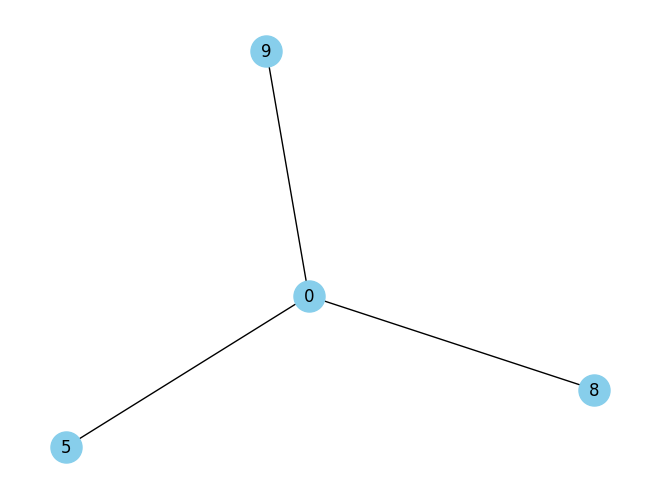

step 1021: start a new part dag {}
step 1026: Section 205 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


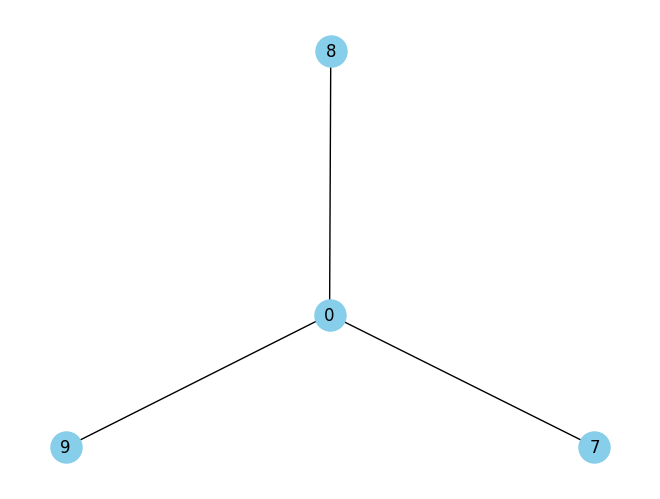

step 1026: start a new part dag {}
step 1031: Section 206 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


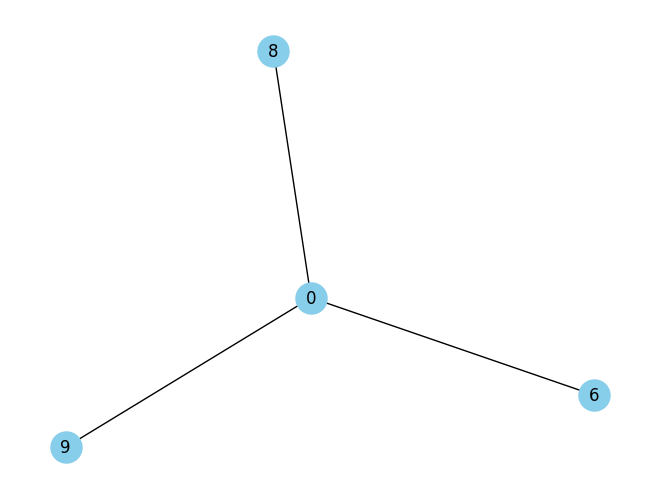

step 1031: start a new part dag {}
step 1036: Section 207 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


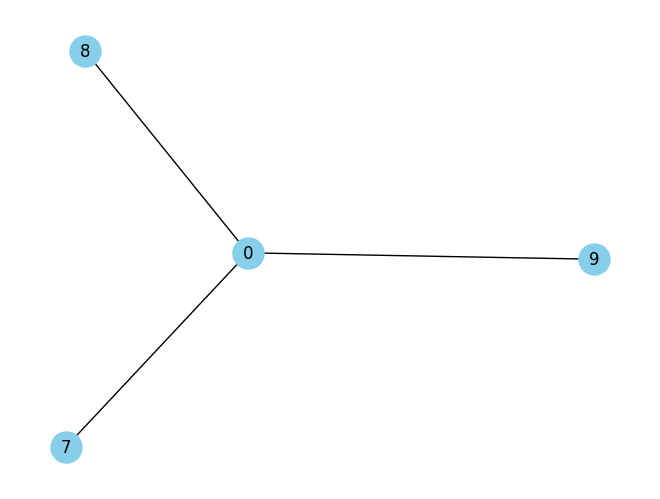

step 1036: start a new part dag {}
step 1041: Section 208 constructed!
[(3, 0), (0, 9), (8, 0), (0, 9)]


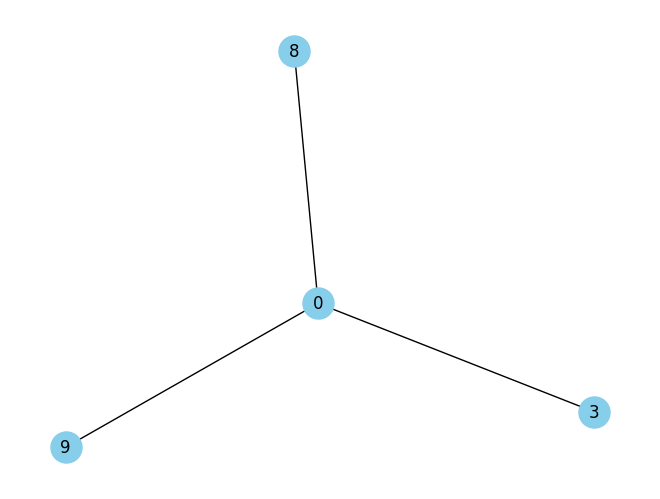

step 1041: start a new part dag {}
step 1046: Section 209 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


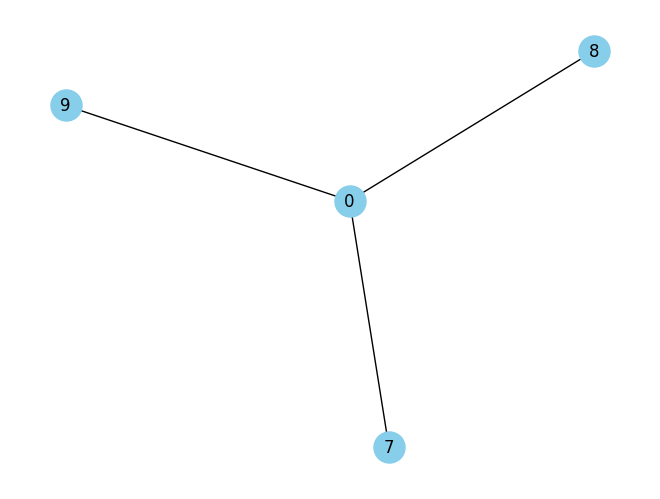

step 1046: start a new part dag {}
step 1051: Section 210 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


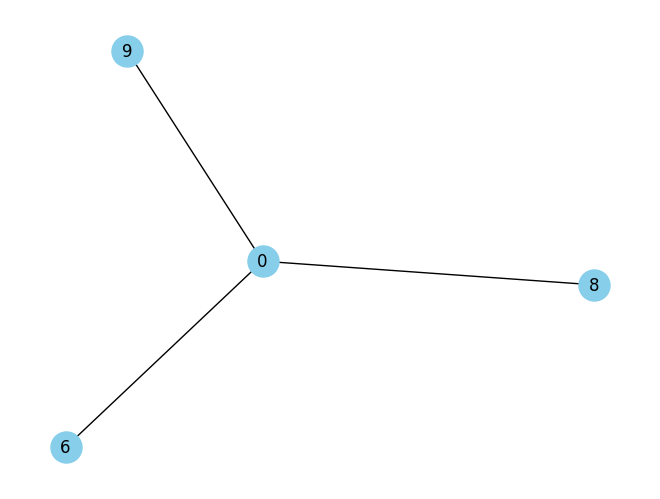

step 1051: start a new part dag {}
step 1056: Section 211 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


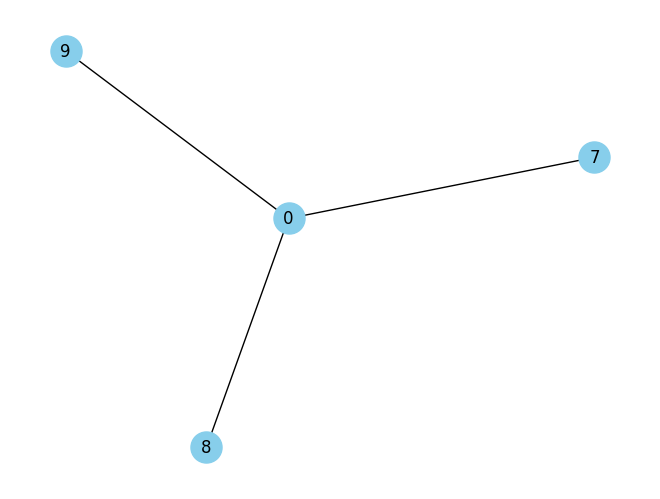

step 1056: start a new part dag {}
step 1061: Section 212 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


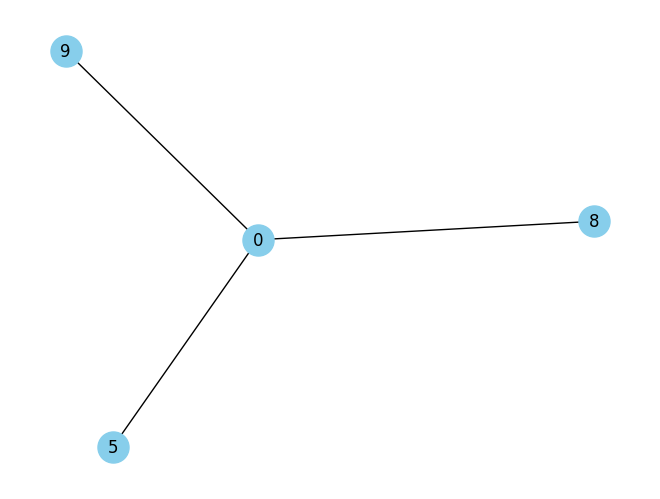

step 1061: start a new part dag {}
step 1066: Section 213 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


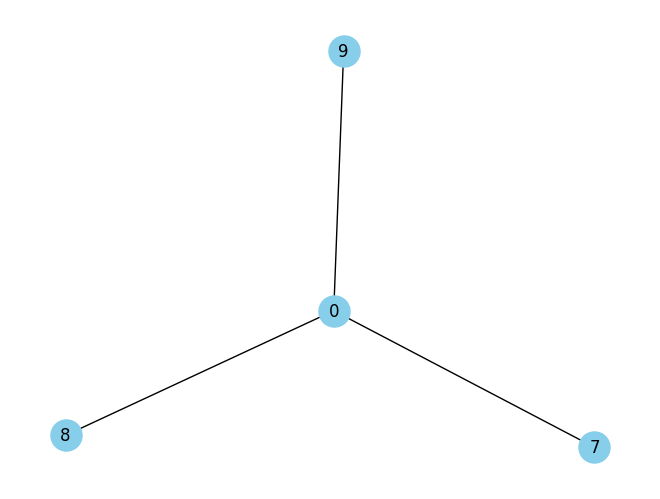

step 1066: start a new part dag {}
step 1071: Section 214 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


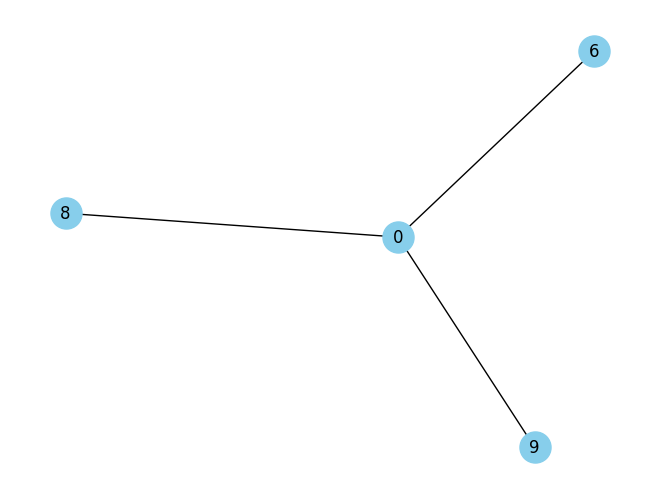

step 1071: start a new part dag {}
step 1076: Section 215 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


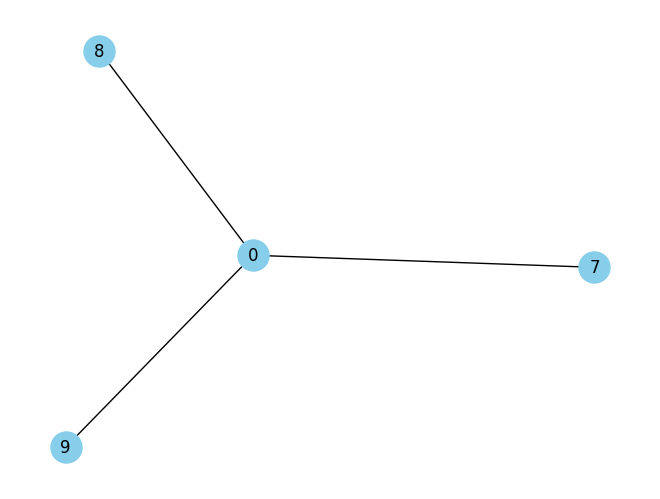

step 1076: start a new part dag {}
step 1081: Section 216 constructed!
[(4, 0), (0, 9), (8, 0), (0, 9)]


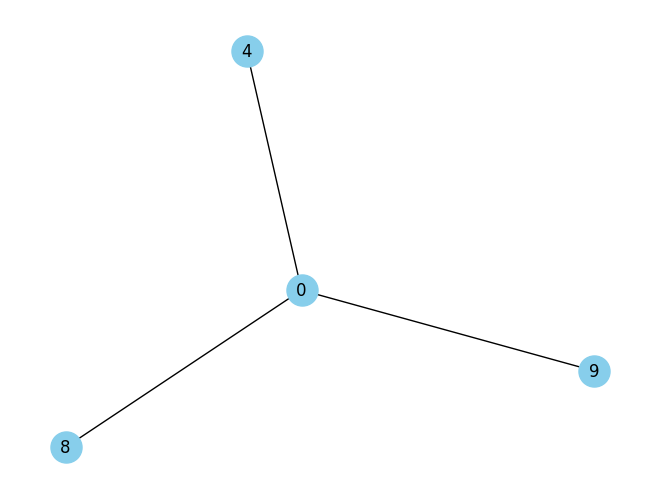

step 1081: start a new part dag {}
step 1086: Section 217 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


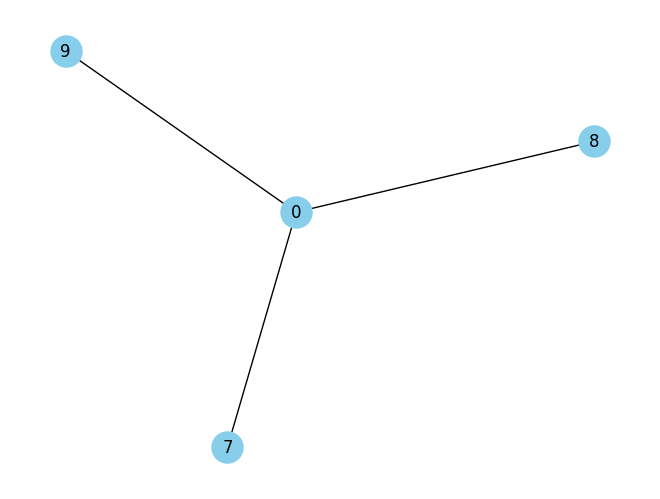

step 1086: start a new part dag {}
step 1091: Section 218 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


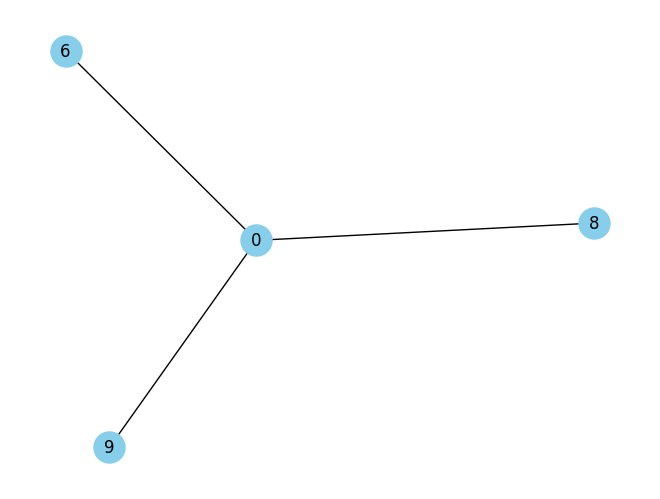

step 1091: start a new part dag {}
step 1096: Section 219 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


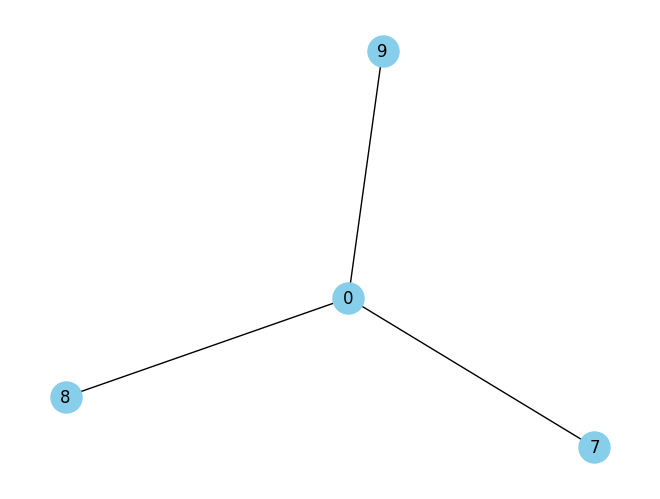

step 1096: start a new part dag {}
step 1101: Section 220 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


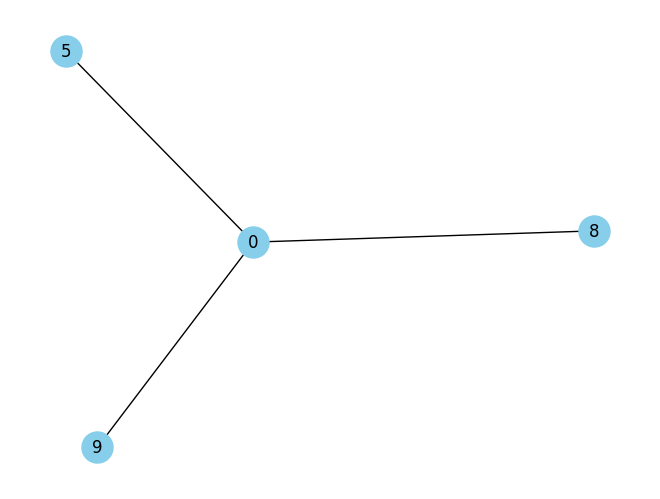

step 1101: start a new part dag {}
step 1106: Section 221 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


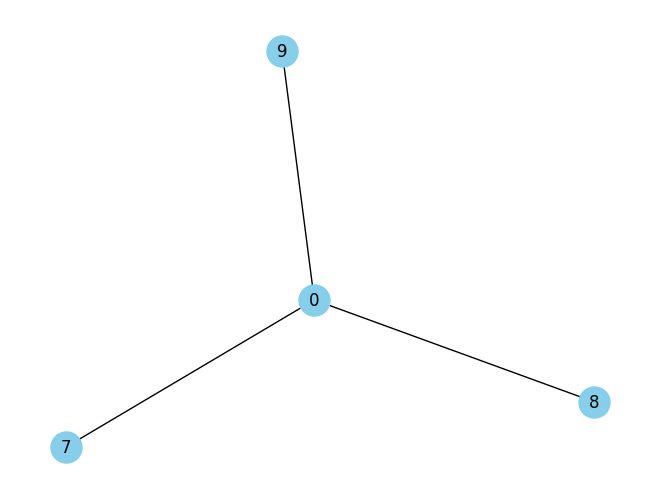

step 1106: start a new part dag {}
step 1111: Section 222 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


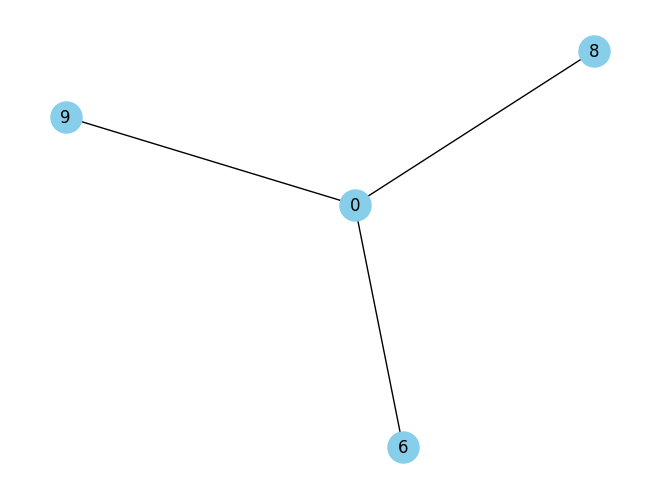

step 1111: start a new part dag {}
step 1116: Section 223 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


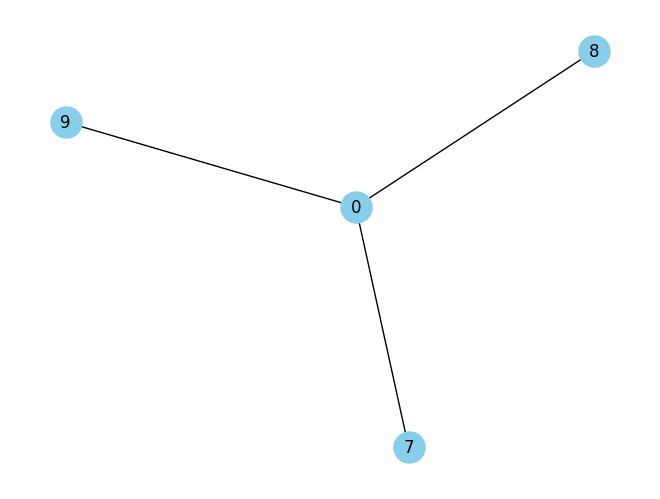

step 1116: start a new part dag {}
step 1121: Section 224 constructed!
[(2, 0), (0, 9), (8, 0), (0, 9)]


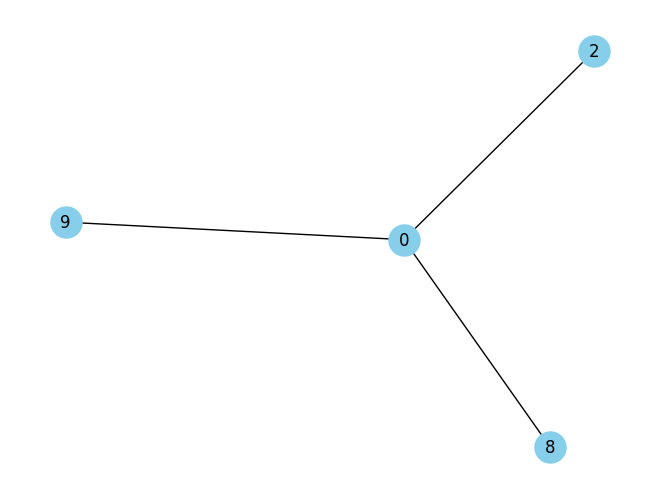

step 1121: start a new part dag {}
step 1126: Section 225 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


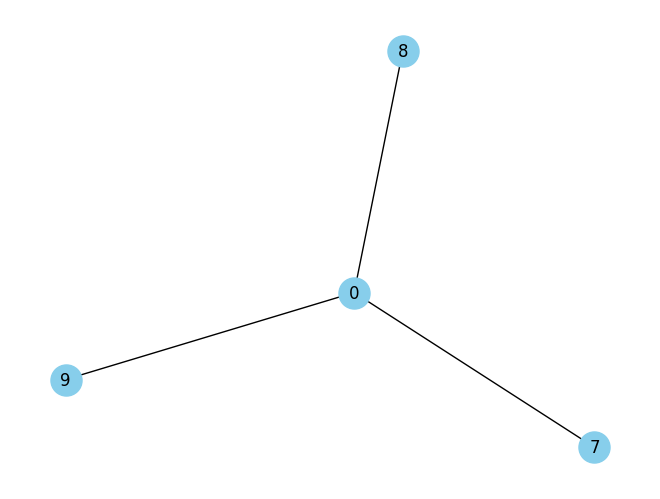

step 1126: start a new part dag {}
step 1131: Section 226 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


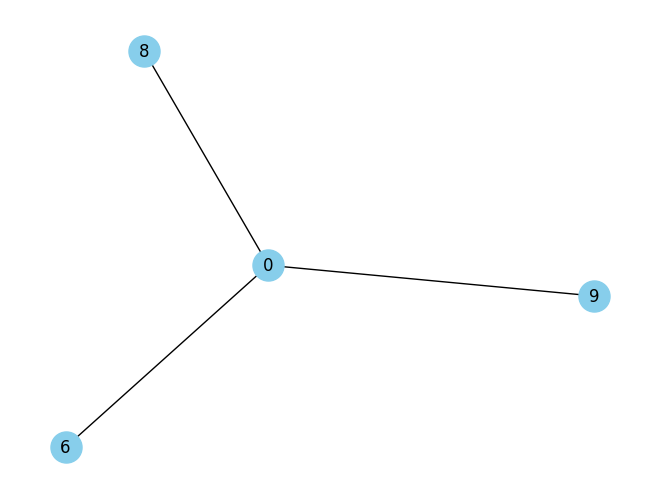

step 1131: start a new part dag {}
step 1136: Section 227 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


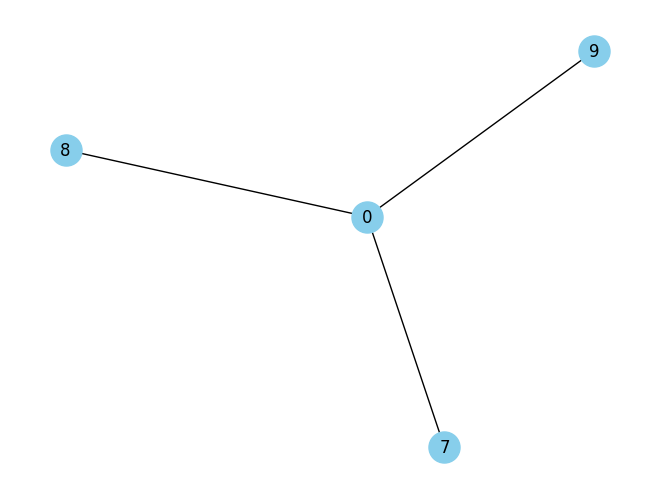

step 1136: start a new part dag {}
step 1141: Section 228 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


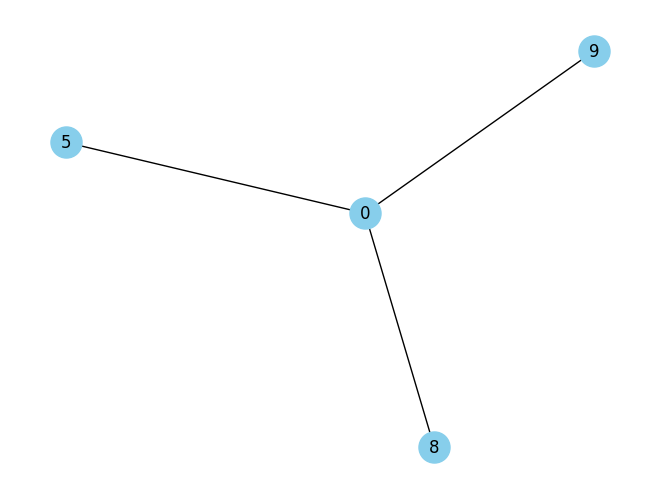

step 1141: start a new part dag {}
step 1146: Section 229 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


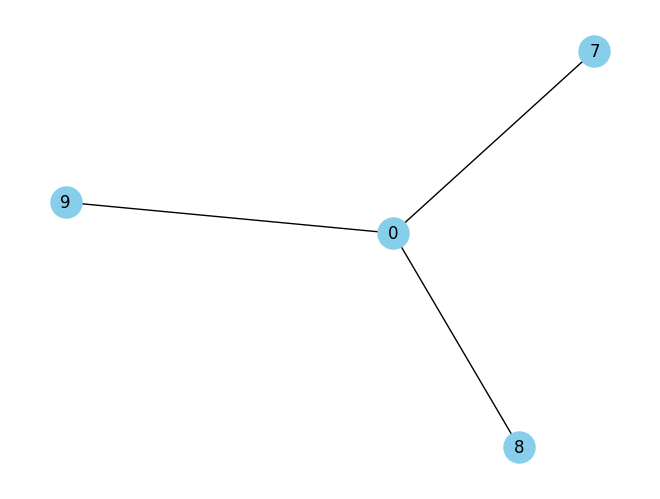

step 1146: start a new part dag {}
step 1151: Section 230 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


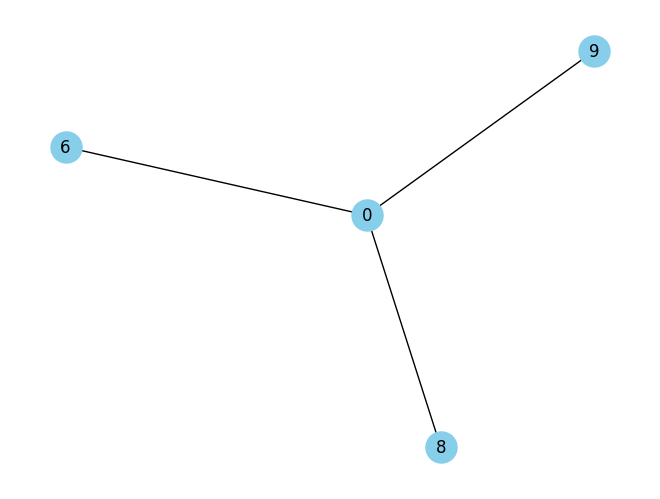

step 1151: start a new part dag {}
step 1156: Section 231 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


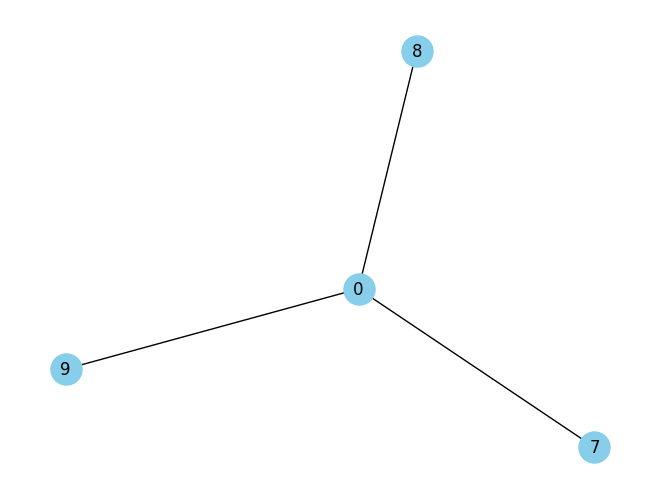

step 1156: start a new part dag {}
step 1161: Section 232 constructed!
[(4, 0), (0, 9), (8, 0), (0, 9)]


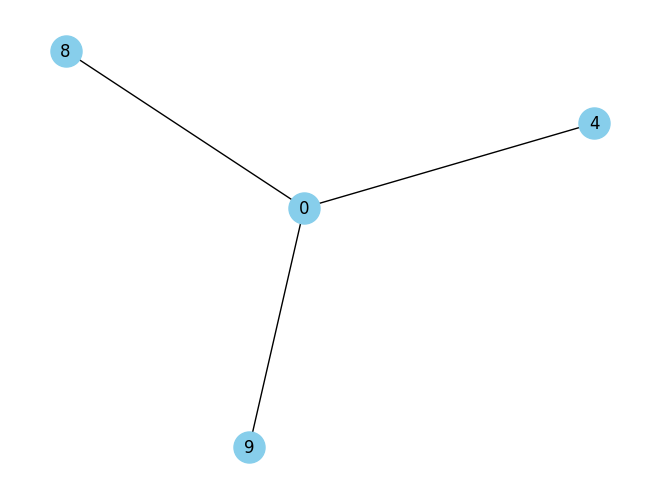

step 1161: start a new part dag {}
step 1166: Section 233 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


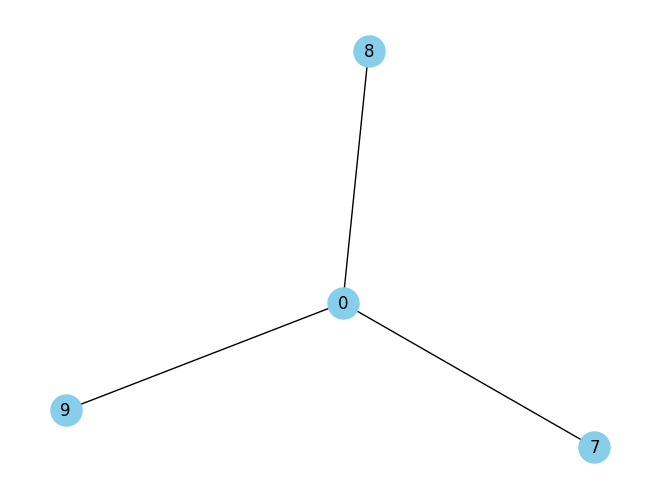

step 1166: start a new part dag {}
step 1171: Section 234 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


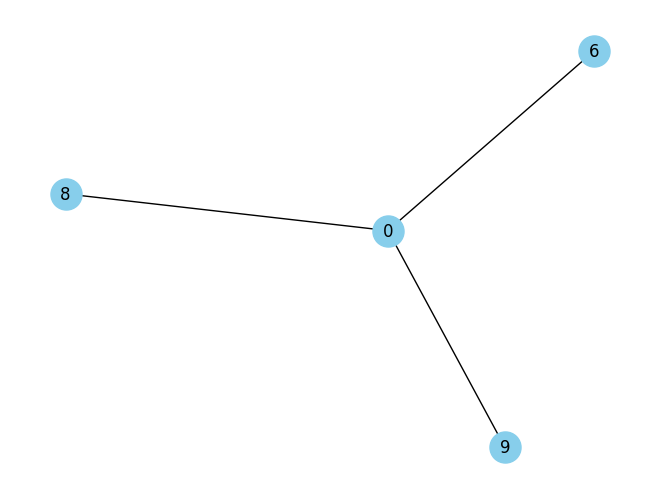

step 1171: start a new part dag {}
step 1176: Section 235 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


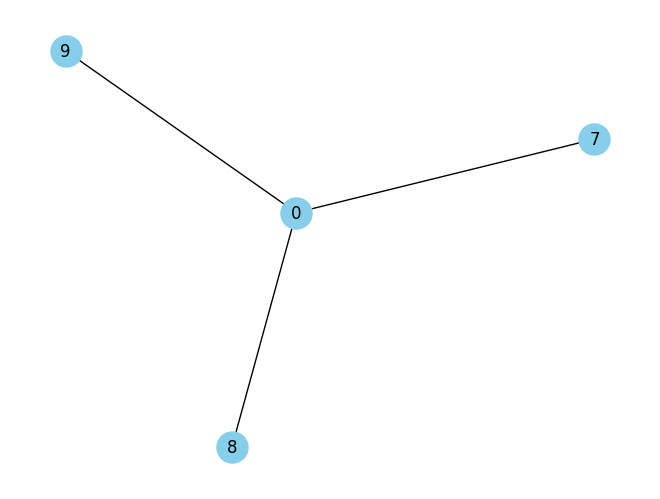

step 1176: start a new part dag {}
step 1181: Section 236 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


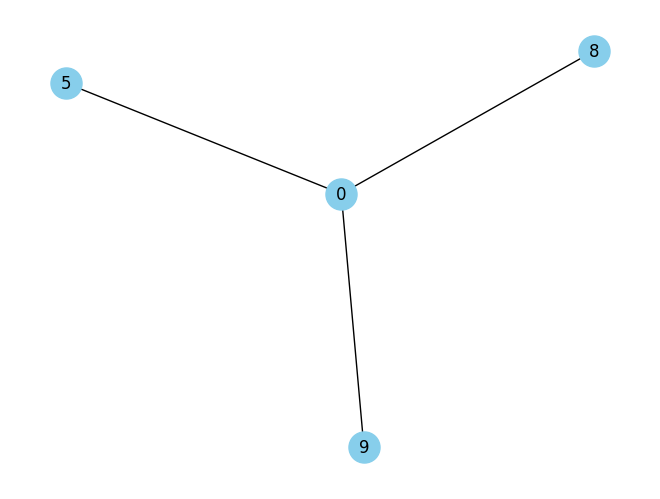

step 1181: start a new part dag {}
step 1186: Section 237 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


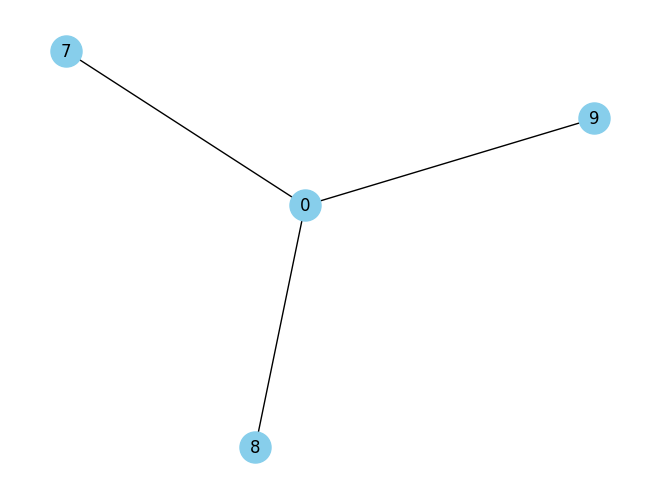

step 1186: start a new part dag {}
step 1191: Section 238 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


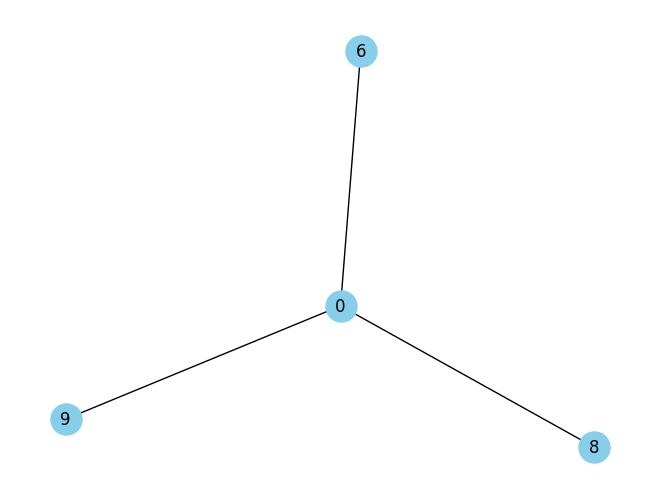

step 1191: start a new part dag {}
step 1196: Section 239 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


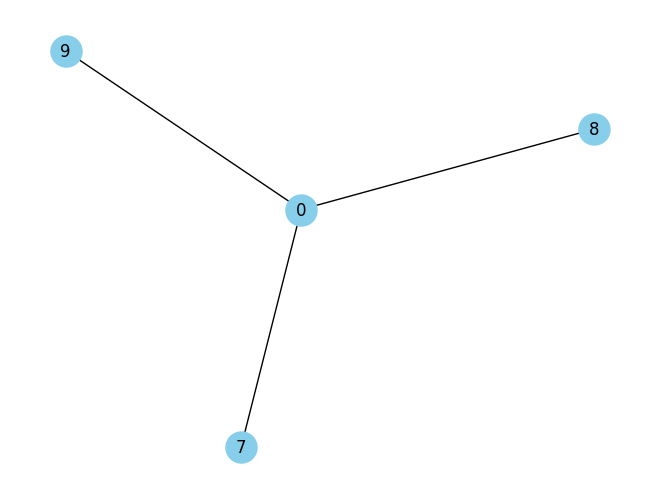

step 1196: start a new part dag {}
step 1201: Section 240 constructed!
[(3, 0), (0, 9), (8, 0), (0, 9)]


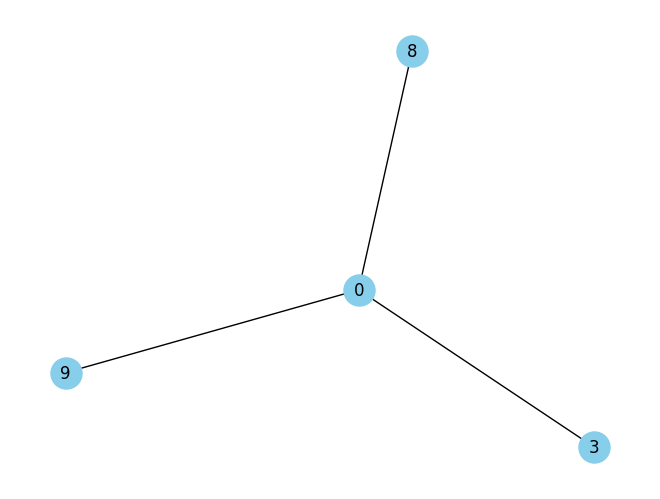

step 1201: start a new part dag {}
step 1206: Section 241 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


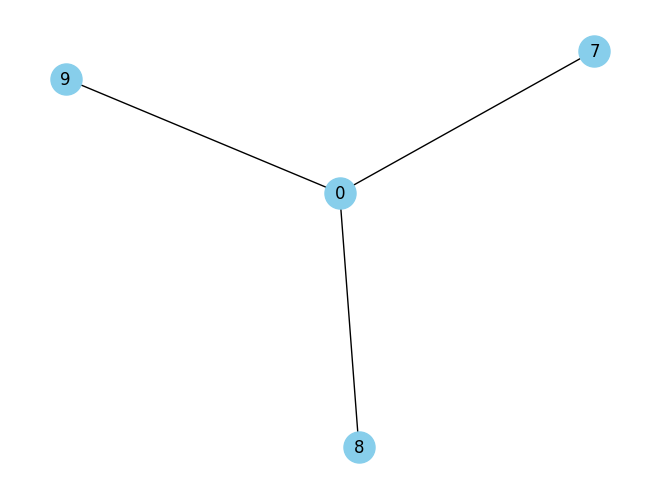

step 1206: start a new part dag {}
step 1211: Section 242 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


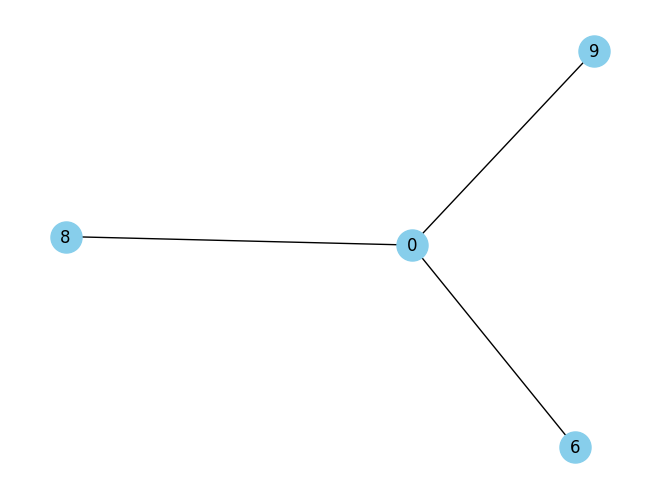

step 1211: start a new part dag {}
step 1216: Section 243 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


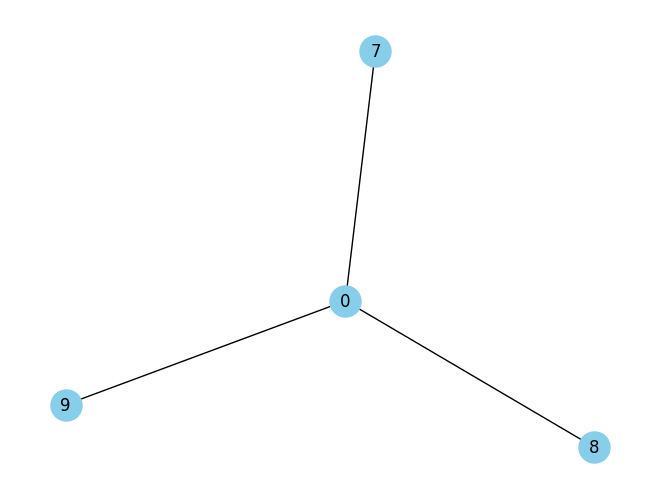

step 1216: start a new part dag {}
step 1221: Section 244 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


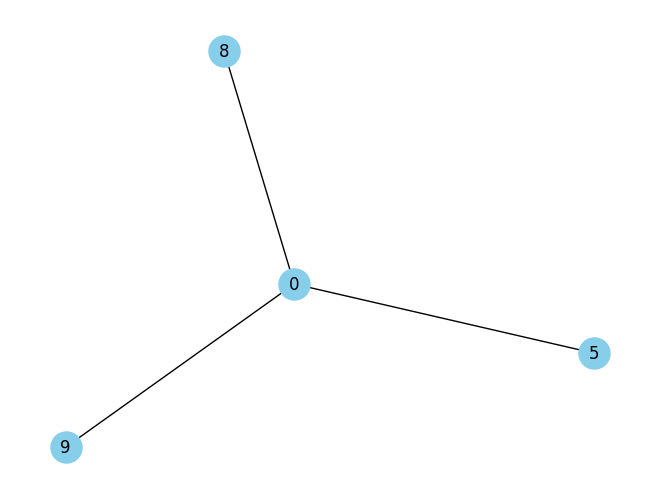

step 1221: start a new part dag {}
step 1226: Section 245 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


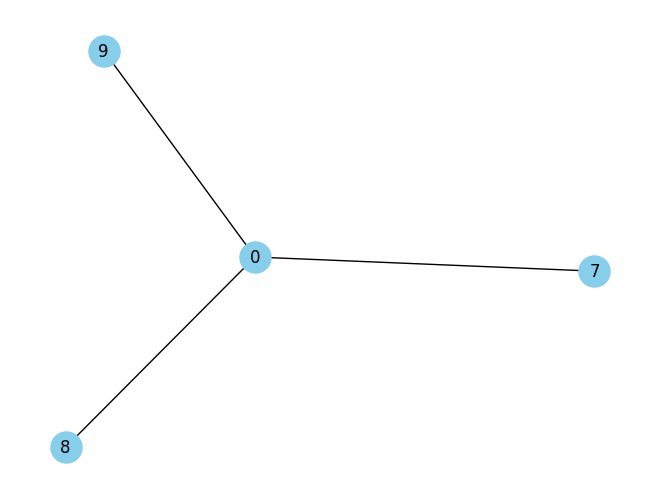

step 1226: start a new part dag {}
step 1231: Section 246 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


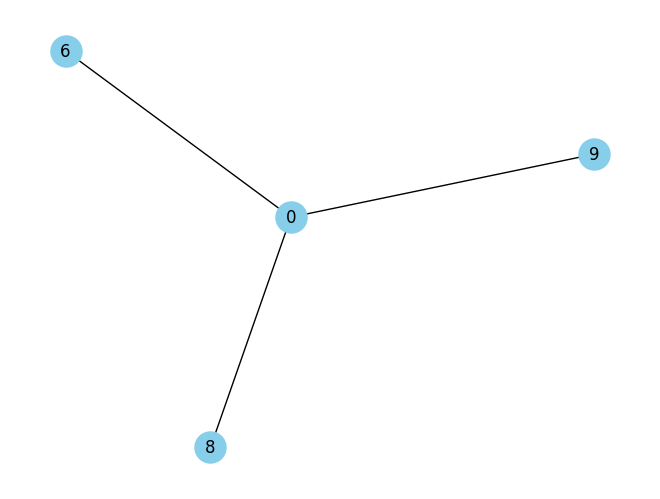

step 1231: start a new part dag {}
step 1236: Section 247 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


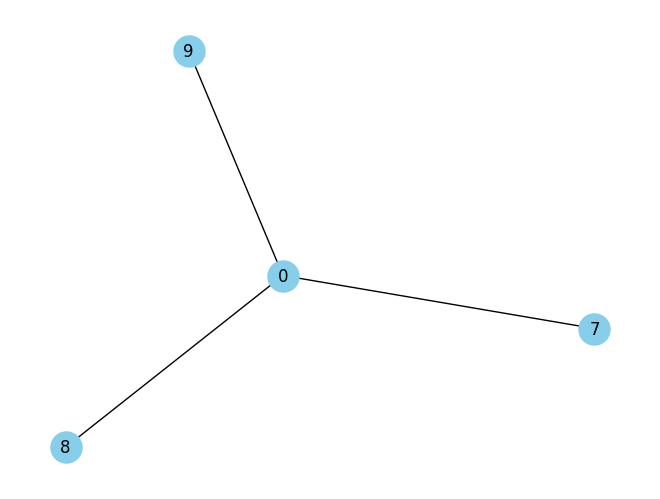

step 1236: start a new part dag {}
step 1241: Section 248 constructed!
[(4, 0), (0, 9), (8, 0), (0, 9)]


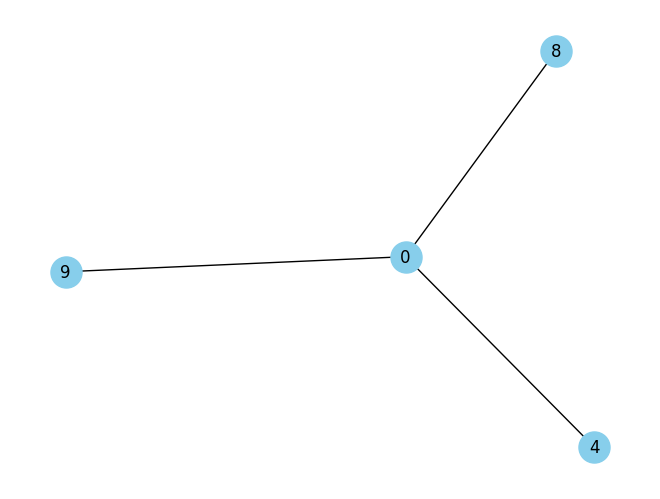

step 1241: start a new part dag {}
step 1246: Section 249 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


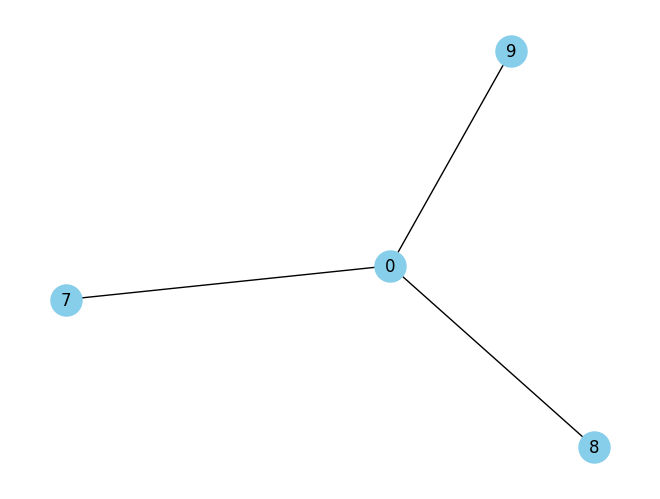

step 1246: start a new part dag {}
step 1251: Section 250 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


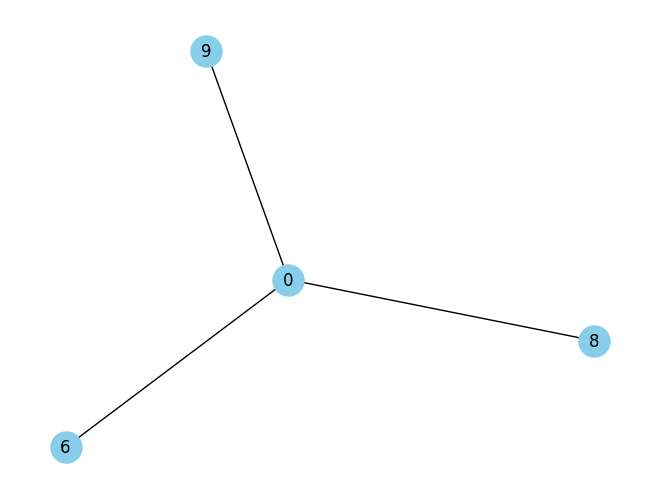

step 1251: start a new part dag {}
step 1256: Section 251 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


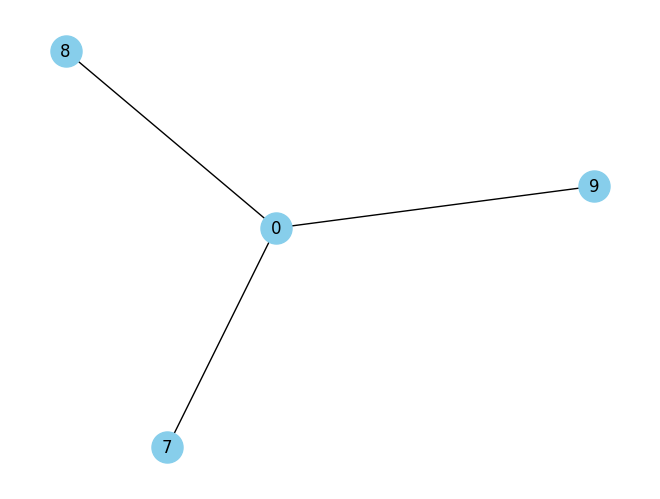

step 1256: start a new part dag {}
step 1261: Section 252 constructed!
[(5, 0), (0, 9), (8, 0), (0, 9)]


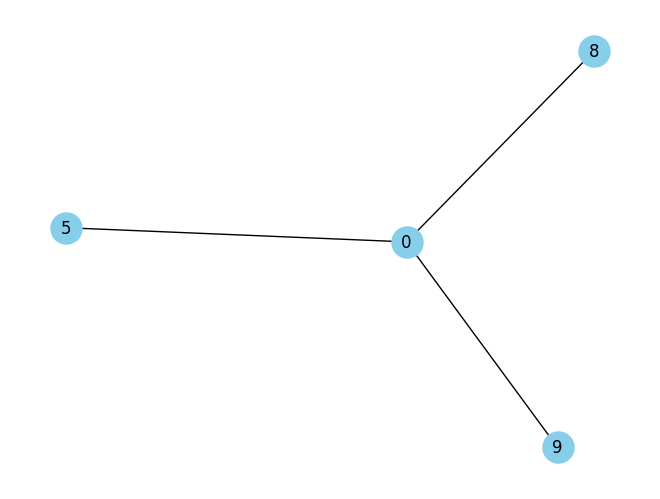

step 1261: start a new part dag {}
step 1266: Section 253 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


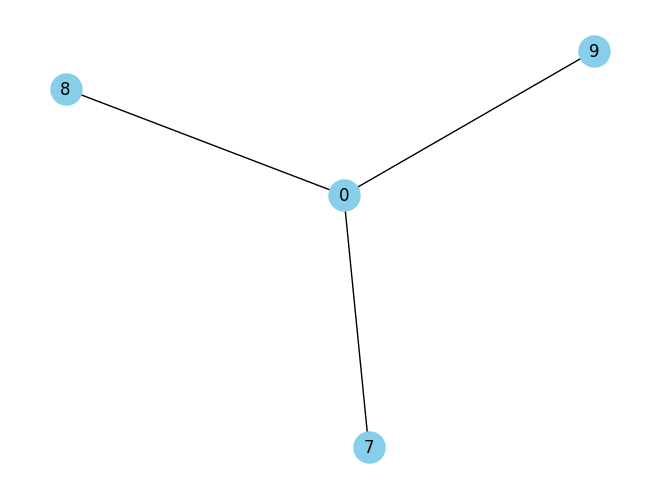

step 1266: start a new part dag {}
step 1271: Section 254 constructed!
[(6, 0), (0, 9), (8, 0), (0, 9)]


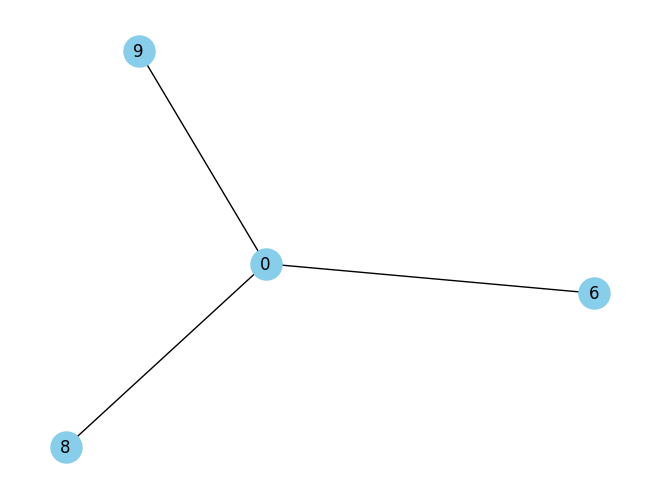

step 1271: start a new part dag {}
step 1275: Section 255 constructed!
[(7, 0), (0, 9), (8, 0), (0, 9)]


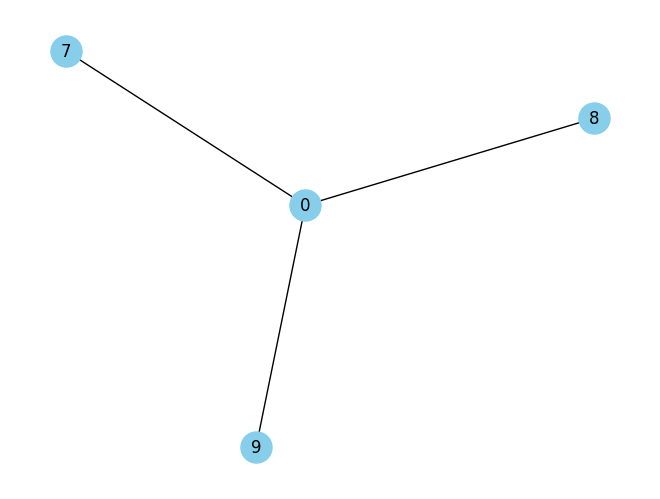

1021 cx gates have been processed.
The partition is complete and we have 255 sections!
The dagCircuit has {'cx': 1021} cx gates
step 18: Section 1 constructed!
[(8, 9), (8, 7), (7, 9), (8, 7), (7, 9), (7, 6), (6, 9), (8, 6), (6, 9), (7, 6), (6, 9), (8, 6), (6, 9), (6, 5), (5, 9), (8, 5), (5, 9)]


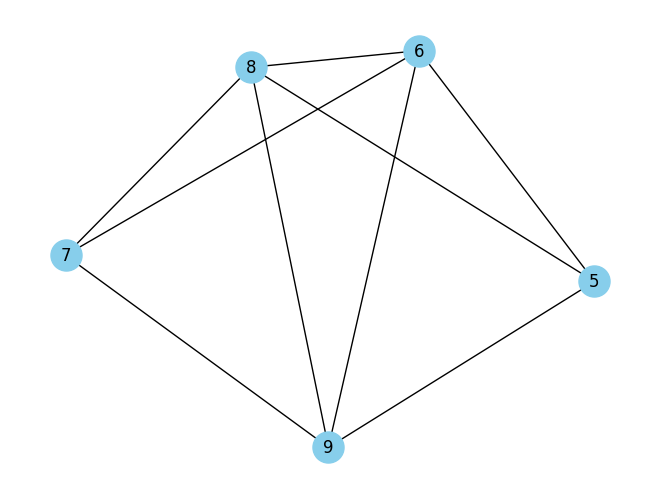

step 18: start a new part dag {}
step 71: Section 2 constructed!
[(7, 5), (5, 9), (8, 5), (5, 9), (6, 5), (5, 9), (8, 5), (5, 9), (7, 5), (5, 9), (8, 5), (5, 9), (5, 4), (4, 9), (8, 4), (4, 9), (7, 4), (4, 9), (8, 4), (4, 9), (6, 4), (4, 9), (8, 4), (4, 9), (7, 4), (4, 9), (8, 4), (4, 9), (5, 4), (4, 9), (8, 4), (4, 9), (7, 4), (4, 9), (8, 4), (4, 9), (6, 4), (4, 9), (8, 4), (4, 9), (7, 4), (4, 9), (8, 4), (4, 9), (4, 3), (3, 9), (8, 3), (3, 9), (7, 3), (3, 9), (8, 3), (3, 9)]


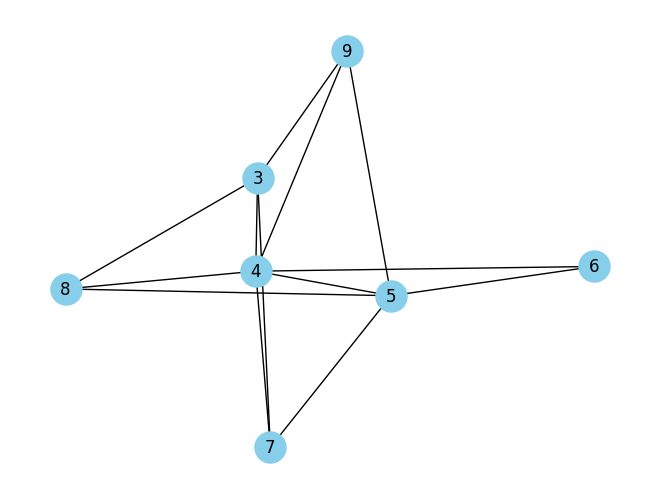

step 71: start a new part dag {}
step 144: Section 3 constructed!
[(6, 3), (3, 9), (8, 3), (3, 9), (7, 3), (3, 9), (8, 3), (3, 9), (5, 3), (3, 9), (8, 3), (3, 9), (7, 3), (3, 9), (8, 3), (3, 9), (6, 3), (3, 9), (8, 3), (3, 9), (7, 3), (3, 9), (8, 3), (3, 9), (4, 3), (3, 9), (8, 3), (3, 9), (7, 3), (3, 9), (8, 3), (3, 9), (6, 3), (3, 9), (8, 3), (3, 9), (7, 3), (3, 9), (8, 3), (3, 9), (5, 3), (3, 9), (8, 3), (3, 9), (7, 3), (3, 9), (8, 3), (3, 9), (6, 3), (3, 9), (8, 3), (3, 9), (7, 3), (3, 9), (8, 3), (3, 9), (3, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (6, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9)]


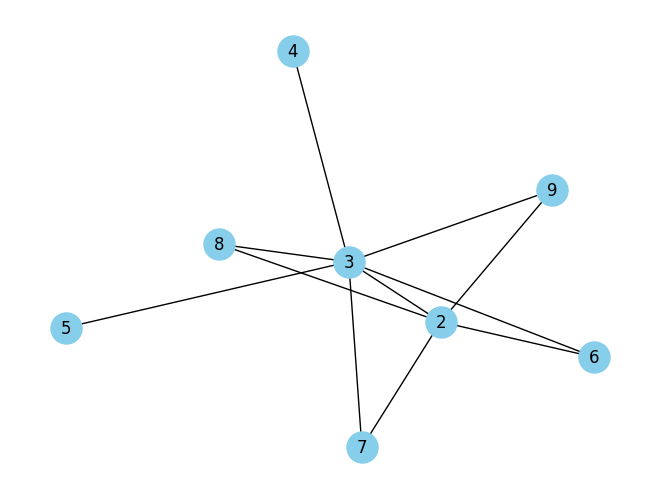

step 144: start a new part dag {}
step 257: Section 4 constructed!
[(5, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (6, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (4, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (6, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (5, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (6, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (3, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (6, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (5, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (6, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (4, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (6, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (5, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9), (6, 2), (2, 9), (8, 2), (2, 9), (7, 2), (2, 9), (8, 2), (2, 9)]


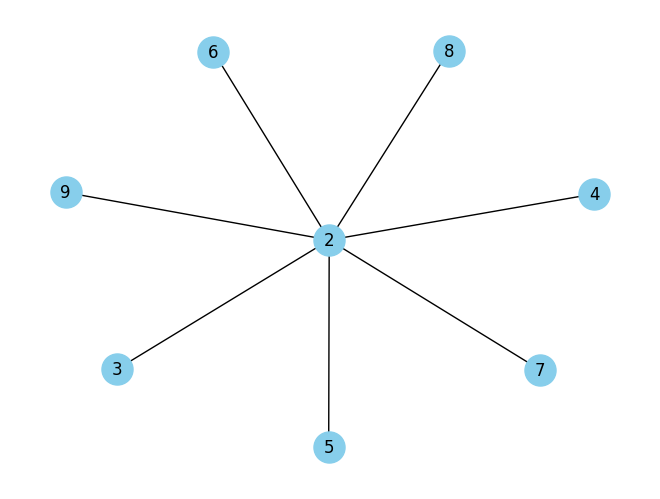

step 257: start a new part dag {}
step 322: Section 5 constructed!
[(2, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (5, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (4, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (5, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9)]


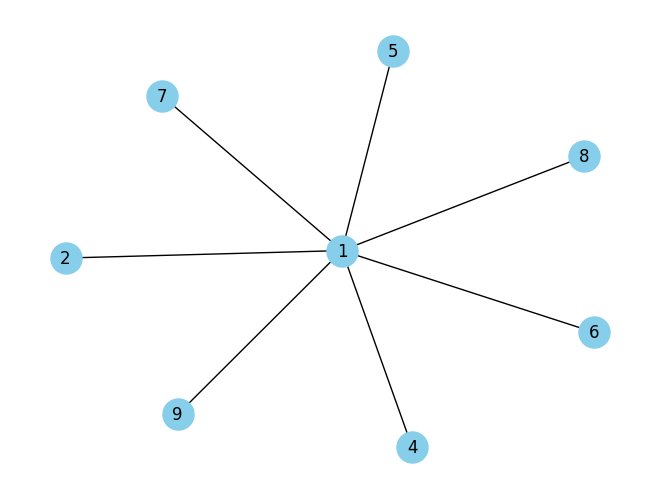

step 322: start a new part dag {}
step 387: Section 6 constructed!
[(3, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (5, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (4, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (5, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9)]


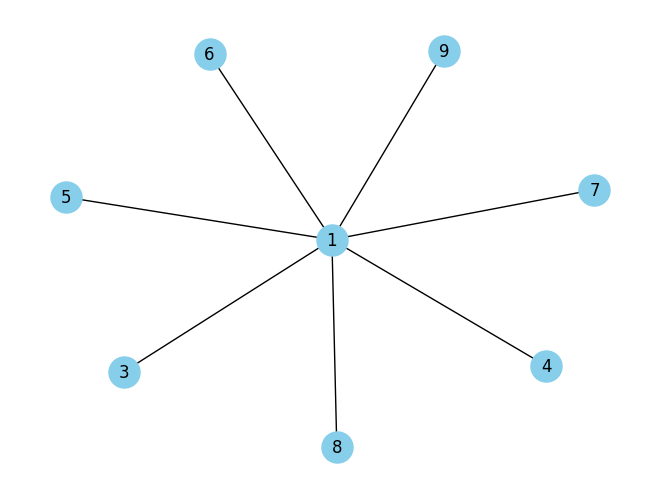

step 387: start a new part dag {}
step 452: Section 7 constructed!
[(2, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (5, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (4, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (5, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9)]


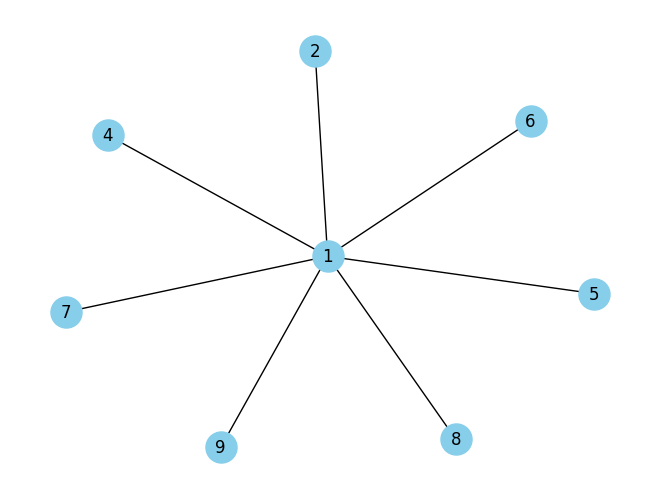

step 452: start a new part dag {}
step 517: Section 8 constructed!
[(3, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (5, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (4, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (5, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9), (6, 1), (1, 9), (8, 1), (1, 9), (7, 1), (1, 9), (8, 1), (1, 9)]


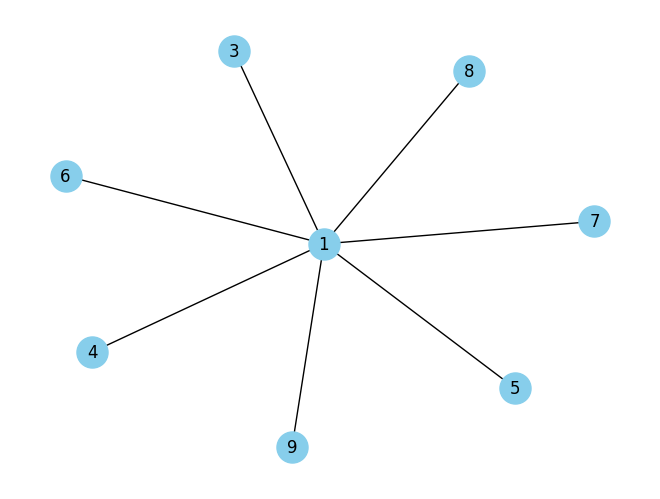

step 517: start a new part dag {}
step 582: Section 9 constructed!
[(1, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (4, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9)]


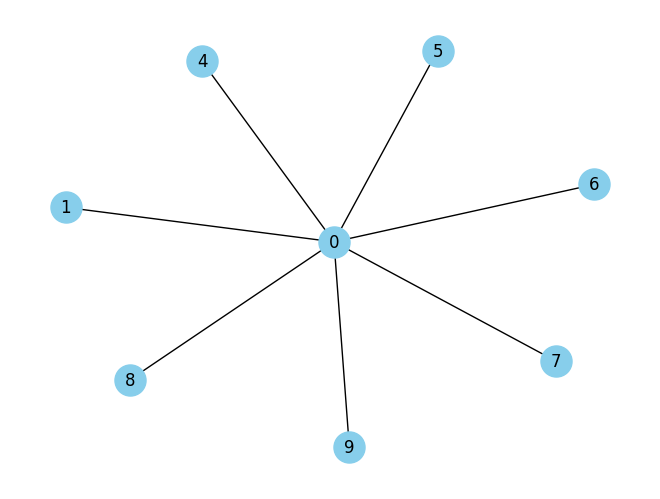

step 582: start a new part dag {}
step 647: Section 10 constructed!
[(3, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (4, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9)]


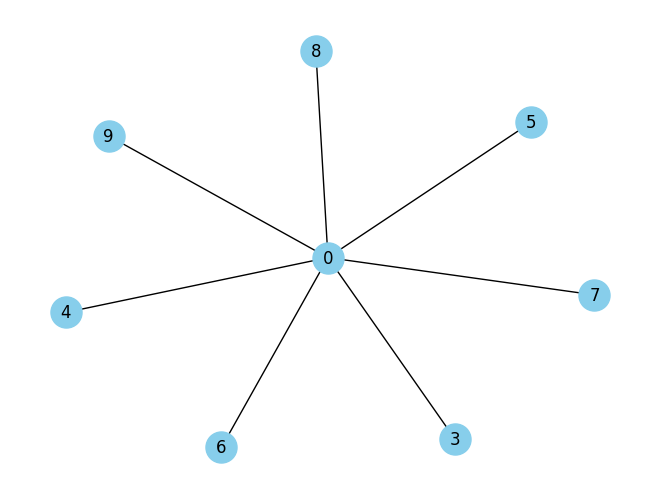

step 647: start a new part dag {}
step 712: Section 11 constructed!
[(2, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (4, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9)]


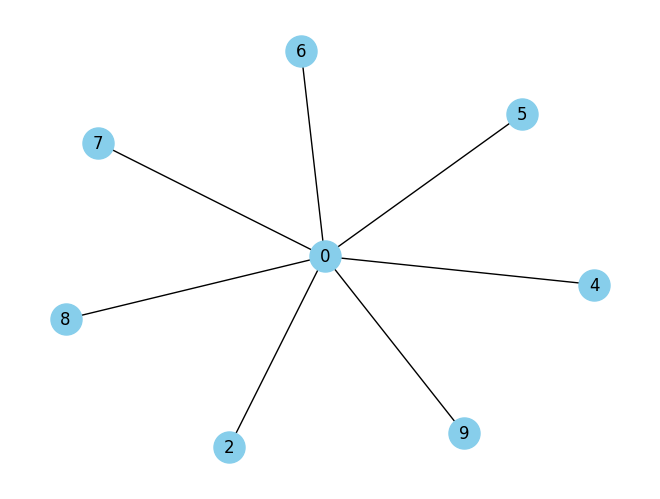

step 712: start a new part dag {}
step 777: Section 12 constructed!
[(3, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (4, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9)]


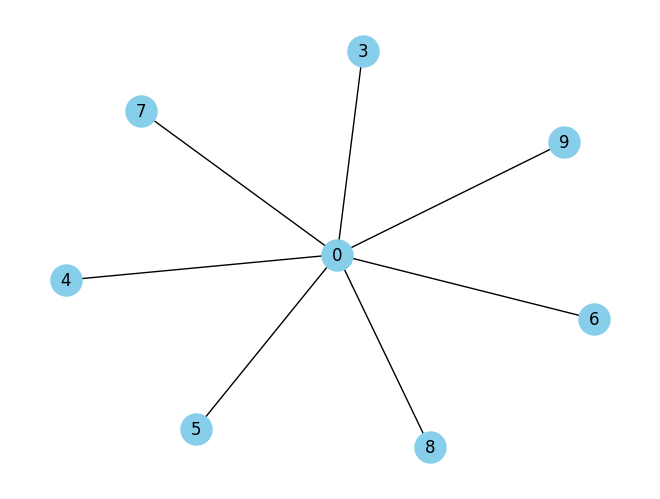

step 777: start a new part dag {}
step 842: Section 13 constructed!
[(1, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (4, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9)]


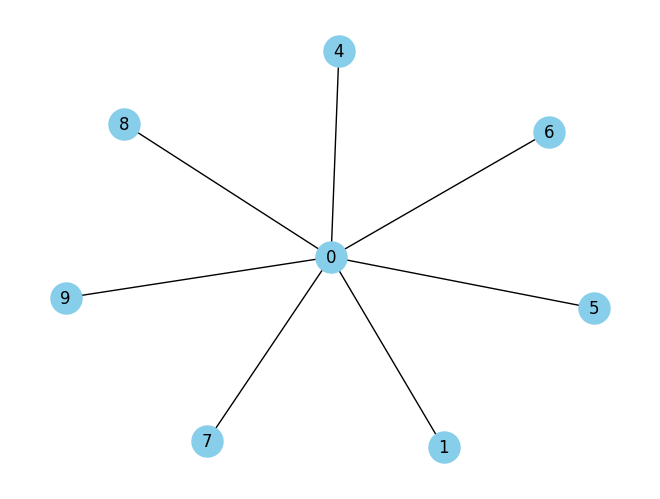

step 842: start a new part dag {}
step 907: Section 14 constructed!
[(3, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (4, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9)]


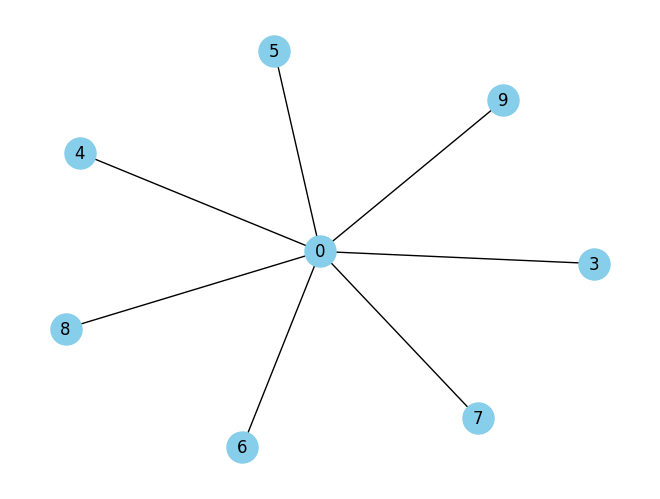

step 907: start a new part dag {}
step 972: Section 15 constructed!
[(2, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (4, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9)]


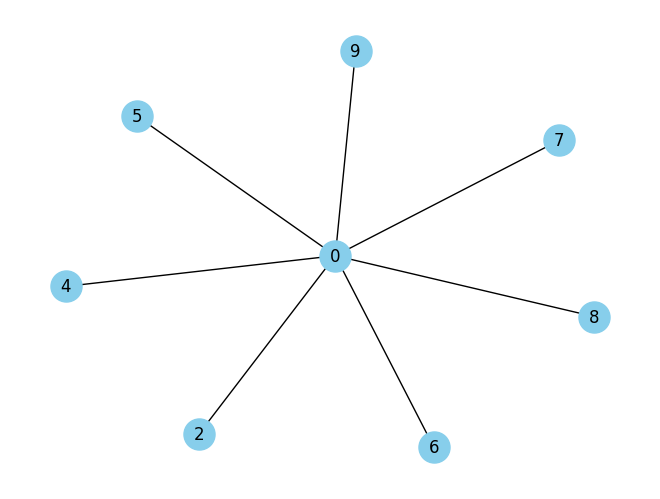

step 972: start a new part dag {}
step 1036: Section 16 constructed!
[(3, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (4, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (5, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9), (6, 0), (0, 9), (8, 0), (0, 9), (7, 0), (0, 9), (8, 0), (0, 9)]


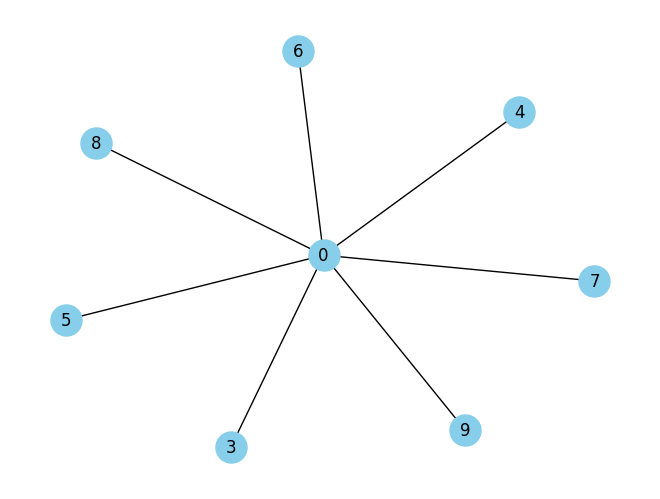

1021 cx gates have been processed.
The partition is complete and we have 16 sections!


In [147]:
from ag import qgrid, q20
import time
import os

"""Divide-and-Conquer works fine on Tokyo and phase_estimation, phase_oracle, AND, OR, """
path = '../bench/qiskit_circuit_benchmark/' 
#filename = 'excitation_preserving_6.qasm'
#filename = 'grover_operator_14.qasm'
#filename = 'quantum_volume_16.qasm'
#filename = 'phase_oracle_14.qasm'
filename = 'or_10.qasm'

#AG = q20()
AG = qgrid(2,5)

#path = '../bench/20Q_gate_Tokyo/' 
#filename = '20QBT_gate_Tokyo_large_opt1_0_1.5_no.8.qasm'

rxAG = rx.networkx_converter(AG)
newAG = architecturesquare(AG)

with open(path+filename, 'r') as file:
    qasm_code = file.read()

# Create a QuantumCircuit from the QASM code
qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops())
#circuit_drawer(newcirc)
#print(newcirc)

g = graph_of_circuit(newcirc)
xx = is_rx_embeddable(g, AG)
print(f'The interaction graph is embeddable in AG? {xx[0]}')

X = partition(dag, AG, method='greedy')
XX = partition(dag, newAG, method='greedy')

In [146]:
def has_descendnent(node: DAGOpNode, dag: DAGCircuit):
    return [s for s in _successors(node, dag) if isinstance(s,DAGOpNode)]

def realign(dag1: DAGCircuit, dag2: DAGCircuit):
    """Move dag1 nodes whose cx (undirected) appear in dag2 to dag2 in reverse topological order"""
    qc2 =  dag_to_circuit(dag2)
    graph2 = graph_of_circuit(qc2)  
    nodes_in_reverse_topological_order = list(reversed(list(dag1.topological_op_nodes())))
    for node in nodes_in_reverse_topological_order:
        if not isinstance(node, DAGOpNode) or has_descendnent(node, dag1): continue
        if (node.qargs[0]._index, node.qargs[1]._index) in graph2.edges():
            dag1.remove_op_node(node)
            dag2.apply_operation_front(node.op, node.qargs, node.cargs)
    return dag1, dag2

step 0 of 2. ({'cx': 7}, {'cx': 7})
step 1 of 2. ({'cx': 6}, {'cx': 6})
13
13
Modified Section 0 has CX gates
[(2, 4), (10, 0), (12, 7), (13, 17), (13, 10), (10, 0), (18, 14)]


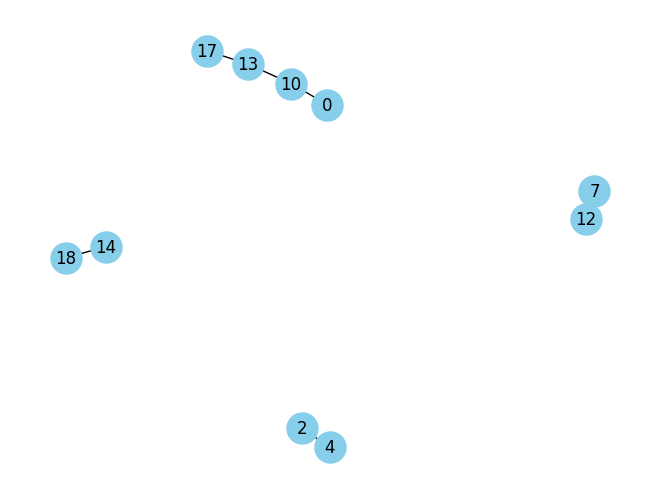

Modified Section 1 has CX gates
[(9, 7), (15, 17), (16, 15), (6, 17), (18, 8), (8, 11)]


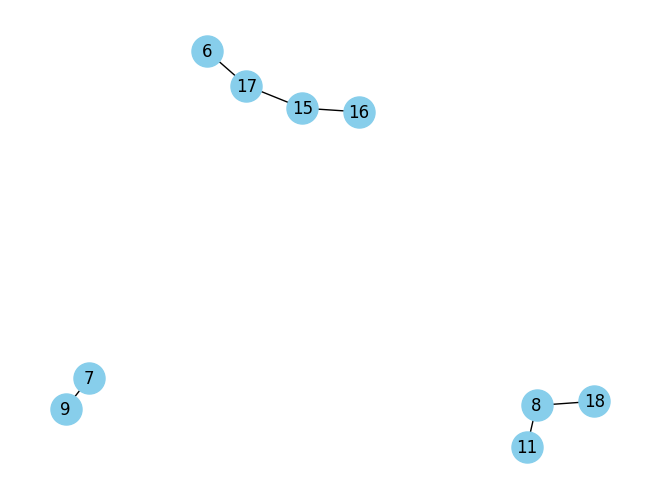

In [144]:
W = copy.deepcopy(X)
for i in range(len(W)-1):
    W[i], W[i+1] = realign(W[i], W[i+1])

for i in range(len(X)):
    print(f'step {i} of {len(X)}. {X[i].count_ops(),W[i].count_ops()}')
    
print(sum([X[i].count_ops()['cx'] for i in range(len(X))]))
print(sum([W[i].count_ops()['cx'] for i in range(len(W))]))

for i in range(len(W)):
    print(f'Modified Section {i} has CX gates')
    print([(node.qargs[0]._index, node.qargs[1]._index) for node\
           in W[i].topological_op_nodes() if isinstance(node, DAGOpNode)])
    draw_nx_graph(W[i])